# Community ECS assessment

Clean driver for [`community_ecs.stan`](community_ecs.stan). The notebook keeps assessed numerical inputs separate from model switches, runs named scenarios, and stores both live results and durable run files.

Use the **`stan` mamba environment** for this notebook. Run the cells from top to bottom.

In [1]:
import json
import re
import sys
from copy import deepcopy
from datetime import datetime
from pathlib import Path

import cmdstanpy
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import gaussian_kde, norm, skewnorm

# Work whether Jupyter starts in bayecs/ or in its parent directory.
root = Path.cwd().resolve()
if not (root / "community_ecs.stan").exists():
    candidate = root / "bayecs"
    if (candidate / "community_ecs.stan").exists():
        root = candidate

stan_file = root / "community_ecs.stan"
assert stan_file.exists(), f"Stan file not found: {stan_file}"

# The stan environment bundles CmdStan at <environment>/bin/cmdstan.
# Use CmdStanPy's configured location when available, with that local
# environment path as a fallback.
env_bin = Path(sys.executable).resolve().parent
try:
    cmdstan_path = Path(cmdstanpy.cmdstan_path())
except ValueError:
    env_cmdstan = env_bin / "cmdstan"
    if not env_cmdstan.exists():
        raise RuntimeError(
            "CmdStan was not found. Run this notebook with the stan mamba environment."
        )
    cmdstanpy.set_cmdstan_path(str(env_cmdstan))
    cmdstan_path = env_cmdstan

# Prefer the stan environment's matching GNU compiler over any compiler
# inherited from the host's shell modules. This avoids TBB ABI conflicts.
env_cxx = env_bin / "x86_64-conda-linux-gnu-g++"
cpp_options = {"CXX": str(env_cxx)} if env_cxx.exists() else {}

print("Stan file:", stan_file)
print("CmdStanPy:", cmdstanpy.__version__)
print("CmdStan:", cmdstan_path)
print("C++ compiler:", cpp_options.get("CXX", "CmdStan default"))

Stan file: /glade/derecho/scratch/vcooper/projects/bayecs/community_ecs.stan
CmdStanPy: 1.2.1
CmdStan: /glade/derecho/scratch/vcooper/conda/envs/stan/bin/cmdstan
C++ compiler: /glade/derecho/scratch/vcooper/conda/envs/stan/bin/x86_64-conda-linux-gnu-g++


In [2]:
import matplotlib as mpl
import seaborn as sns

## Figure controls: change these once for all plots below.
display_dpi = 160
save_dpi = 700
despine_panels = False

## Match the serif plotting style used in grl_eei_update.ipynb.
sns.set_context("paper")
mpl.rcParams.update({
    "font.family": "serif",
    "font.serif": [
        "TeX Gyre Termes",
        "Times New Roman",
        "Times",
        "STIXGeneral",
    ],
    "mathtext.fontset": "stix",
    "mathtext.rm": "serif",
    "mathtext.it": "serif:italic",
    "mathtext.bf": "serif:bold",
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "figure.dpi": display_dpi,
    "savefig.dpi": save_dpi,
})

## Final-figure PDF files use the same stems as the saved PNG previews.
ecs_figure_dir = Path("/glade/u/home/vcooper/work/hist_sst/bayecs/figures/ecs")

def ecs_pdf_path(filename, save_figure):
    if not save_figure:
        return None
    ecs_figure_dir.mkdir(parents=True, exist_ok=True)
    return ecs_figure_dir / filename

def ecs_score_pdf(stem, score_method, save_figure):
    suffix = "" if score_method == "N" else f"_score{score_method}"
    return ecs_pdf_path(f"{stem}{suffix}.pdf", save_figure)

def figure_dpi(save_figure):
    return save_dpi if save_figure else display_dpi

def maybe_despine(fig, enabled=None):
    if enabled is None:
        enabled = despine_panels
    if enabled:
        sns.despine(fig=fig)

def set_feedback_ecs_axes(feedback_ax, ecs_ax):
    feedback_ax.set_xlim(-3, 0)
    feedback_ax.set_xticks(np.arange(-3, 0.01, 0.5))
    ecs_ax.set_xlim(0, 10)
    ecs_ax.set_xticks(np.arange(0, 11, 1))


## Assessed inputs

These are the current central values and 1-sigma uncertainties. Every input remains present even when its line of evidence is disabled, because the unified Stan model has one fixed data interface.

In [3]:
## Process components

## --------------- cloud ---------------
## Component means and standard deviations are the latest values from
## cloud_assess.ipynb. The Stan model receives only the aggregate
## cloud_total_mu and cloud_total_sig calculated below.
marine_lowcloud_mu = 0.30975
marine_lowcloud_sig = 0.211013

highcloud_amt_optdepth_mu = 0.01350
highcloud_amt_optdepth_sig = 0.114829

highcloud_alt_mu = 0.24180
highcloud_alt_sig = 0.125454

landcloud_mu = 0.08
landcloud_sig = 0.08

unassessed_cloud_mu = 0.0
unassessed_cloud_sig = 0.10

## Means and variances add under the assumed component independence.
cloud_total_mu = (
    marine_lowcloud_mu + 
    highcloud_amt_optdepth_mu +
    highcloud_alt_mu + 
    landcloud_mu +
    unassessed_cloud_mu
)
cloud_total_sig = (
    marine_lowcloud_sig**2 + 
    highcloud_amt_optdepth_sig**2 +
    highcloud_alt_sig**2 + 
    landcloud_sig**2 +
    unassessed_cloud_sig**2
)**0.5
print('Total cloud input: ', np.round(cloud_total_mu,3), '±', np.round(cloud_total_sig,3), 'W m-2 K-1')

## --------------- noncloud ---------------
# Kuma weighting on CMIP6, in line with SW20 and AR6
planck_mu  = -3.23
planck_sig = 0.11 ## 0.10 kernel spread, Janowski and Zelinka/Forster, 0.04 intermodel spread

# from SW20 and Colman & Soden 2021
LRWV_mu = 1.27 ## 1.25 joint ancestry + 0.02 strat
LRWV_sig = 0.18 ## see paper

# from AR6
surfalbedo_mu  = 0.39 
surfalbedo_sig = 0.15

noncloud_total_mu = (
    planck_mu + LRWV_mu + surfalbedo_mu
)
noncloud_total_sig = (
    planck_sig**2 + LRWV_sig**2 + surfalbedo_sig**2
)**0.5

print('Total noncloud: ', np.round(noncloud_total_mu,3), '±', np.round(noncloud_total_sig,3), 'W m-2 K-1')

## --------------- unassessed non-cloud ---------------
unassessed_mu = 0.0
unassessed_sig = 0.16

## --------------- total process ---------------
process_lamb_mu = (
    cloud_total_mu + noncloud_total_mu + unassessed_mu
)
process_lamb_sig = (
    cloud_total_sig**2 + noncloud_total_sig**2 + unassessed_sig**2
)**0.5
print('Total process: ', np.round(process_lamb_mu,4), '±', np.round(process_lamb_sig,4), 'W m-2 K-1')

Total cloud input:  0.645 ± 0.3 W m-2 K-1
Total noncloud:  -1.57 ± 0.259 W m-2 K-1
Total process:  -0.9249 ± 0.4271 W m-2 K-1


In [143]:
## Common inputs, used lated in the dictionary
erf_2x = 3.93
sig_erf_2x = 0.29
co2_pi = 284.7

## Reflected-lognormal prior on the positive damping r = -lambda.
## These match the final prior comparison in grl_eei_update.ipynb.
# lognormal_r_median = 1.
# lognormal_r_log_sigma = 0.8
lognormal_r_median = 2.02815 #np.exp(3.0)       
lognormal_r_log_sigma = 1.2442 #np.sqrt(3.)

## Instrumental pattern-effect skew-normal parameters.
## Note default inputs give -0.62 median pattern effect.
## Setting shape=0 yields a normal(mean=loc,sd=scale).
instrumental_dlambda_shape = -3.7573
instrumental_dlambda_loc = 0.9726
instrumental_dlambda_scale = 0.5195

## paleo pattern effect correlation
rho_LGM_plio = 0.5 #0.54

# ----- OPTIONAL -----
# Latent-Gaussian correlations used only when the copula is enabled.
# The instrumental values induce approximately -0.10 Pearson correlation
# with the present skew-normal instrumental marginal.
rho_instrumental_LGM = 0. #-0.10
rho_instrumental_plio = 0. #-0.10

# Optional Process-lambda / ERF2x correlation. Negative means that a
# larger (more-positive) F_2xCO2 accompanies a more-negative lambda.
rho_lambda_F2x = 0. #-0.50

# 2006--2024 ERF-trend decomposition. Anthropogenic aerosol is ARI+ACI.
# The aerosol trend has paired-ensemble and additional structural spreads.
# Both covariance choices retain the structural contribution to variance.
# CO2 uncertainty is inherited from F2x and is not added independently.
mu_F_CO2_trend = 0.329
mu_F_anthro_aerosol_trend = 0.200
sig_F_anthro_aerosol_instrumental = 0.342
sig_F_anthro_aerosol_trend_ensemble = 0.143
sig_F_anthro_aerosol_trend_structural = 0.10
rho_F_anthro_aerosol_struct_instrumental = -0.5043638097 # pearson's r
sig_F_anthro_aerosol_trend = np.sqrt(
    sig_F_anthro_aerosol_trend_ensemble**2
    + sig_F_anthro_aerosol_trend_structural**2
)
mu_F_other_trend = 0.150
sig_F_other_trend = 0.016

# Paired IGCC covariance between the instrumental forcing change and the
# 2006--2024 trend. Choose whether the additional structural aerosol error
# contributes to covariance. Change this one setting to compare assumptions.
cov_F_anthro_aerosol_instrumental_trend_ensemble = -0.0247083552
aerosol_structural_covariance_mode = "correlated"  # or "independent"
cov_F_anthro_aerosol_instrumental_trend_options = {
    "independent": cov_F_anthro_aerosol_instrumental_trend_ensemble,
    "correlated": (
        cov_F_anthro_aerosol_instrumental_trend_ensemble
        + rho_F_anthro_aerosol_struct_instrumental
        * sig_F_anthro_aerosol_instrumental
        * sig_F_anthro_aerosol_trend_structural
    ),
}
cov_F_anthro_aerosol_instrumental_trend = (
    cov_F_anthro_aerosol_instrumental_trend_options[
        aerosol_structural_covariance_mode
    ]
)
cov_F_other_instrumental_trend = 0.00108444987 # pearson's r = 

base_inputs = {
    # Shared forcing
    "erf_2x": erf_2x,
    "sig_F2xCO2": sig_erf_2x,
    "rho_lambda_F2x": rho_lambda_F2x,

    # Reflected-lognormal lambda-prior parameters
    "lognormal_r_median": lognormal_r_median,
    "lognormal_r_log_sigma": lognormal_r_log_sigma,

    # Process evidence
    "mu_lambda": process_lamb_mu,
    "sig_lambda": process_lamb_sig,

    # Instrumental evidence
    "mu_T_instrumental": 1.089, # mean of Thorne
    "sig_T_instrumental": np.sqrt(0.08**2 + 0.07**2), ## observational + internal variability
    "mu_N_instrumental": 0.81,
    "sig_N_instrumental": 0.20,
    "mu_F_CO2_instrumental": 1.80,
    "mu_F_anthro_aerosol_instrumental": -0.970,
    "sig_F_anthro_aerosol_instrumental": sig_F_anthro_aerosol_instrumental,
    "mu_F_other_instrumental": 1.820,
    "sig_F_other_instrumental": 0.175,
    "shape_dlambda_instrumental": instrumental_dlambda_shape,
    "loc_dlambda_instrumental": instrumental_dlambda_loc,
    "scale_dlambda_instrumental": instrumental_dlambda_scale,

    # 2006--2024 Trend evidence (per decade)
    "mu_F_CO2_trend": mu_F_CO2_trend,
    "mu_F_anthro_aerosol_trend": mu_F_anthro_aerosol_trend,
    "sig_F_anthro_aerosol_trend": sig_F_anthro_aerosol_trend,
    "mu_F_other_trend": mu_F_other_trend,
    "sig_F_other_trend": sig_F_other_trend,
    "cov_F_anthro_aerosol_instrumental_trend": (
        cov_F_anthro_aerosol_instrumental_trend
    ),
    "cov_F_other_instrumental_trend": cov_F_other_instrumental_trend,
    "mu_T_trend": 0.312,
    "sig_T_trend": 0.071, #(0.016**2 + 0.0694**2)**0.5; # thorne + nicholls cmip6 kuma-weighted 46 models 
    "mu_N_trend": 0.452,
    "sig_N_trend": 0.190, # 0.161**2 + 0.1**2; # OLS annual + raghuraman 2021; nicholls IV is 0.09, no need to inflate
    "cov_TN_trend": -0.000674, # nicholls kuma weighted 46; #-0.00297, CESM2 and MPI only
    "mu_dlambda_trend": 0.0,
    "sig_dlambda_trend": 0.30,

    # LGM evidence
    "mu_T_LGM": -6.0,
    "sig_T_LGM": 0.9,
    "mu_F_other_LGM": -4.45,
    "sig_F_other_LGM": 1.86,
    "mu_f_CO2_LGM": -0.55,
    "sig_f_CO2_LGM": 0.04,
    "mu_N_LGM": -0.03,
    "sig_N_LGM": 0.03,
    # "sig_N_LGM": 0.1 / 1.645,
    "mu_dlambda_LGM": -0.35,
    "sig_dlambda_LGM": 0.35,

    # mPWP evidence
    "mu_T_plio": 3.9, #4.1, #3.9±0.9 for KM5c
    "sig_T_plio": 0.9, #0.6,
    "mu_CO2_plio": 391, #367.0, #391±29 for KM5c
    "sig_CO2_plio": 21, #(2*15^2)^0.5 double variance, #15 (1sigma) #30 2sigma
    "CO2_PI": co2_pi,
    "mu_F_plio_nonGHG": 1.6, # PlioMIP2 BCs designed for KM5c
    "sig_F_plio_nonGHG": 0.8,
    "mu_N_plio": 0.0,
    "sig_N_plio": 0.01,# / 1.645,
    "mu_dlambda_plio": -0.38,
    "sig_dlambda_plio": 0.40,
    "mu_fCH4": 0.43,
    "sig_fCH4": 0.08,

    # Pattern-effect correlations
    "rho_dlambda_instrumental_LGM": rho_instrumental_LGM,
    "rho_dlambda_instrumental_plio": rho_instrumental_plio,
    "rho_dlambda_LGM_plio": rho_LGM_plio,
}

print(f"{len(base_inputs)} assessed inputs defined")

59 assessed inputs defined


## Model switches

Most settings are binary. `lambda_prior_type` is categorical: `0` selects uniform $S$, `1` selects uniform $\lambda$, and `2` selects a reflected lognormal on the positive damping $r=-\lambda$. The notebook constants `lambda_prior_types` avoid needing to remember those integers. The prior choice remains available whether Process evidence is on or off. `use_lambda_F2x_correlation=1` uses the assessed `rho_lambda_F2x` in a bivariate Gaussian Process/forcing term and therefore requires Process evidence.

The baseline requested here uses a uniform-lambda prior, includes Process, Instrumental, Trend, LGM, and Pliocene, and uses $N$-based energy budget equations. Set `use_score_T=1` to rearrange every enabled energy-budget equation in terms of $T$ instead of $N$. When Instrumental and Trend are both enabled, the matching aerosol and residual-other forcing components use the assessed cross-period covariances in `base_inputs`; no instrumental–Trend covariance is yet applied to $T$, $N$, or pattern effects. `aerosol_structural_covariance_mode` selects whether the additional aerosol-trend structural error is independent of instrumental forcing or contributes covariance using the assessed aerosol anti-correlation.

In [144]:
lambda_prior_types = {
    "uniform_S": 0,
    "uniform_lambda": 1,
    "lognormal_lambda": 2,
}

switch_names = (
    "lambda_prior_type",
    "include_process",
    "use_lambda_F2x_correlation",
    "include_instrumental",
    "include_trend",
    "include_lgm",
    "include_pliocene",
    "use_score_T",
    "use_pattern_effect_copula",
)

binary_switch_names = tuple(
    name for name in switch_names if name != "lambda_prior_type"
)

baseline_switches = {
    "lambda_prior_type": lambda_prior_types["uniform_lambda"],
    "include_process": 1,
    "use_lambda_F2x_correlation": 0,
    "include_instrumental": 1,
    "include_trend": 1,
    "include_lgm": 1,
    "include_pliocene": 1,
    "use_score_T": 0,
    "use_pattern_effect_copula": 0,
}

def _validate_data(data):
    expected = set(base_inputs) | set(switch_names)
    missing = expected - set(data)
    extra = set(data) - expected
    if missing or extra:
        raise ValueError(f"Data keys differ from expected; missing={missing}, extra={extra}")

    bad_switches = {
        k: data[k] for k in binary_switch_names if data[k] not in (0, 1)
    }
    if bad_switches:
        raise ValueError(f"Binary switches must be 0 or 1: {bad_switches}")

    if data["lambda_prior_type"] not in lambda_prior_types.values():
        raise ValueError(
            f"lambda_prior_type must be one of {lambda_prior_types}: "
            f"got {data['lambda_prior_type']}"
        )
    if data["lognormal_r_median"] <= 0:
        raise ValueError("lognormal_r_median must be positive")
    if data["lognormal_r_log_sigma"] <= 0:
        raise ValueError("lognormal_r_log_sigma must be positive")

    if data["use_lambda_F2x_correlation"]:
        if not data["include_process"]:
            raise ValueError(
                "lambda/F_2xCO2 correlation requires include_process=1"
            )
        if not -1 < data["rho_lambda_F2x"] < 1:
            raise ValueError("rho_lambda_F2x must lie strictly between -1 and 1")

    if data["include_trend"]:
        trend_cov = np.array([
            [data["sig_T_trend"]**2, data["cov_TN_trend"]],
            [data["cov_TN_trend"], data["sig_N_trend"]**2],
        ])
        np.linalg.cholesky(trend_cov)

    if data["include_instrumental"] and data["include_trend"]:
        aerosol_forcing_cov = np.array([
            [
                data["sig_F_anthro_aerosol_instrumental"]**2,
                data["cov_F_anthro_aerosol_instrumental_trend"],
            ],
            [
                data["cov_F_anthro_aerosol_instrumental_trend"],
                data["sig_F_anthro_aerosol_trend"]**2,
            ],
        ])
        other_forcing_cov = np.array([
            [
                data["sig_F_other_instrumental"]**2,
                data["cov_F_other_instrumental_trend"],
            ],
            [
                data["cov_F_other_instrumental_trend"],
                data["sig_F_other_trend"]**2,
            ],
        ])
        np.linalg.cholesky(aerosol_forcing_cov)
        np.linalg.cholesky(other_forcing_cov)

    if data["use_pattern_effect_copula"]:
        copula_r = np.array([
            [1.0, data["rho_dlambda_instrumental_LGM"], data["rho_dlambda_instrumental_plio"]],
            [data["rho_dlambda_instrumental_LGM"], 1.0, data["rho_dlambda_LGM_plio"]],
            [data["rho_dlambda_instrumental_plio"], data["rho_dlambda_LGM_plio"], 1.0],
        ])
        np.linalg.cholesky(copula_r)
    elif not -1 < data["rho_dlambda_LGM_plio"] < 1:
        raise ValueError("rho_dlambda_LGM_plio must lie strictly between -1 and 1")


def make_data(switch_updates=None, input_updates=None):
    """Build and validate one complete community_ecs.stan data dictionary."""
    switches = dict(baseline_switches)
    switch_updates = {} if switch_updates is None else dict(switch_updates)
    input_updates = {} if input_updates is None else dict(input_updates)

    unknown_switches = set(switch_updates) - set(switch_names)
    unknown_inputs = set(input_updates) - set(base_inputs)
    if unknown_switches:
        raise KeyError(f"Unknown model switches: {sorted(unknown_switches)}")
    if unknown_inputs:
        raise KeyError(f"Unknown assessed inputs: {sorted(unknown_inputs)}")

    switches.update(switch_updates)
    inputs = dict(base_inputs)
    inputs.update(input_updates)
    data = dict(inputs, **switches)
    _validate_data(data)
    return data


baseline_data = make_data()
pd.Series(baseline_switches, name="baseline").to_frame()

,baseline
lambda_prior_type,1
include_process,1
use_lambda_F2x_correlation,0
include_instrumental,1
include_trend,1
include_lgm,1
include_pliocene,1
use_score_T,0
use_pattern_effect_copula,0


## Initialization and sampling controls

The model samples `lamb` (lambda) directly and reports `S` as a transformed parameter. Initial values therefore contain `lamb`, not `S`. Both score conventions need initial values for their fixed-interface nuisance parameters; the inactive set has a proper, disconnected distribution and cannot affect the shared posterior. The default sampling size is suitable for comparisons; increase `iter_sampling` for final tail estimates if needed.

In [6]:
def make_init(data, ecs_initial=4.0, init_updates=None):
    init = {
        "F_2xCO2": data["erf_2x"],
        "lamb": -data["erf_2x"] / ecs_initial,
        "F_anthro_aerosol_instrumental": data["mu_F_anthro_aerosol_instrumental"],
        "F_other_instrumental": data["mu_F_other_instrumental"],
        "T_instrumental": data["mu_T_instrumental"],
        "N_instrumental_scoreT": data["mu_N_instrumental"],
        "dlambda_instrumental": skewnorm.ppf(
            0.5, a=data["shape_dlambda_instrumental"],
            loc=data["loc_dlambda_instrumental"], scale=data["scale_dlambda_instrumental"],
        ),
        "T_LGM": data["mu_T_LGM"],
        "N_LGM_scoreT": data["mu_N_LGM"],
        "F_other_LGM": data["mu_F_other_LGM"],
        "f_CO2_LGM": data["mu_f_CO2_LGM"],
        "dlambda_LGM": data["mu_dlambda_LGM"],
        "T_plio": data["mu_T_plio"],
        "N_plio_scoreT": data["mu_N_plio"],
        "CO2_plio": data["mu_CO2_plio"],
        "F_plio_nonGHG": data["mu_F_plio_nonGHG"],
        "dlambda_plio": data["mu_dlambda_plio"],
        "fCH4": data["mu_fCH4"],
        "F_anthro_aerosol_trend": data["mu_F_anthro_aerosol_trend"],
        "F_other_trend": data["mu_F_other_trend"],
        "T_trend": data["mu_T_trend"],
        "N_trend_scoreT": data["mu_N_trend"],
        "dlambda_trend": data["mu_dlambda_trend"],
    }
    if init_updates:
        unknown = set(init_updates) - set(init)
        if unknown:
            raise KeyError(f"Unknown initial-value parameters: {sorted(unknown)}")
        init.update(init_updates)
    return init


sampling_defaults = {
    "chains": 4,
    "parallel_chains": 4,
    # Quick comparison defaults; increase these for final tail estimates.
    "iter_warmup": 1_000*2,
    "iter_sampling": 5_000*2,
    "adapt_delta": 0.95,
    "max_treedepth": 12,
    "seed": 20250812,
    "show_progress": True,
    "show_console": False,
    "refresh": 500,
}

make_init(baseline_data)

{'F_2xCO2': 3.93,
 'lamb': -0.9825,
 'F_anthro_aerosol_instrumental': -0.97,
 'F_other_instrumental': 1.82,
 'T_instrumental': 1.089,
 'N_instrumental_scoreT': 0.81,
 'dlambda_instrumental': 0.6224390559414669,
 'T_LGM': -6.0,
 'N_LGM_scoreT': -0.03,
 'F_other_LGM': -4.45,
 'f_CO2_LGM': -0.55,
 'dlambda_LGM': -0.35,
 'T_plio': 3.9,
 'N_plio_scoreT': 0.0,
 'CO2_plio': 391,
 'F_plio_nonGHG': 1.6,
 'dlambda_plio': -0.38,
 'fCH4': 0.43,
 'F_anthro_aerosol_trend': 0.2,
 'F_other_trend': 0.15,
 'T_trend': 0.312,
 'N_trend_scoreT': 0.452,
 'dlambda_trend': 0.0}

## Compile once

In [7]:
community_model = cmdstanpy.CmdStanModel(
    stan_file=str(stan_file), cpp_options=cpp_options
)
print("Compiled model:", community_model.exe_file)

Compiled model: /glade/derecho/scratch/vcooper/projects/bayecs/community_ecs


## Reusable scenario runner

Each completed run is placed in `results[name]`. CmdStan CSV files, the exact input data, run metadata, and a summary CSV are also written beneath `community_ecs_results/`. A rerun with the same name replaces the in-memory entry but does not overwrite the earlier timestamped directory.

In [8]:
results_root = root / "community_ecs_results"
results = {}


def run_scenario(
    name, *, switch_updates=None, input_updates=None,
    sampling_updates=None, init_updates=None, ecs_initial=4.0,
):
    """Run one named scenario and save its fit, inputs, and summaries."""
    if not re.fullmatch(r"[A-Za-z0-9_.-]+", name):
        raise ValueError("name may contain only letters, numbers, '.', '_' and '-'")

    data = make_data(switch_updates=switch_updates, input_updates=input_updates)
    inits = make_init(data, ecs_initial=ecs_initial, init_updates=init_updates)
    sampling = dict(sampling_defaults)
    if sampling_updates:
        sampling.update(sampling_updates)

    stamp = datetime.now().strftime("%Y%m%dT%H%M%S_%f")
    run_dir = results_root / f"{name}_{stamp}"
    run_dir.mkdir(parents=True, exist_ok=False)
    cmdstanpy.write_stan_json(str(run_dir / "data.json"), data)

    metadata = {
        "name": name,
        "created": stamp,
        "stan_file": str(stan_file),
        "switches": {key: data[key] for key in switch_names},
        "sampling": sampling,
    }
    with (run_dir / "metadata.json").open("w") as handle:
        json.dump(metadata, handle, indent=2)

    print(f"Running {name!r}")
    print("Switches:", metadata["switches"])
    fit = community_model.sample(
        data=data, inits=inits, output_dir=str(run_dir), **sampling
    )
    summary = fit.summary()
    summary.to_csv(run_dir / "summary.csv")

    entry = {
        "fit": fit,
        "data": data,
        "inits": inits,
        "switches": metadata["switches"],
        "sampling": sampling,
        "summary": summary,
        "S": fit.stan_variable("S"),
        "lamb": fit.stan_variable("lamb"),
        "output_dir": run_dir,
    }
    results[name] = entry

    divergences = int(np.sum(fit.method_variables()["divergent__"]))
    s_quantiles = np.quantile(entry["S"], [0.05, 0.17, 0.50, 0.83, 0.95])
    print("S quantiles [5, 17, 50, 83, 95]%:", np.round(s_quantiles, 3))
    print("Divergences:", divergences)
    print("Saved to:", run_dir)
    return entry


def compare_scenarios(names=None):
    """Return an ECS comparison table for completed scenarios."""
    names = list(results) if names is None else list(names)
    rows = []
    for name in names:
        entry = results[name]
        s = entry["S"]
        q = np.quantile(s, [0.05, 0.17, 0.50, 0.83, 0.95])
        fit = entry["fit"]
        rows.append({
            "scenario": name,
            "mean": np.mean(s),
            "sd": np.std(s, ddof=1),
            "p05": q[0], "p17": q[1], "p50": q[2],
            "p83": q[3], "p95": q[4],
            "divergences": int(np.sum(fit.method_variables()["divergent__"])),
            "R_hat_S": entry["summary"].loc["S", "R_hat"],
            "ESS_bulk_S": entry["summary"].loc["S", "ESS_bulk"],
        })
    return pd.DataFrame(rows).set_index("scenario").round(3)

## Baseline calculation

This runs the requested baseline: uniform lambda, Process + Instrumental + Trend + LGM + Pliocene, score $N$, no three-way pattern-effect copula, and no optional lambda/ERF2x correlation.

In [9]:
baseline = run_scenario("baseline")#, sampling_updates={'iter_sampling': 40_000})
compare_scenarios()

10:01:03 - cmdstanpy - INFO - CmdStan start processing


Running 'baseline'
Switches: {'lambda_prior_type': 1, 'include_process': 1, 'use_lambda_F2x_correlation': 0, 'include_instrumental': 1, 'include_trend': 1, 'include_lgm': 1, 'include_pliocene': 1, 'use_score_T': 0, 'use_pattern_effect_copula': 0}


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

10:04:36 - cmdstanpy - INFO - CmdStan done processing.



S quantiles [5, 17, 50, 83, 95]%: [2.543 2.874 3.474 4.333 5.219]
Divergences: 0
Saved to: /glade/derecho/scratch/vcooper/projects/bayecs/community_ecs_results/baseline_20260918T100103_375292


,mean,sd,p05,p17,p50,p83,p95,divergences,R_hat_S,ESS_bulk_S
scenario,,,,,,,,,,
baseline,3.632,0.893,2.543,2.874,3.474,4.333,5.219,0,1.0,28185.7


In [10]:
summary_variables = [
    "S", "lamb", "F_2xCO2",
    "dlambda_instrumental", "dlambda_LGM", "dlambda_plio",
    "F_CO2_instrumental", "F_anthro_aerosol_instrumental", "F_other_instrumental", "F_instrumental",
    "f_CO2_LGM", "F_CO2_LGM",
    "CO2_plio", "f_CO2_plio", "F_plio_CO2",
    "N_instrumental", "T_instrumental_scoreT",
    "F_CO2_trend", "F_anthro_aerosol_trend",
    "F_other_trend", "F_trend",
    "N_trend", "T_trend_scoreT",
    "N_LGM", "T_LGM_scoreT",
    "N_plio", "T_plio_scoreT",
]
baseline["summary"].loc[summary_variables].round(3)

,Mean,MCSE,StdDev,MAD,5%,50%,95%,ESS_bulk,ESS_tail,ESS_bulk/s,R_hat
S,3.632,0.006,0.893,0.731,2.543,3.474,5.219,28185.7,25424.7,42.655,1.0
lamb,-1.134,0.001,0.241,0.243,-1.535,-1.131,-0.743,27455.2,24736.9,41.550,1.0
F_2xCO2,3.926,0.001,0.285,0.286,3.455,3.926,4.395,57011.6,28574.1,86.279,1.0
dlambda_instrumental,0.569,0.002,0.283,0.283,0.062,0.597,0.981,34169.4,26637.2,51.711,1.0
dlambda_LGM,-0.150,0.002,0.276,0.272,-0.606,-0.151,0.305,29868.7,29506.0,45.202,1.0
dlambda_plio,-0.148,0.002,0.294,0.292,-0.626,-0.152,0.341,29640.5,29361.7,44.857,1.0
F_CO2_instrumental,1.798,0.001,0.131,0.131,1.583,1.798,2.013,57011.6,28574.1,86.279,1.0
F_anthro_aerosol_instrumental,-1.004,0.001,0.265,0.266,-1.442,-1.001,-0.572,34689.5,30939.5,52.498,1.0
F_other_instrumental,1.831,0.001,0.169,0.169,1.552,1.832,2.110,48219.4,32406.5,72.974,1.0
F_instrumental,2.625,0.002,0.307,0.306,2.119,2.627,3.128,37134.7,31641.9,56.198,1.0


## Alternative settings

Uncomment any example below. Only settings that differ from the baseline need to be supplied. You can also change assessed values for a sensitivity test through `input_updates`.

In [11]:
## Remove individual or paired lines of evidence.
no_process = run_scenario(
    "no_process", switch_updates={"include_process": 0}
)

without_trend = run_scenario(
    "without_trend", switch_updates={"include_trend": 0}
)

without_instrumental = run_scenario(
    "without_instrumental", switch_updates={"include_instrumental": 0}
)

without_joint_historical = run_scenario(
    "without_joint_historical",
    switch_updates={"include_instrumental": 0, "include_trend": 0},
)

without_lgm = run_scenario(
    "without_lgm", switch_updates={"include_lgm": 0}
)

without_pliocene = run_scenario(
    "without_pliocene", switch_updates={"include_pliocene": 0}
)

no_paleo = run_scenario(
    "no_paleo",
    switch_updates={"include_lgm": 0, "include_pliocene": 0},
)

## Lower Pliocene CO2 concentration: 250 ± 21 ppm.
low_pliocene_co2 = run_scenario(
    "low_pliocene_co2",
    input_updates={"mu_CO2_plio": 250.0, "sig_CO2_plio": 21.0},
)

## Alternative priors.
lognormal_lambda = run_scenario(
    "lognormal_lambda",
    switch_updates={
        "lambda_prior_type": lambda_prior_types["lognormal_lambda"]
    },
)

uniform_S = run_scenario(
    "uniform_S",
    switch_updates={"lambda_prior_type": lambda_prior_types["uniform_S"]},
)

## Use score T instead of the revised score-N likelihood.
exclude_likelihood_revision = run_scenario(
    "exclude_likelihood_revision",
    switch_updates={"use_score_T": 1},
)

10:04:39 - cmdstanpy - INFO - CmdStan start processing


Running 'no_process'
Switches: {'lambda_prior_type': 1, 'include_process': 0, 'use_lambda_F2x_correlation': 0, 'include_instrumental': 1, 'include_trend': 1, 'include_lgm': 1, 'include_pliocene': 1, 'use_score_T': 0, 'use_pattern_effect_copula': 0}


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

...

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

10:32:39 - cmdstanpy - INFO - CmdStan done processing.
10:32:39 - cmdstanpy - WARNING - Some chains may have failed to converge.
	Chain 1 had 12 divergent transitions (0.1%)
	Chain 2 had 6 divergent transitions (0.1%)
	Chain 3 had 7 divergent transitions (0.1%)
	Chain 4 had 7 divergent transitions (0.1%)
	Use the "diagnose()" method on the CmdStanMCMC object to see further information.



S quantiles [5, 17, 50, 83, 95]%: [2.394 2.691 3.206 3.93  4.669]
Divergences: 32
Saved to: /glade/derecho/scratch/vcooper/projects/bayecs/community_ecs_results/exclude_likelihood_revision_20260918T103231_225888


In [12]:
process_only_UL = run_scenario(
    "process_only_UL",
    switch_updates={
        # "lambda_prior_type": lambda_prior_types["uniform_L"],
        "include_lgm": 0,
        "include_pliocene": 0,
        "include_trend": 0,
        "include_instrumental": 0,
    },
    sampling_updates={'iter_sampling': 100_000}
)

process_only_US = run_scenario(
    "process_only_US",
    switch_updates={
        "lambda_prior_type": lambda_prior_types["uniform_S"],
        "include_lgm": 0,
        "include_pliocene": 0,
        "include_trend": 0,
        "include_instrumental": 0,
    },
    sampling_updates={'iter_sampling': 100_000}
)

## Alternative priors.
process_only_lognormal = run_scenario(
    "process_only_lognormal",
    switch_updates={
        "lambda_prior_type": lambda_prior_types["lognormal_lambda"],
        "include_lgm": 0,
        "include_pliocene": 0,
        "include_trend": 0,
        "include_instrumental": 0,
    },
    sampling_updates={'iter_sampling': 100_000}
)

10:32:41 - cmdstanpy - INFO - CmdStan start processing


Running 'process_only_UL'
Switches: {'lambda_prior_type': 1, 'include_process': 1, 'use_lambda_F2x_correlation': 0, 'include_instrumental': 0, 'include_trend': 0, 'include_lgm': 0, 'include_pliocene': 0, 'use_score_T': 0, 'use_pattern_effect_copula': 0}


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

...

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

10:35:40 - cmdstanpy - INFO - CmdStan done processing.



S quantiles [5, 17, 50, 83, 95]%: [ 2.482  3.067  4.439  7.412 12.296]
Divergences: 0
Saved to: /glade/derecho/scratch/vcooper/projects/bayecs/community_ecs_results/process_only_lognormal_20260918T103514_634428


In [145]:
# ## Alternative priors.
# process_only_lognormal = run_scenario(
#     "process_only_lognormal",
#     switch_updates={
#         "lambda_prior_type": lambda_prior_types["lognormal_lambda"],
#         "include_lgm": 0,
#         "include_pliocene": 0,
#         "include_trend": 0,
#         "include_instrumental": 0,
#     },
#     sampling_updates={'iter_sampling': 100_000}
# )

Running 'process_only_lognormal'
Switches: {'lambda_prior_type': 2, 'include_process': 1, 'use_lambda_F2x_correlation': 0, 'include_instrumental': 0, 'include_trend': 0, 'include_lgm': 0, 'include_pliocene': 0, 'use_score_T': 0, 'use_pattern_effect_copula': 0}


14:58:33 - cmdstanpy - INFO - CmdStan start processing


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

14:58:59 - cmdstanpy - INFO - CmdStan done processing.



S quantiles [5, 17, 50, 83, 95]%: [ 2.497  3.1    4.529  7.731 13.262]
Divergences: 0
Saved to: /glade/derecho/scratch/vcooper/projects/bayecs/community_ecs_results/process_only_lognormal_20260918T145832_626459


In [147]:
# Compare every completed scenario.
compare_scenarios()

,mean,sd,p05,p17,p50,p83,p95,divergences,R_hat_S,ESS_bulk_S
scenario,,,,,,,,,,
baseline,3.632,0.893,2.543,2.874,3.474,4.333,5.219,0,1.0,28185.7
no_process,3.399,1.052,2.258,2.585,3.192,4.124,5.188,0,1.0,17896.9
without_trend,3.498,0.962,2.391,2.727,3.318,4.199,5.157,0,1.0,23121.3
without_instrumental,3.588,1.096,2.368,2.711,3.365,4.371,5.513,0,1.0,27436.2
without_joint_historical,3.472,1.468,2.262,2.601,3.224,4.216,5.376,0,1.0,23803.4
without_lgm,3.853,1.357,2.574,2.936,3.615,4.659,5.834,0,1.0,26958.7
without_pliocene,3.825,1.123,2.570,2.937,3.619,4.614,5.742,0,1.0,35597.1
no_paleo,4.690,2.910,2.692,3.174,4.118,5.792,8.143,0,1.0,33853.8
low_pliocene_co2,4.264,1.420,2.811,3.225,3.992,5.166,6.525,0,1.0,31883.7


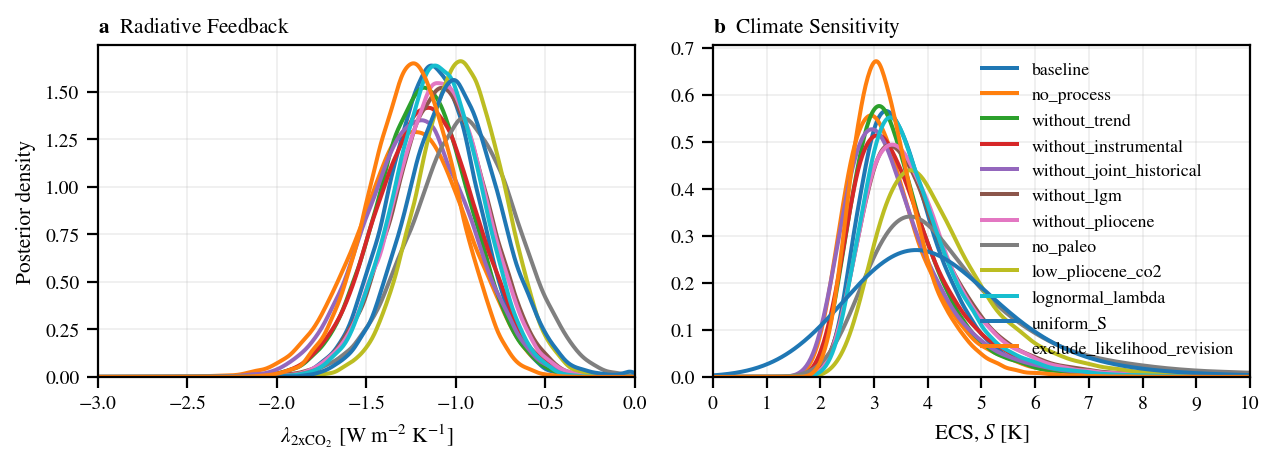

In [14]:
# Plot lambda and ECS posterior densities for every completed scenario.
save_figure = False

posterior_lambda_grid = np.linspace(-3.0, 0.0, 500)
posterior_S_grid = np.linspace(0.0, 10.0, 500)

if results:
    fig, axs = plt.subplots(1, 2, figsize=(8.0, 3.0), dpi=figure_dpi(save_figure))
    for name, entry in results.items():
        if 'process_only' in name:
            continue
        axs[0].plot(
            posterior_lambda_grid,
            gaussian_kde(entry["lamb"])(posterior_lambda_grid),
            lw=1.8, label=name,
        )
        axs[1].plot(
            posterior_S_grid,
            gaussian_kde(entry["S"])(posterior_S_grid),
            lw=1.8, label=name,
        )

    axs[0].set(
        xlabel=r"$\lambda_\mathrm{2xCO_2}$ [W m$^{-2}$ K$^{-1}$]",
        ylabel="Posterior density",
        xlim=posterior_lambda_grid[[0, -1]],
    )
    axs[1].set(
        xlabel=r"ECS, $S$ [K]",
        xlim=posterior_S_grid[[0, -1]],
    )
    axs[0].set_title(r"$\mathbf{a}$  Radiative Feedback", loc="left")
    axs[1].set_title(r"$\mathbf{b}$  Climate Sensitivity", loc="left")
    for ax in axs:
        ax.set_ylim(bottom=0)
        ax.grid(alpha=0.2)
    axs[1].legend(frameon=False, fontsize="small")

    set_feedback_ecs_axes(*axs)
    plt.tight_layout()
    maybe_despine(fig)
    save_path = ecs_pdf_path("fig_posterior_scenarios.pdf", save_figure)
    if save_path is not None:
        fig.savefig(save_path, bbox_inches="tight", dpi=save_dpi)
        print(f"saved {save_path}")
    plt.show()

NOTE TO SELF: FIX GAUSSIAN KDE SMOOTHING FOR PLOTTING


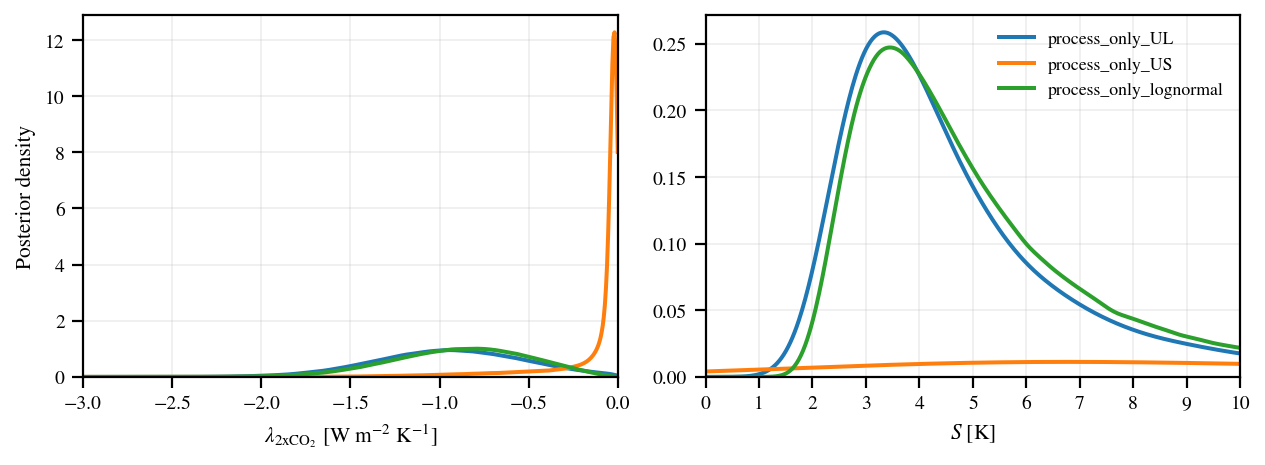

In [151]:
print("NOTE TO SELF: FIX GAUSSIAN KDE SMOOTHING FOR PLOTTING")
# Plot lambda and ECS posterior densities for every completed scenario.
posterior_lambda_grid = np.linspace(-3.0, 0.0, 500)
posterior_S_grid = np.linspace(0.0, 10.0, 500)

save_figure = False

kde_width = 0.3  # fraction of SciPy's default bandwidth; 

if results:
    fig, axs = plt.subplots(1, 2, figsize=(8.0, 3.0), dpi=figure_dpi(save_figure))
    for name, entry in results.items():
        if 'process_only' in name:
            axs[0].plot(
                posterior_lambda_grid,
                gaussian_kde(entry["lamb"])(posterior_lambda_grid),
                lw=1.8, label=name,
            )
            axs[1].plot(
                posterior_S_grid,
                gaussian_kde(
                    entry["S"],
                    bw_method=lambda kde: kde_width * kde.scotts_factor()
                )(posterior_S_grid),
                lw=1.8, label=name,
            )

    axs[0].set(
        xlabel=r"$\lambda_\mathrm{2xCO_2}$ [W m$^{-2}$ K$^{-1}$]",
        ylabel="Posterior density",
        xlim=posterior_lambda_grid[[0, -1]],
        # title=r"$\mathbf{a}$  Radiative Feedback",
    )
    axs[1].set(
        xlabel=r"$S$ [K]",
        xlim=posterior_S_grid[[0, -1]],
        # title=r"$\mathbf{b}$  Climate Sensitivity",
    )
    for ax in axs:
        ax.set_ylim(bottom=0)
        ax.grid(alpha=0.2)
    axs[1].legend(frameon=False, fontsize="small")

    set_feedback_ecs_axes(*axs)
    maybe_despine(fig)
    plt.tight_layout()
    save_path = ecs_pdf_path("fig_priors.pdf", save_figure)
    if save_path is not None:
        fig.savefig(save_path, bbox_inches="tight", dpi=save_dpi)
        print(f"saved {save_path}")
    plt.show()

saved /glade/u/home/vcooper/work/hist_sst/bayecs/figures/ecs/fig_sensitivity_tests.pdf


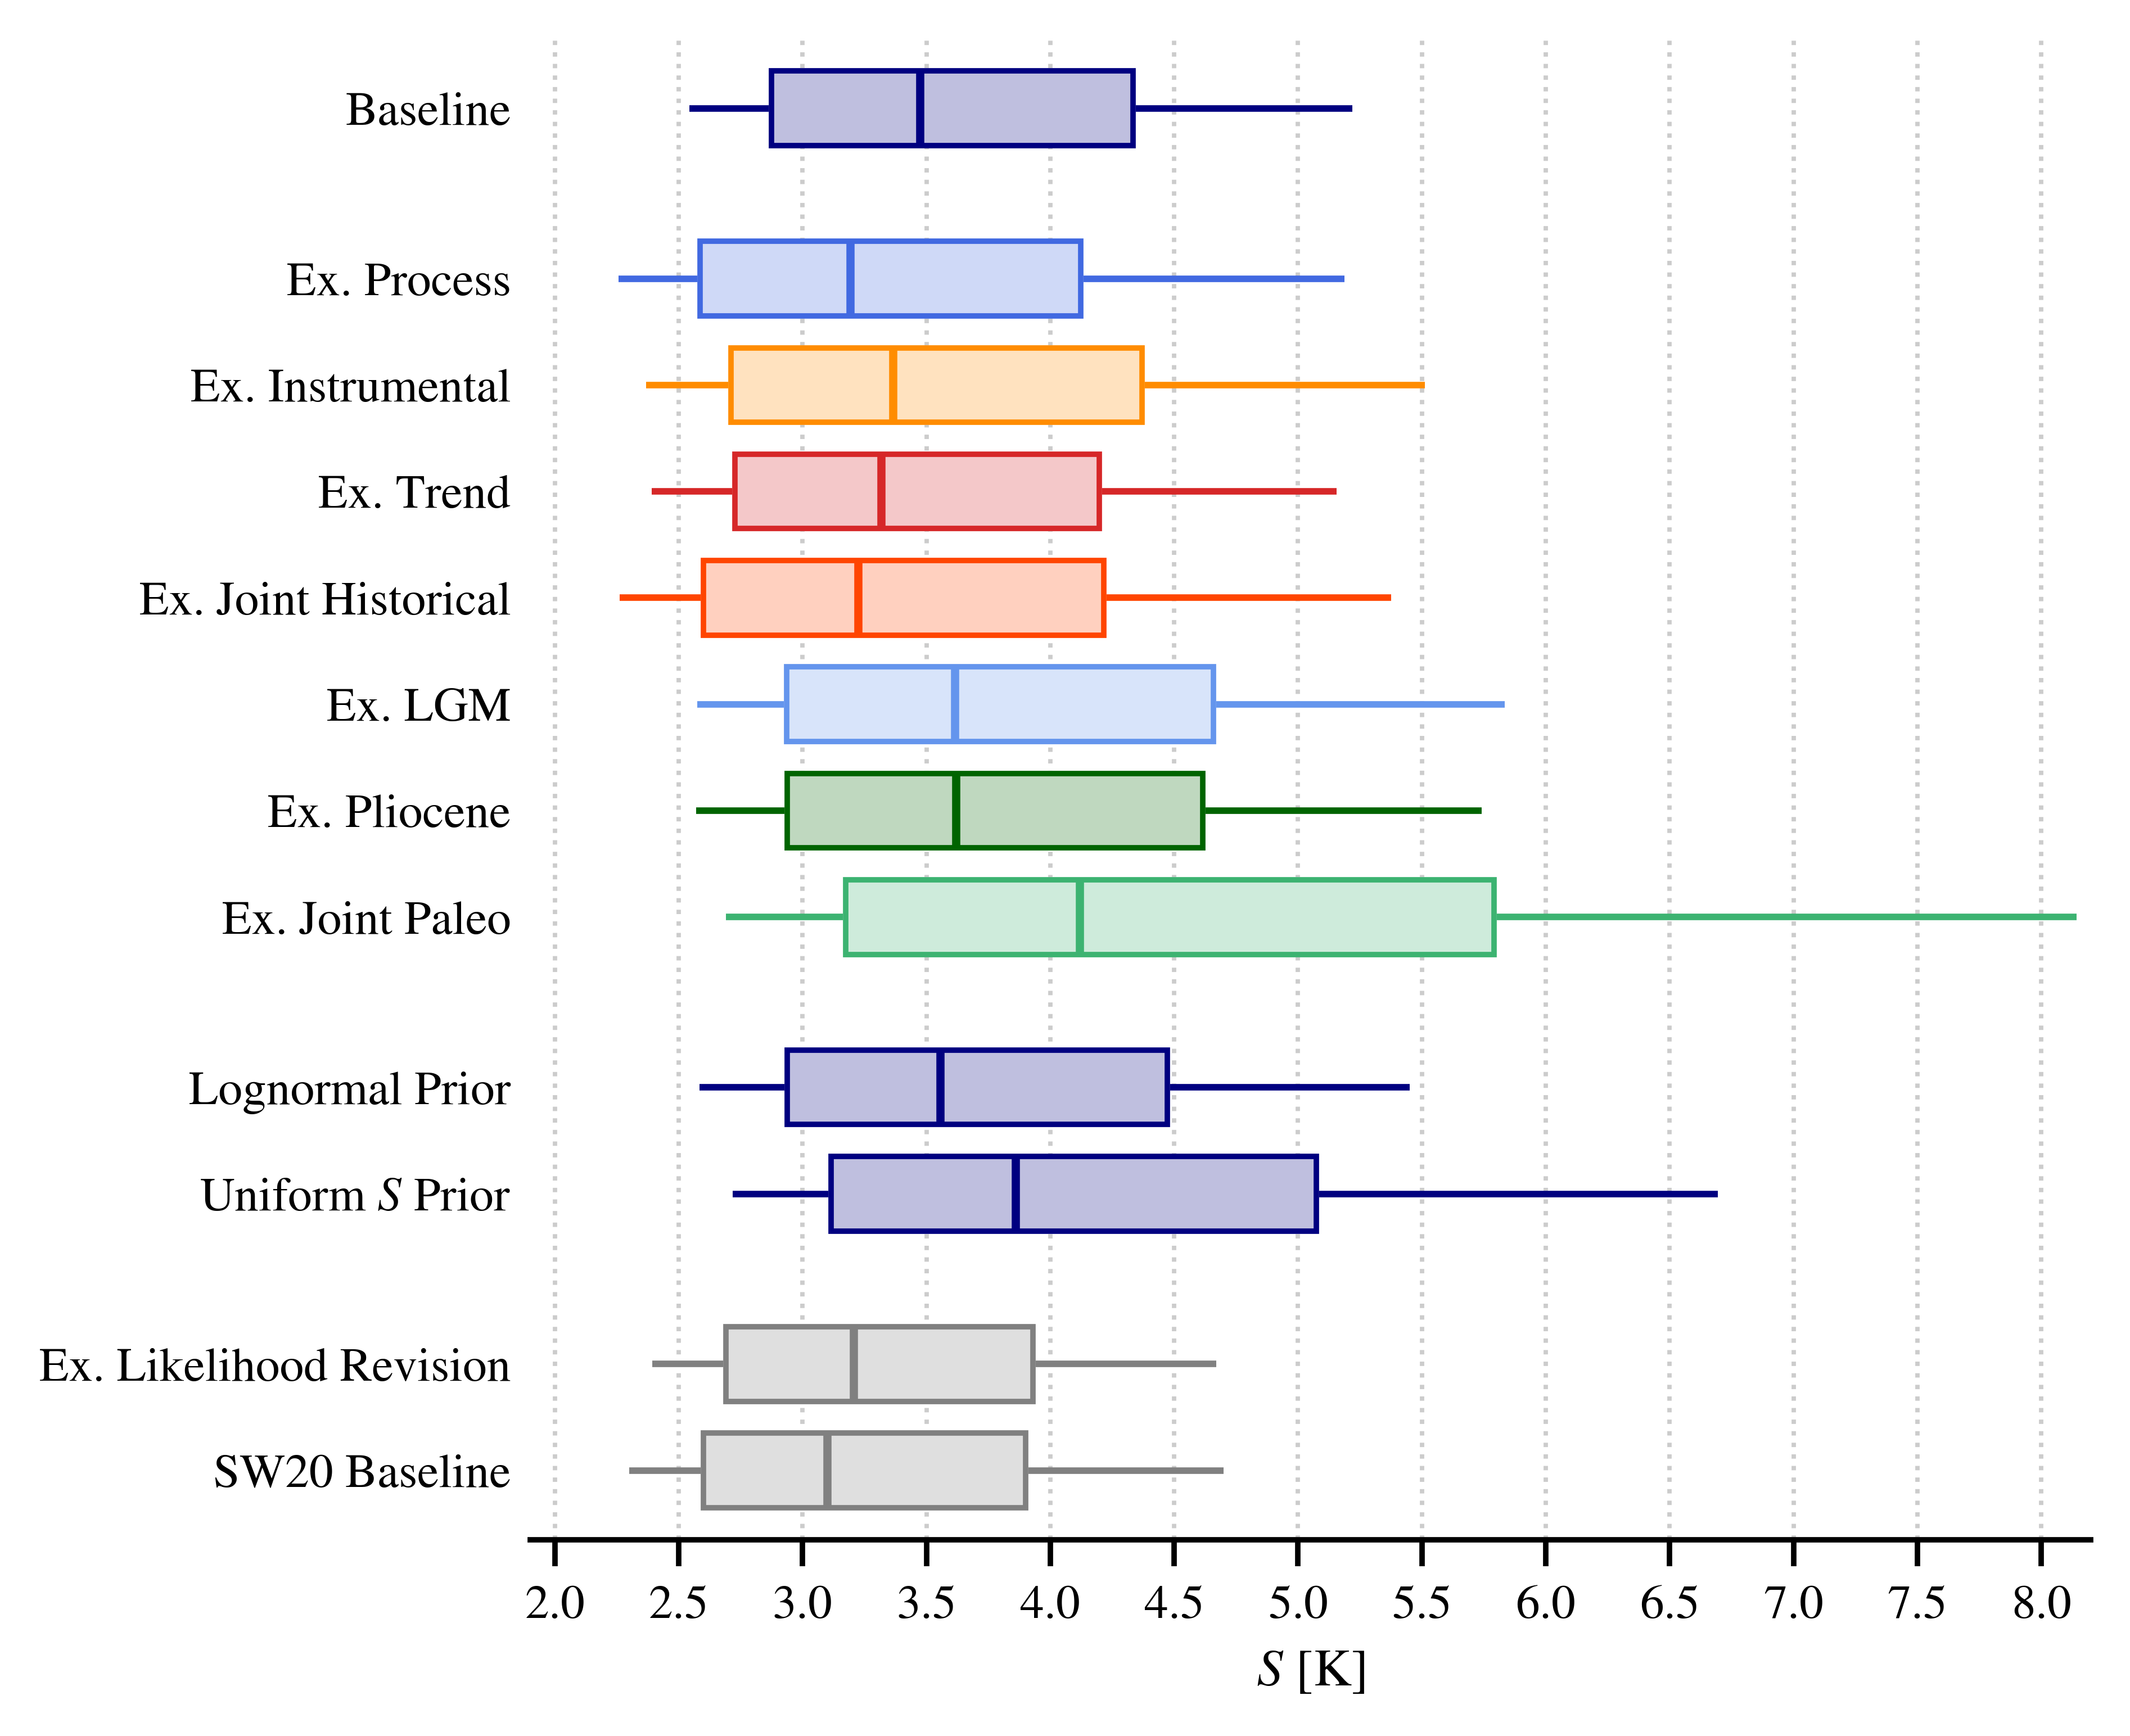

In [181]:
save_figure = True

from matplotlib.patches import Rectangle
from matplotlib.colors import to_rgba

## Label, result name, color — in plot order.
plot_rows = [
    ("Baseline",                         "baseline",                    "navy"),
    ("Ex. Process",                  "no_process",                  "royalblue"),
    ("Ex. Instrumental",             "without_instrumental",        "darkorange"),
    ("Ex. Trend",                    "without_trend",               "tab:red"),
    ("Ex. Joint Historical",         "without_joint_historical",    "orangered"),
    ("Ex. LGM",                      "without_lgm",                 "cornflowerblue"),
    ("Ex. Pliocene",                 "without_pliocene",            "darkgreen"),
    ("Ex. Joint Paleo",              "no_paleo",                    "mediumseagreen"),
    ("Lognormal Prior",                  "lognormal_lambda",            "navy"),
    ("Uniform $S$ Prior",                "uniform_S",                   "navy"),
    ("Ex. Likelihood Revision", "exclude_likelihood_revision", "gray"),
    ("SW20 Baseline",           None,                          "gray"),
]

## SW20 Table 10 baseline: 5th, 17th, 50th, 83rd, 95th percentiles.
sw20_quantiles = np.array([2.3, 2.6, 3.1, 3.9, 4.7])

missing = [key for _, key, _ in plot_rows if key is not None and key not in results]
if missing:
    raise KeyError(f"Run these scenarios first: {missing}")

quantiles = [
    sw20_quantiles if key is None
    else np.quantile(results[key]["S"], [0.05, 0.17, 0.50, 0.83, 0.95])
    for _, key, _ in plot_rows
]

## Extra separation between the baseline, evidence, prior, and method groups.
gap_after = {"Baseline", "Ex. Joint Paleo", "Uniform $S$ Prior"}
gap_size = 0.6
y_positions = []
y = 0.0
for label, _, _ in plot_rows:
    y_positions.append(y)
    y += 1.0 + (gap_size if label in gap_after else 0.0)

fig, ax = plt.subplots(figsize=(5.5, 4.5), dpi=figure_dpi(save_figure))

offset_val = 0.35
for y, (label, key, color), q in zip(y_positions, plot_rows, quantiles):
    p05, p17, median, p83, p95 = q

    ## Whiskers: central 90%.
    ax.hlines(y, p05, p95, color=color, linewidth=1.2, zorder=2)
    # ax.vlines([p05, p95], y - 0.12, y + 0.12,
    #           color=color, linewidth=1.6, zorder=2)

    ## Box: central 66%.
    ax.add_patch(Rectangle(
        (p17, y - offset_val), p83 - p17, 2*offset_val,
        facecolor='w',
        edgecolor='w', linewidth=1., zorder=2.9,
    ))
    ax.add_patch(Rectangle(
        (p17, y - offset_val), p83 - p17, 2*offset_val,
        facecolor=to_rgba(color, 0.25),
        edgecolor=color, linewidth=1., zorder=3,
    ))

    ## Median.
    ax.vlines(median, y - offset_val, y + offset_val,
              color=color, linewidth=1.5, zorder=4)

ax.set_yticks(y_positions)
ax.set_yticklabels([label for label, _, _ in plot_rows])
ax.set_ylim(y_positions[-1] + 0.65, -0.65)
ax.set_xticks(np.arange(2, 8.1, 0.5))
ax.set_xlim(1.9, 8.2)
ax.set_xlabel(r"$S$ [K]")
# ax.set_title("ECS sensitivity tests")
ax.grid(axis="x", linestyle=":", color="0.8")
ax.set_axisbelow(True)
ax.tick_params(axis="y", length=0)
ax.spines[["top", "right", "left"]].set_visible(False)



fig.tight_layout()
save_path = ecs_pdf_path("fig_sensitivity_tests.pdf", save_figure)
if save_path is not None:
    fig.savefig(save_path, bbox_inches="tight", dpi=save_dpi)
    print(f"saved {save_path}")
plt.show()

## Likelihoods: Visualizing each line of evidence

These diagnostics use the same selectable $N$-based or $T$-based convention and nuisance distributions as the Stan model. Note that the likelihoods are helpful for illustration, but the Stan model samples the posterior directly, rather than calculating independent likelihoods and multiplying them. 
Set `score_T=True` in `calculate_likelihoods` for SW20 method score $T$.

In the standalone likelihood plots, each curve is normalized to its own maximum. The $S$ likelihood curves are calculated directly as $L(\mathrm{data}\mid S)$ while marginalizing the assessed $F_{2\times CO_2}$ uncertainty; they are not transformed PDFs and therefore do not receive a Jacobian. In the combined four-panel figure, Process is instead its process-only posterior PDF under a uniform $\lambda$ prior, and the other relative likelihoods are scaled to the Process PDF maximum separately in each panel. The joint-paleo calculation averages the product of the LGM and Pliocene likelihoods using shared $F_{2\times CO_2}$ draws and correlated paleo pattern-effect draws. The joint Instrumental–Trend calculation evaluates the two budget residuals together, using their shared $F_{2\times CO_2}$ draw and the assessed cross-period aerosol and residual-other forcing covariances. Neither joint curve is obtained by multiplying the two separately marginalized curves.

In [68]:
likelihood_defaults = {
    # Quick, smooth defaults. Increase mc_draws/grid_points for publication.
    "lambda_min": -4.0,
    "lambda_max": -0.005,
    "S_min": 0.05,
    "S_max": 10.0,
    "grid_points": 2*260,
    "mc_draws": 30_000,
    "seed": 20250813,
}

individual_evidence = ("Process", "Instrumental", "Trend", "LGM", "Pliocene")
instrumental_trend_evidence = ("Instrumental", "Trend", "Joint Historical")
paleo_evidence = ("LGM", "Pliocene", "Joint Paleo")
quasi_independent_evidence = ("Process", "Joint Historical", "Joint Paleo")

likelihood_styles = {
    # "Process": dict(color="mediumblue", ls="-"),
    "Process": dict(color="#4b57db", ls="-"),
    "Instrumental": dict(color='darkorange', ls="-"),
    "Trend": dict(color='tab:red', ls="-"),
    "Joint Historical": dict(color="orangered", ls="-"),
    "LGM": dict(color="cornflowerblue", ls="-"),
    "Pliocene": dict(color="darkgreen", ls="-"),
    # "Joint Paleo": dict(color="purple", ls="-"),
    "Joint Paleo": dict(color="mediumseagreen", ls="-"),
}


def _relative_likelihood(values):
    values = np.asarray(values, dtype=float)
    peak = np.nanmax(values)
    if not np.isfinite(peak) or peak <= 0:
        raise ValueError("Likelihood curve has no finite positive values")
    return values / peak


def _normal_density_from_variance(observed, predicted_mean, variance):
    variance = np.maximum(np.asarray(variance, dtype=float), 1e-14)
    return np.exp(-0.5 * (observed - predicted_mean)**2 / variance) / np.sqrt(
        2 * np.pi * variance
    )


def _bivariate_normal_density_from_covariance(
    residual_x, residual_y, variance_x, variance_y, covariance_xy,
):
    """Evaluate a zero-mean bivariate-normal density from residuals."""
    variance_x = np.asarray(variance_x, dtype=float)
    variance_y = np.asarray(variance_y, dtype=float)
    determinant = variance_x * variance_y - covariance_xy**2
    if np.any(determinant <= 0):
        raise ValueError("Instrumental/Trend covariance is not positive definite")
    quadratic = (
        variance_y * residual_x**2
        - 2 * covariance_xy * residual_x * residual_y
        + variance_x * residual_y**2
    ) / determinant
    return np.exp(-0.5 * quadratic) / (2 * np.pi * np.sqrt(determinant))


def _meinshausen_co2_sarf(co2_ppm, n2o_ppb=273.0):
    co2_ppm = np.asarray(co2_ppm, dtype=float)
    a1, b1, c1, d1 = -2.4785e-7, 7.5906e-4, -2.1492e-3, 5.2488
    co2_ref = 277.15
    co2_alpha_max = co2_ref - b1 / (2 * a1)
    alpha_prime = np.where(
        co2_ppm <= co2_ref,
        d1,
        np.where(
            co2_ppm < co2_alpha_max,
            d1 + a1 * (co2_ppm - co2_ref)**2 + b1 * (co2_ppm - co2_ref),
            d1 - b1**2 / (4 * a1),
        ),
    )
    return (alpha_prime + c1 * np.sqrt(n2o_ppb)) * np.log(co2_ppm / co2_ref)


def _plio_co2_f2x_ratio(co2_ppm, co2_pi):
    return (
        _meinshausen_co2_sarf(co2_ppm) - _meinshausen_co2_sarf(co2_pi)
    ) / (
        _meinshausen_co2_sarf(2 * co2_pi) - _meinshausen_co2_sarf(co2_pi)
    )

In [69]:
def calculate_likelihoods(
    label="baseline", *, input_updates=None, settings_updates=None,
    process_correlation=False, score_T=False,
):
    """Calculate marginal likelihoods on lambda and S grids.

    input_updates changes assessed parameters for one sensitivity version.
    settings_updates changes grids, sample count, or seed.
    process_correlation=True applies rho_lambda_F2x to the Process curve.
    score_T=True rearranges every energy budget and scores temperature.
    """
    data = dict(base_inputs)
    input_updates = {} if input_updates is None else dict(input_updates)
    unknown_inputs = set(input_updates) - set(data)
    if unknown_inputs:
        raise KeyError(f"Unknown likelihood inputs: {sorted(unknown_inputs)}")
    data.update(input_updates)

    settings = dict(likelihood_defaults)
    settings_updates = {} if settings_updates is None else dict(settings_updates)
    unknown_settings = set(settings_updates) - set(settings)
    if unknown_settings:
        raise KeyError(f"Unknown likelihood settings: {sorted(unknown_settings)}")
    settings.update(settings_updates)

    lambda_grid = np.linspace(
        settings["lambda_min"], settings["lambda_max"],
        int(settings["grid_points"]),
    )
    S_grid = np.linspace(
        settings["S_min"], settings["S_max"],
        int(settings["grid_points"]),
    )
    n = int(settings["mc_draws"])
    rng = np.random.default_rng(settings["seed"])

    # Common draws are reused across every grid point and line of evidence.
    F2x = rng.normal(data["erf_2x"], data["sig_F2xCO2"], n)
    dlambda_instrumental = skewnorm.rvs(
        a=data["shape_dlambda_instrumental"], loc=data["loc_dlambda_instrumental"],
        scale=data["scale_dlambda_instrumental"], size=n, random_state=rng,
    )
    dlambda_trend = rng.normal(
        data["mu_dlambda_trend"], data["sig_dlambda_trend"], n
    )

    paleo_dlambda_cov = np.array([
        [
            data["sig_dlambda_LGM"]**2,
            data["rho_dlambda_LGM_plio"]
            * data["sig_dlambda_LGM"] * data["sig_dlambda_plio"],
        ],
        [
            data["rho_dlambda_LGM_plio"]
            * data["sig_dlambda_LGM"] * data["sig_dlambda_plio"],
            data["sig_dlambda_plio"]**2,
        ],
    ])
    paleo_dlambda = rng.multivariate_normal(
        [data["mu_dlambda_LGM"], data["mu_dlambda_plio"]],
        paleo_dlambda_cov, size=n,
    )
    dlambda_lgm, dlambda_plio = paleo_dlambda.T
    f_co2_lgm = rng.normal(data["mu_f_CO2_LGM"], data["sig_f_CO2_LGM"], n)
    co2_plio = rng.normal(data["mu_CO2_plio"], data["sig_CO2_plio"], n)
    f_ch4 = rng.normal(data["mu_fCH4"], data["sig_fCH4"], n)
    f_co2_plio = _plio_co2_f2x_ratio(co2_plio, data["CO2_PI"])

    rho_process = data["rho_lambda_F2x"] if process_correlation else 0.0
    if not -1 < rho_process < 1:
        raise ValueError("rho_lambda_F2x must lie strictly between -1 and 1")

    # Check each assessed instrumental-Trend forcing covariance before
    # combining them in the joint budget-residual likelihood.
    forcing_covariance_components = (
        (
            "anthropogenic aerosol",
            data["sig_F_anthro_aerosol_instrumental"],
            data["sig_F_anthro_aerosol_trend"],
            data["cov_F_anthro_aerosol_instrumental_trend"],
        ),
        (
            "residual other",
            data["sig_F_other_instrumental"],
            data["sig_F_other_trend"],
            data["cov_F_other_instrumental_trend"],
        ),
    )
    for component, sig_instrumental, sig_trend, covariance in forcing_covariance_components:
        if abs(covariance) >= sig_instrumental * sig_trend:
            raise ValueError(
                f"Instrumental-Trend {component} covariance is not positive definite"
            )
    instrumental_trend_forcing_covariance = (
        data["cov_F_anthro_aerosol_instrumental_trend"]
        + data["cov_F_other_instrumental_trend"]
    )

    instrumental_forcing_mean = (
        data["mu_F_CO2_instrumental"] * F2x / data["erf_2x"]
        + data["mu_F_anthro_aerosol_instrumental"] + data["mu_F_other_instrumental"]
    )
    instrumental_forcing_variance = (
        data["sig_F_anthro_aerosol_instrumental"]**2
        + data["sig_F_other_instrumental"]**2
    )

    def evaluate_at_lambda(lam, scalar_lambda, S_value=None):
        # Process: the lambda marginal is unchanged by its F2x correlation.
        if scalar_lambda:
            process_like = norm.pdf(lam, data["mu_lambda"], data["sig_lambda"])
        else:
            # Exact marginal for lambda = -F2x/S, including optional covariance.
            process_residual_mean = data["mu_lambda"] + data["erf_2x"] / S_value
            process_residual_variance = (
                data["sig_lambda"]**2
                + (data["sig_F2xCO2"] / S_value)**2
                + 2 * rho_process * data["sig_lambda"]
                * data["sig_F2xCO2"] / S_value
            )
            process_like = _normal_density_from_variance(
                0.0, process_residual_mean, process_residual_variance
            )

        beta_instrumental = lam - dlambda_instrumental
        instrumental_response_factor = np.abs(beta_instrumental) if score_T else 1.0
        instrumental_mean = instrumental_forcing_mean + data["mu_T_instrumental"] * beta_instrumental
        instrumental_variance = (
            data["sig_N_instrumental"]**2 + instrumental_forcing_variance
            + beta_instrumental**2 * data["sig_T_instrumental"]**2
        )
        instrumental_like = np.mean(
            instrumental_response_factor * _normal_density_from_variance(
                data["mu_N_instrumental"], instrumental_mean, instrumental_variance
            )
        )

        beta_trend = lam - dlambda_trend
        trend_response_factor = np.abs(beta_trend) if score_T else 1.0
        trend_forcing_mean = (
            data["mu_F_CO2_trend"] * F2x / data["erf_2x"]
            + data["mu_F_anthro_aerosol_trend"]
            + data["mu_F_other_trend"]
        )
        trend_mean = trend_forcing_mean + data["mu_T_trend"] * beta_trend
        trend_variance = (
            data["sig_N_trend"]**2
            + data["sig_F_anthro_aerosol_trend"]**2
            + data["sig_F_other_trend"]**2
            + beta_trend**2 * data["sig_T_trend"]**2
            - 2 * beta_trend * data["cov_TN_trend"]
        )
        trend_like = np.mean(
            trend_response_factor * _normal_density_from_variance(
                data["mu_N_trend"], trend_mean, trend_variance
            )
        )

        # Integrate the two energy-budget residuals jointly. Shared CO2
        # forcing uncertainty is represented by the common F2x draw; the
        # covariance below is only for aerosol plus residual-other forcing.
        joint_instrumental_trend_density = (
            instrumental_response_factor * trend_response_factor
            * _bivariate_normal_density_from_covariance(
                data["mu_N_instrumental"] - instrumental_mean,
                data["mu_N_trend"] - trend_mean,
                instrumental_variance,
                trend_variance,
                instrumental_trend_forcing_covariance,
            )
        )
        joint_instrumental_trend_like = np.mean(joint_instrumental_trend_density)

        beta_lgm = lam - dlambda_lgm
        lgm_response_factor = np.abs(beta_lgm) if score_T else 1.0
        lgm_mean = (
            data["mu_F_other_LGM"] + f_co2_lgm * F2x
            + data["mu_T_LGM"] * beta_lgm
        )
        lgm_variance = (
            data["sig_N_LGM"]**2 + data["sig_F_other_LGM"]**2
            + beta_lgm**2 * data["sig_T_LGM"]**2
        )
        lgm_density = lgm_response_factor * _normal_density_from_variance(
            data["mu_N_LGM"], lgm_mean, lgm_variance
        )

        beta_plio = lam - dlambda_plio
        plio_response_factor = np.abs(beta_plio) if score_T else 1.0
        plio_mean = (
            f_co2_plio * F2x * (1 + f_ch4)
            + data["mu_F_plio_nonGHG"]
            + data["mu_T_plio"] * beta_plio
        )
        plio_variance = (
            data["sig_N_plio"]**2 + data["sig_F_plio_nonGHG"]**2
            + beta_plio**2 * data["sig_T_plio"]**2
        )
        plio_density = plio_response_factor * _normal_density_from_variance(
            data["mu_N_plio"], plio_mean, plio_variance
        )

        return {
            "Process": process_like,
            "Instrumental": instrumental_like,
            "Trend": trend_like,
            "Joint Historical": joint_instrumental_trend_like,
            "LGM": np.mean(lgm_density),
            "Pliocene": np.mean(plio_density),
            # This is not the product of separately marginalized curves.
            "Joint Paleo": np.mean(lgm_density * plio_density),
        }

    raw = {
        name: {"lambda": [], "S": []}
        for name in (*individual_evidence, "Joint Historical", "Joint Paleo")
    }
    for lam in lambda_grid:
        evaluated = evaluate_at_lambda(lam, scalar_lambda=True)
        for name, value in evaluated.items():
            raw[name]["lambda"].append(value)
    for S in S_grid:
        evaluated = evaluate_at_lambda(-F2x / S, scalar_lambda=False, S_value=S)
        for name, value in evaluated.items():
            raw[name]["S"].append(value)

    curves = {
        name: {
            axis: _relative_likelihood(values)
            for axis, values in axis_values.items()
        }
        for name, axis_values in raw.items()
    }
    return {
        "label": label, "data": data, "settings": settings,
        "process_correlation": process_correlation,
        "score_T": score_T,
        "lambda_grid": lambda_grid, "S_grid": S_grid,
        "curves": curves, "raw_curves": raw,
    }

In [70]:
def _format_likelihood_axes(axs, lambda_grid, S_grid, legend=True):
    axs[0].set(
        xlabel=r"$\lambda_\mathrm{2xCO_2}$ [W m$^{-2}$ K$^{-1}$]",
        ylabel="Relative likelihood", xlim=(-3, 0),
    )
    axs[1].set(
        xlabel=r"$S$ [K]", xlim=(0,10),
    )
    axs[0].set_title(r"$\mathbf{a}$  Radiative Feedback", loc="left")
    axs[1].set_title(r"$\mathbf{b}$  Climate Sensitivity", loc="left")
    for ax in axs:
        ax.set_ylim(0, 1.05)
        ax.grid(alpha=0.2)
    set_feedback_ecs_axes(*axs)
    if legend:
        axs[0].legend(frameon=False, fontsize="small")


def _print_likelihood_peaks(curves):
    """Print the lambda and S coordinates of each plotted maximum."""
    print("Peak locations")
    for label, lambda_grid, lambda_curve, S_grid, S_curve in curves:
        lambda_peak = np.asarray(lambda_grid)[np.nanargmax(lambda_curve)]
        S_peak = np.asarray(S_grid)[np.nanargmax(S_curve)]
        print(
            f"{label}: lambda = {lambda_peak:.4f} W m^-2 K^-1; "
            f"S = {S_peak:.3f} K"
        )


def plot_likelihoods(
    result, evidence=individual_evidence, *, process_pdf=None,
    report_peaks=True, title="", save=None, styles=None,
):
    """Plot selected evidence curves from one likelihood calculation.

    If process_pdf is supplied, the Process curve is plotted as a proper
    posterior PDF and the other likelihoods are scaled to the maximum of
    that PDF. Scaling is done separately in lambda and S space.
    """
    fig, axs = plt.subplots(1, 2, figsize=(8.0, 3.0), dpi=figure_dpi(save is not None))

    if process_pdf is not None:
        process_curves = {
            "lambda": np.asarray(process_pdf["lambda_pdf"]),
            "S": np.asarray(process_pdf["S_pdf"]),
        }
        for parameter, grid in (
            ("lambda", result["lambda_grid"]),
            ("S", result["S_grid"]),
        ):
            pdf_grid = np.asarray(process_pdf[f"{parameter}_grid"])
            if pdf_grid.shape != np.asarray(grid).shape or not np.allclose(
                pdf_grid, grid
            ):
                raise ValueError(
                    f"The Process PDF and likelihood {parameter} grids must match"
                )
        process_peaks = {
            parameter: np.nanmax(curve)
            for parameter, curve in process_curves.items()
        }

    plotted_curves = []
    for name in evidence:
        style = {"lw": 1.8, **likelihood_styles.get(name, {})}
        if styles is not None:
            style.update(styles.get(name, {}))
        label = "Process PDF" if process_pdf is not None and name == "Process" else name
        if process_pdf is not None and name == "Process":
            lambda_curve = process_curves["lambda"]
            S_curve = process_curves["S"]
        elif process_pdf is not None:
            lambda_curve = (
                result["curves"][name]["lambda"] * process_peaks["lambda"]
            )
            S_curve = result["curves"][name]["S"] * process_peaks["S"]
        else:
            lambda_curve = result["curves"][name]["lambda"]
            S_curve = result["curves"][name]["S"]
        axs[0].plot(
            result["lambda_grid"], lambda_curve,
            label=label, **style,
        )
        axs[1].plot(
            result["S_grid"], S_curve,
            label=label, **style,
        )
        plotted_curves.append((
            label, result["lambda_grid"], lambda_curve,
            result["S_grid"], S_curve,
        ))
    _format_likelihood_axes(axs, result["lambda_grid"], result["S_grid"])
    if process_pdf is not None:
        for ax in axs:
            ax.set_ylabel("PDF / Relative Likelihood")
        for ax, parameter in zip(axs, ("lambda", "S")):
            ax.set_ylim(0, 1.05 * process_peaks[parameter])
    if title:
        fig.suptitle(title, x=0.06, ha="left", y=1.02)
    maybe_despine(fig)
    plt.tight_layout()
    if save is not None:
        fig.savefig(save, bbox_inches="tight", dpi=save_dpi)
    plt.show()
    if report_peaks:
        _print_likelihood_peaks(plotted_curves)
    return fig, axs


def plot_likelihood_versions(
    versions, evidence, *, styles=None, report_peaks=True,
    title="", save=None,
):
    """Overlay one line of evidence from several sensitivity versions."""
    fig, axs = plt.subplots(1, 2, figsize=(8.0, 3.0), dpi=figure_dpi(save is not None))
    plotted_curves = []
    for label, result in versions.items():
        if styles is None:
            style = {}
            if label in {"This Assessment", "SW20"}:
                style["ls"] = ":" if label == "SW20" else "-"
                evidence_color = likelihood_styles.get(evidence, {}).get("color")
                if evidence_color is not None:
                    style["color"] = evidence_color
        else:
            style = styles.get(label, {})
        axs[0].plot(
            result["lambda_grid"], result["curves"][evidence]["lambda"],
            lw=1.8, label=label, **style,
        )
        axs[1].plot(
            result["S_grid"], result["curves"][evidence]["S"],
            lw=1.8, label=label, **style,
        )
        plotted_curves.append((
            label, result["lambda_grid"],
            result["curves"][evidence]["lambda"],
            result["S_grid"], result["curves"][evidence]["S"],
        ))
    first = next(iter(versions.values()))
    _format_likelihood_axes(axs, first["lambda_grid"], first["S_grid"])
    if title:
        fig.suptitle(title, x=0.06, ha="left", y=1.02)
    maybe_despine(fig)
    plt.tight_layout()
    if save is not None:
        fig.savefig(save, bbox_inches="tight", dpi=save_dpi)
    plt.show()
    if report_peaks:
        _print_likelihood_peaks(plotted_curves)
    return fig, axs


def calculate_process_only_posterior(
    result, *, lambda_prior_bounds=(-20.0, -0.01),
    process_correlation=False, forcing_grid_points=2_000,
):
    """Process-only posterior PDF for S under a fixed uniform-lambda prior.

    The Process likelihood and F2x assessment are combined in (F2x, lambda)
    space, then transformed to S=-F2x/lambda with the required F2x/S**2
    Jacobian. The returned S curve is an area-normalized PDF, not a
    peak-normalized likelihood.
    """
    data = result["data"]
    lambda_lower, lambda_upper = map(float, lambda_prior_bounds)
    if not lambda_lower < lambda_upper < 0:
        raise ValueError(
            "lambda_prior_bounds must satisfy lower < upper < 0"
        )

    rho = data["rho_lambda_F2x"] if process_correlation else 0.0
    if not -1 < rho < 1:
        raise ValueError("rho_lambda_F2x must lie strictly between -1 and 1")

    mu_F, sig_F = data["erf_2x"], data["sig_F2xCO2"]
    mu_lamb, sig_lamb = data["mu_lambda"], data["sig_lambda"]
    F_grid = np.linspace(
        max(1e-8, mu_F - 8 * sig_F),
        mu_F + 8 * sig_F,
        int(forcing_grid_points),
    )
    F_density = norm.pdf(F_grid, mu_F, sig_F)

    # Conditional lambda distribution implied by the optional bivariate
    # Gaussian Process/F2x assessment. With rho=0 this reduces to the
    # independent Process likelihood used by the baseline.
    conditional_lamb_mean = (
        mu_lamb + rho * sig_lamb / sig_F * (F_grid - mu_F)
    )
    conditional_lamb_sd = sig_lamb * np.sqrt(1 - rho**2)
    prior_interval_mass = (
        norm.cdf(
            (lambda_upper - conditional_lamb_mean) / conditional_lamb_sd
        )
        - norm.cdf(
            (lambda_lower - conditional_lamb_mean) / conditional_lamb_sd
        )
    )
    joint_normalization = np.trapz(
        F_density * prior_interval_mass, F_grid
    )

    S_grid = result["S_grid"]
    lamb_at_S = -F_grid[None, :] / S_grid[:, None]
    lamb_density_given_F = norm.pdf(
        (lamb_at_S - conditional_lamb_mean[None, :])
        / conditional_lamb_sd
    ) / conditional_lamb_sd
    inside_prior = (
        (lamb_at_S >= lambda_lower) & (lamb_at_S <= lambda_upper)
    )
    transformed_joint = (
        F_density[None, :] * lamb_density_given_F * inside_prior
        * F_grid[None, :] / S_grid[:, None]**2
    )
    S_pdf = np.trapz(transformed_joint, F_grid, axis=1) / joint_normalization

    lambda_grid = result["lambda_grid"]
    lambda_likelihood = norm.pdf(lambda_grid, mu_lamb, sig_lamb)
    lambda_prior_mass = (
        norm.cdf((lambda_upper - mu_lamb) / sig_lamb)
        - norm.cdf((lambda_lower - mu_lamb) / sig_lamb)
    )
    lambda_pdf = np.where(
        (lambda_grid >= lambda_lower) & (lambda_grid <= lambda_upper),
        lambda_likelihood / lambda_prior_mass,
        0.0,
    )
    return {
        "lambda_grid": lambda_grid,
        "lambda_likelihood": _relative_likelihood(lambda_likelihood),
        "lambda_pdf": lambda_pdf,
        "S_grid": S_grid,
        "S_pdf": S_pdf,
        "lambda_prior_bounds": (lambda_lower, lambda_upper),
        "process_correlation": process_correlation,
    }


def plot_process_likelihood_and_posterior(
    process_result, *, sw20_result=None, report_peaks=True,
    title="", save=None,
):
    """Plot process likelihoods and process-only S posterior PDFs."""
    fig, axs = plt.subplots(1, 2, figsize=(8.0, 3.0), dpi=figure_dpi(save is not None))
    style = likelihood_styles["Process"]
    axs[0].plot(
        process_result["lambda_grid"],
        process_result["lambda_likelihood"],
        lw=1.8, label="This assessment", **style,
    )
    axs[1].plot(
        process_result["S_grid"], process_result["S_pdf"],
        lw=1.8, label="This assessment", **style,
    )
    plotted_curves = [(
        "This assessment", process_result["lambda_grid"],
        process_result["lambda_likelihood"],
        process_result["S_grid"], process_result["S_pdf"],
    )]
    if sw20_result is not None:
        for ax, grid_name, curve_name in (
            (axs[0], "lambda_grid", "lambda_likelihood"),
            (axs[1], "S_grid", "S_pdf"),
        ):
            ax.plot(sw20_result[grid_name], sw20_result[curve_name],
                    color=style["color"], ls=":", lw=1.5, label="SW20")
        plotted_curves.append((
            "SW20", sw20_result["lambda_grid"],
            sw20_result["lambda_likelihood"],
            sw20_result["S_grid"], sw20_result["S_pdf"],
        ))

    axs[0].set(
        xlabel=r"$\lambda_\mathrm{2xCO_2}$ [W m$^{-2}$ K$^{-1}$]",
        ylabel="Relative likelihood", xlim=(-3, 0), ylim=(0, 1.02),
    )
    axs[1].set(
        xlabel=r"$S$ [K]", ylabel=r"Posterior density [K$^{-1}$]",
        xlim=(0, 10), ylim=(0, None),
    )
    axs[0].set_title(r"$\mathbf{a}$  Process likelihood", loc="left")
    axs[1].set_title(r"$\mathbf{b}$  Process posterior", loc="left")
    for ax in axs:
        ax.grid(alpha=0.2)
    set_feedback_ecs_axes(*axs)
    if sw20_result is not None:
        axs[0].legend(frameon=False)
    if title:
        fig.suptitle(title, x=0.06, ha="left", y=1.02)
    maybe_despine(fig)
    plt.tight_layout()
    if save is not None:
        fig.savefig(save, bbox_inches="tight", dpi=save_dpi)
    plt.show()
    if report_peaks:
        _print_likelihood_peaks(plotted_curves)
    return fig, axs

### Baseline likelihood calculation

This calculation includes all five individual diagnostics whether or not that line is enabled in a particular Stan run. Its Process-correlation choice follows `baseline_switches`.

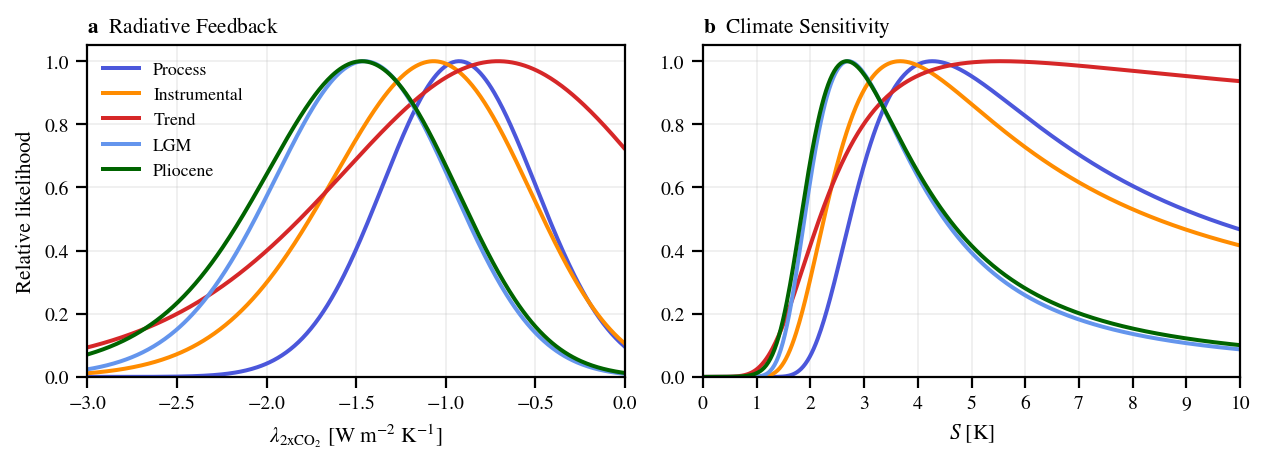

Peak locations
Process: lambda = -0.9287 W m^-2 K^-1; S = 4.268 K
Instrumental: lambda = -1.0673 W m^-2 K^-1; S = 3.673 K
Trend: lambda = -0.7055 W m^-2 K^-1; S = 5.533 K
LGM: lambda = -1.4521 W m^-2 K^-1; S = 2.715 K
Pliocene: lambda = -1.4675 W m^-2 K^-1; S = 2.676 K


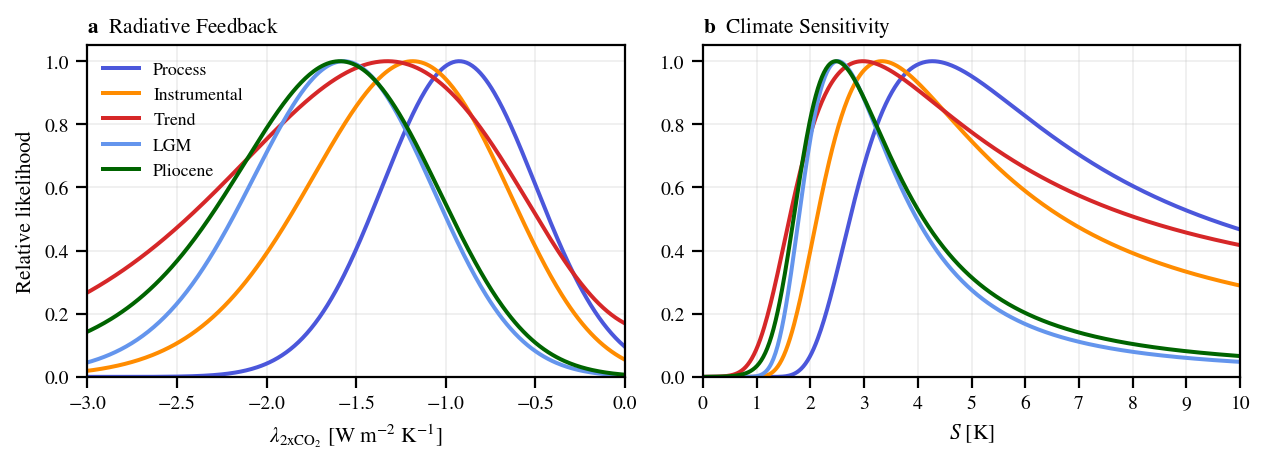

Peak locations
Process: lambda = -0.9287 W m^-2 K^-1; S = 4.268 K
Instrumental: lambda = -1.1827 W m^-2 K^-1; S = 3.328 K
Trend: lambda = -1.3290 W m^-2 K^-1; S = 2.983 K
LGM: lambda = -1.5676 W m^-2 K^-1; S = 2.504 K
Pliocene: lambda = -1.5907 W m^-2 K^-1; S = 2.485 K


In [71]:
## Baseline (N-based)
likelihood_results = {}
likelihood_results["baseline"] = calculate_likelihoods(
    "baseline",
    score_T=0,
)
likelihood_result_scoreN = likelihood_results["baseline"]

plot_likelihoods(
    likelihood_results["baseline"],
    evidence=individual_evidence,
    title="",
)
plt.show()

## T-based version
likelihood_results_scoreT = {}
likelihood_results_scoreT["baseline"] = calculate_likelihoods(
    "baseline",
    score_T=1,
)
likelihood_result_scoreT = likelihood_results_scoreT["baseline"]
plot_likelihoods(
    likelihood_results_scoreT["baseline"],
    evidence=individual_evidence,
    title="",
)
plt.show()

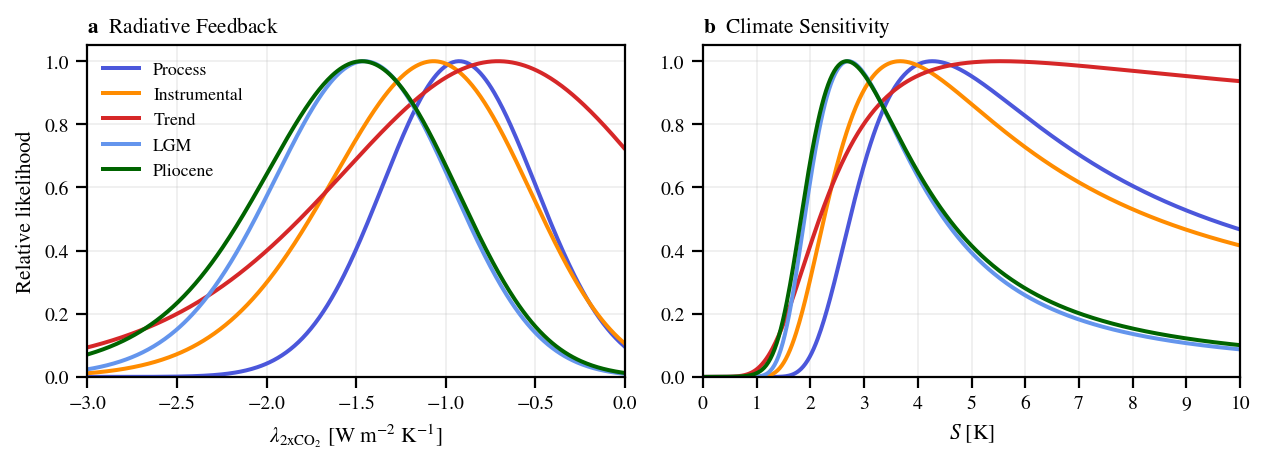

Peak locations
Process: lambda = -0.9287 W m^-2 K^-1; S = 4.268 K
Instrumental: lambda = -1.0673 W m^-2 K^-1; S = 3.673 K
Trend: lambda = -0.7055 W m^-2 K^-1; S = 5.533 K
LGM: lambda = -1.4521 W m^-2 K^-1; S = 2.715 K
Pliocene: lambda = -1.4675 W m^-2 K^-1; S = 2.676 K


(<Figure size 1280x480 with 2 Axes>,
 array([<Axes: title={'left': '$\\mathbf{a}$  Radiative Feedback'}, xlabel='$\\lambda_\\mathrm{2xCO_2}$ [W m$^{-2}$ K$^{-1}$]', ylabel='Relative likelihood'>,
        <Axes: title={'left': '$\\mathbf{b}$  Climate Sensitivity'}, xlabel='$S$ [K]'>],
       dtype=object))

In [43]:
save_figure = False

likelihood_results = {}
likelihood_results["baseline"] = calculate_likelihoods(
    "baseline",
    process_correlation=bool(baseline_switches["use_lambda_F2x_correlation"]),
    score_T=bool(baseline_switches["use_score_T"]),
)

plot_likelihoods(
    likelihood_results["baseline"],
    evidence=individual_evidence,
    title="",
    save=ecs_pdf_path("fig_individual_likelihoods.pdf", save_figure),
)

### Process likelihood and process-only posterior

The left panel shows the Process likelihood in $\lambda$ space for this assessment and SW20. The right panel shows each process-only posterior PDF of $S=-F_{2\times CO_2}/\lambda$, using the same uniform prior over $-20 < \lambda < -0.01$ W m$^{-2}$ K$^{-1}$. SW20 uses its own process assessment, $\lambda=-1.30\pm0.44$ W m$^{-2}$ K$^{-1}$, and $F_{2\times CO_2}=4.00\pm0.30$ W m$^{-2}$; the current curve uses the inputs above. The transformation includes the required $F_{2\times CO_2}/S^2$ Jacobian.

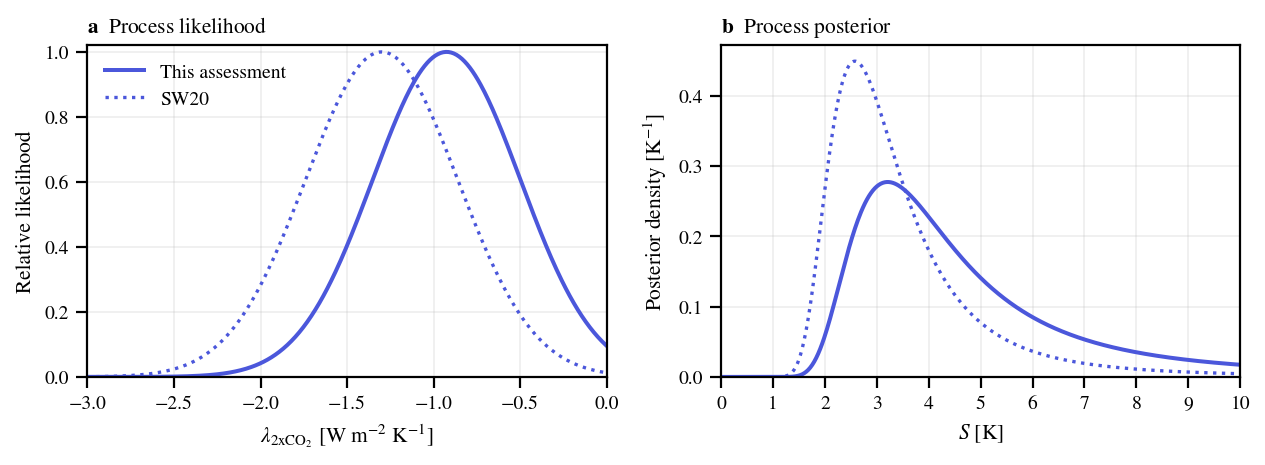

Peak locations
This assessment: lambda = -0.9287 W m^-2 K^-1; S = 3.213 K
SW20: lambda = -1.2982 W m^-2 K^-1; S = 2.581 K


(<Figure size 1280x480 with 2 Axes>,
 array([<Axes: title={'left': '$\\mathbf{a}$  Process likelihood'}, xlabel='$\\lambda_\\mathrm{2xCO_2}$ [W m$^{-2}$ K$^{-1}$]', ylabel='Relative likelihood'>,
        <Axes: title={'left': '$\\mathbf{b}$  Process posterior'}, xlabel='$S$ [K]', ylabel='Posterior density [K$^{-1}$]'>],
       dtype=object))

In [60]:
save_figure = False

process_lambda_prior_bounds = (-50.0, -0.01)
process_only_posterior = calculate_process_only_posterior(
    likelihood_results["baseline"],
    lambda_prior_bounds=process_lambda_prior_bounds,
    process_correlation=bool(
        baseline_switches["use_lambda_F2x_correlation"]
    ),
)

## SW20 process feedback and doubled-CO2 ERF (Table 1).
## Apply the same uniform-lambda prior to both assessments.
sw20_process_result = {
    "lambda_grid": likelihood_results["baseline"]["lambda_grid"],
    "S_grid": likelihood_results["baseline"]["S_grid"],
    "data": {
        **likelihood_results["baseline"]["data"],
        "mu_lambda": -1.30, "sig_lambda": 0.44,
        "erf_2x": 4.00, "sig_F2xCO2": 0.30,
        "rho_lambda_F2x": 0.0,
    },
}
sw20_process_only_posterior = calculate_process_only_posterior(
    sw20_process_result,
    lambda_prior_bounds=process_lambda_prior_bounds,
    process_correlation=False,
)

plot_process_likelihood_and_posterior(
    process_only_posterior,
    sw20_result=sw20_process_only_posterior,
    title="",  # r"Process evidence with a uniform $\lambda$ prior"
    save=ecs_pdf_path("fig_process_likely.pdf", save_figure),
)

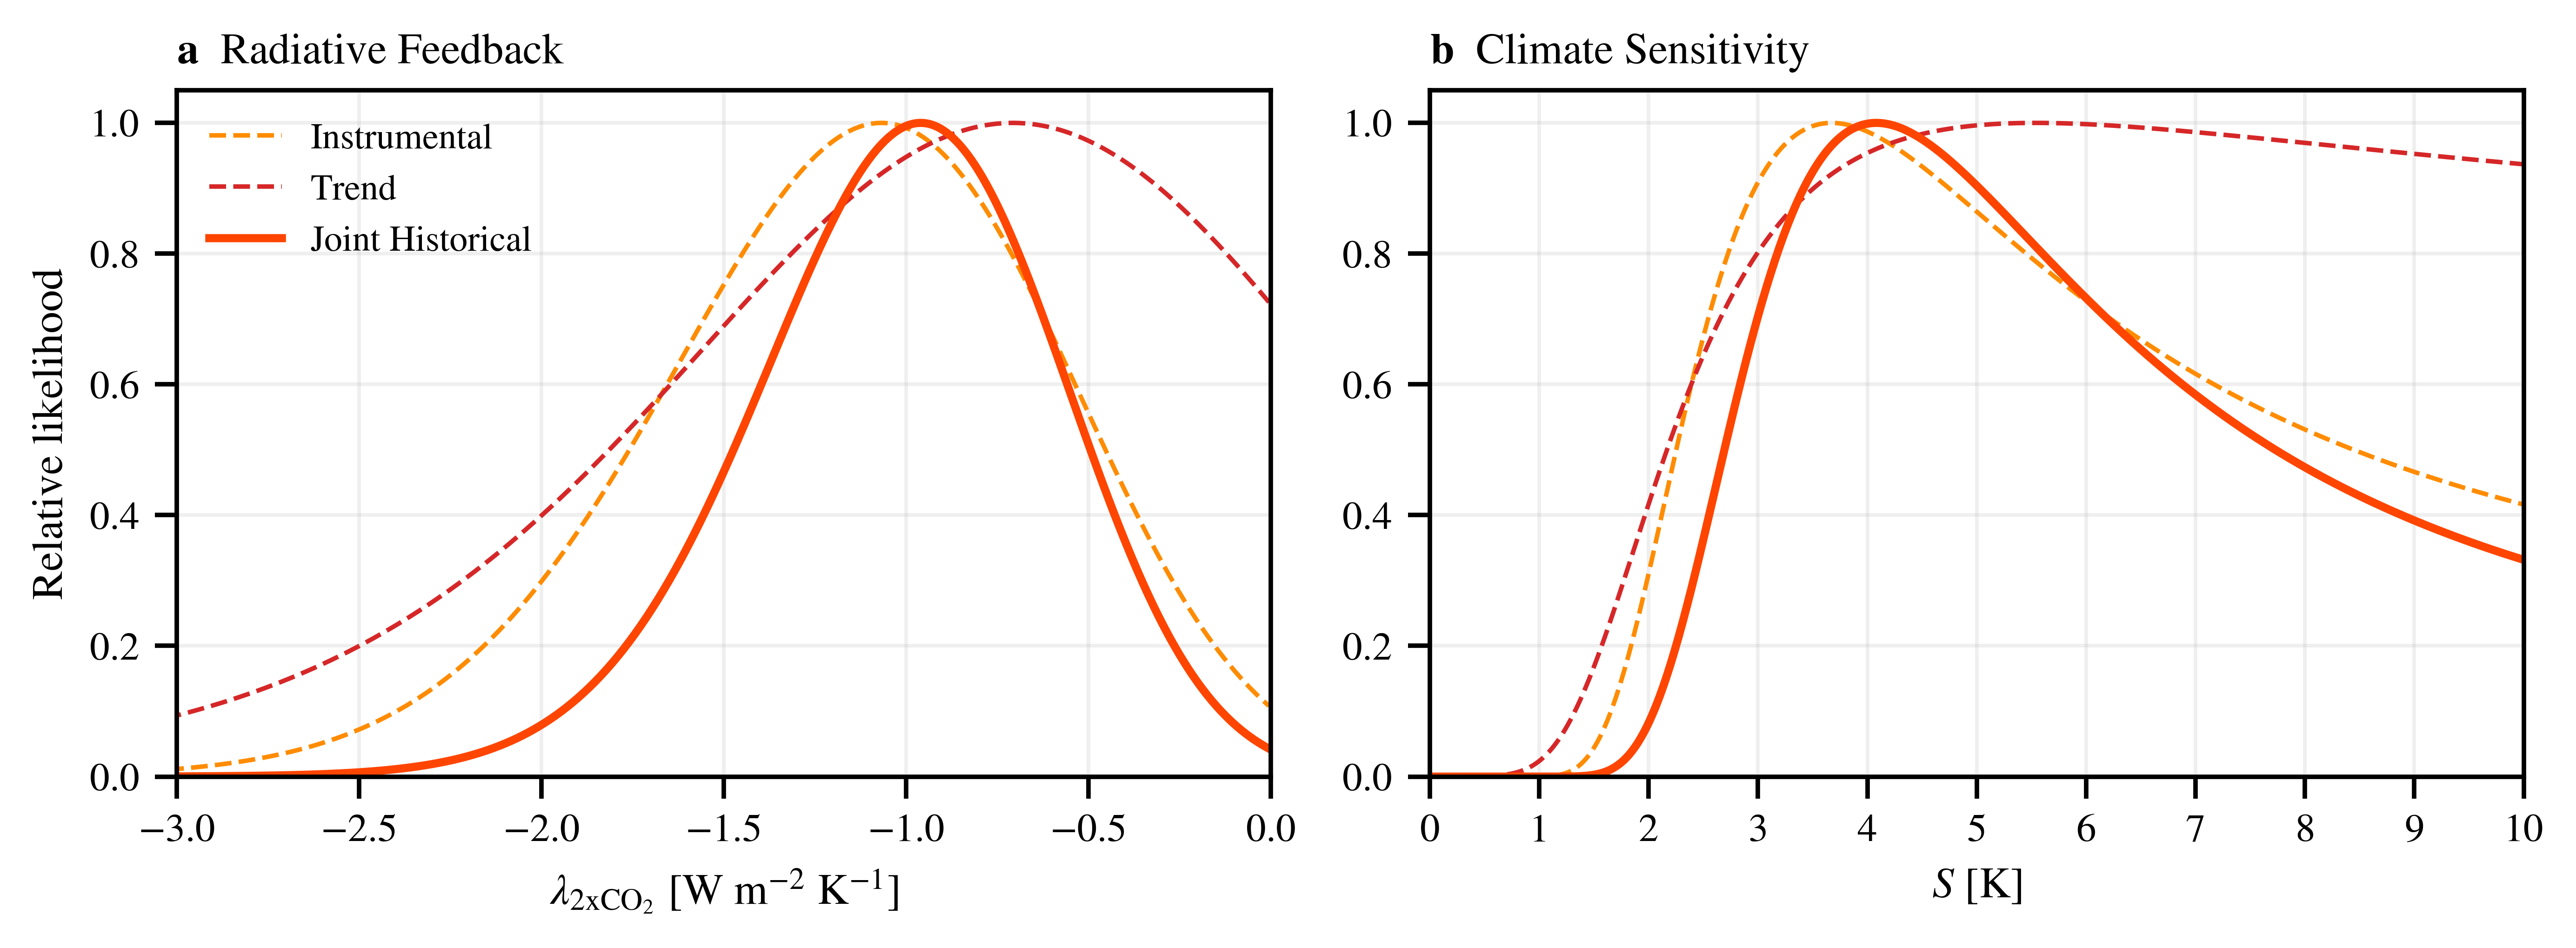

Peak locations
Instrumental: lambda = -1.0673 W m^-2 K^-1; S = 3.673 K
Trend: lambda = -0.7055 W m^-2 K^-1; S = 5.533 K
Joint Historical: lambda = -0.9595 W m^-2 K^-1; S = 4.076 K


In [61]:
save_figure = False

# Joint Historical uses shared F_2xCO2 draws and the assessed
# cross-period aerosol and residual-other forcing covariances. It is not
# the product of the separately marginalized Instrumental and Trend curves.
plot_likelihoods(
    likelihood_results["baseline"],
    evidence=instrumental_trend_evidence,
    styles={name: {"ls": "--", "lw": 1.}
            for name in instrumental_trend_evidence[:-1]},
    title="",  # "Instrumental and Trend likelihoods and their joint constraint"
    save=ecs_pdf_path("fig_joint_hist.pdf", save_figure),
)
plt.show()

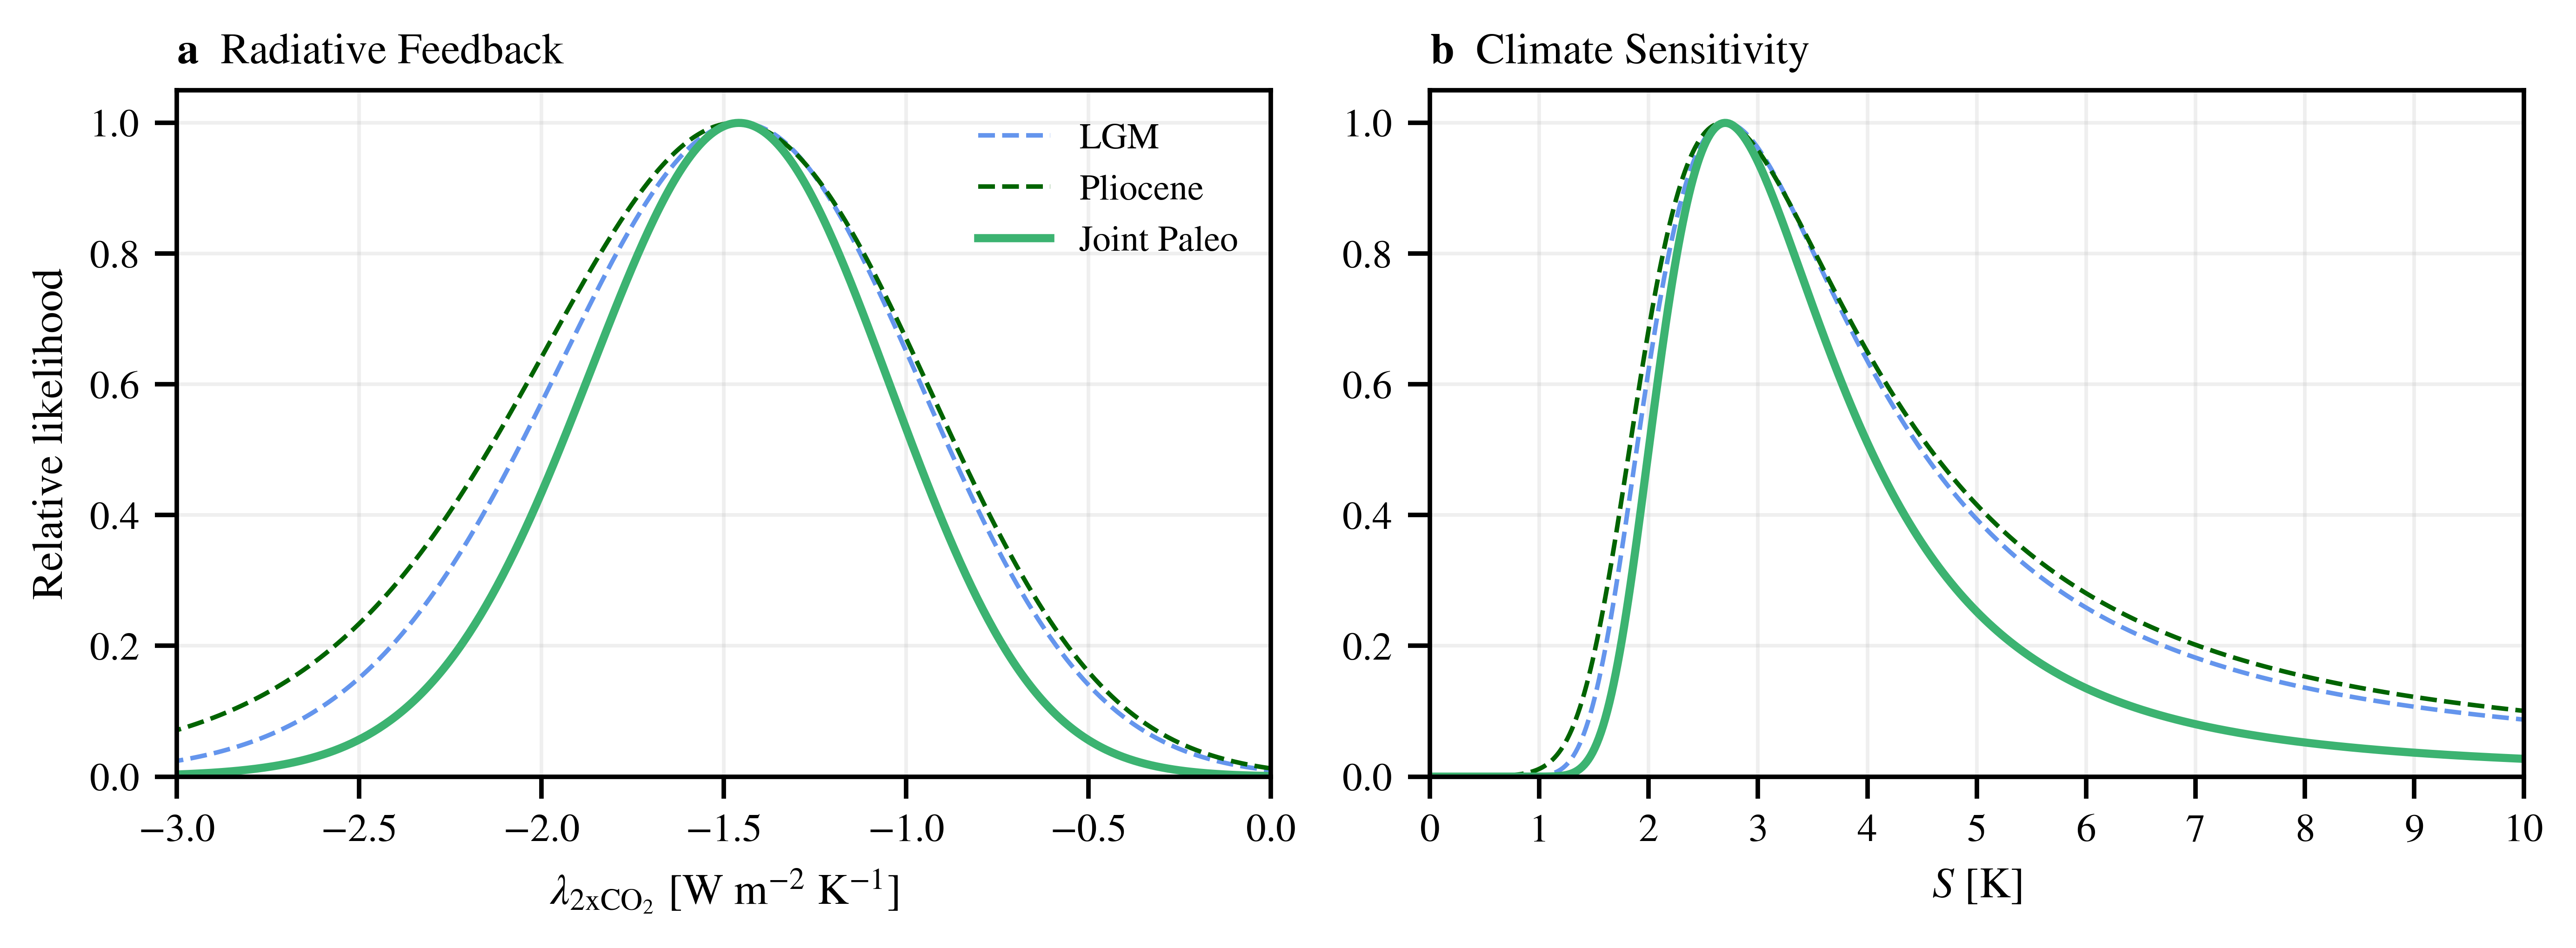

Peak locations
LGM: lambda = -1.4521 W m^-2 K^-1; S = 2.715 K
Pliocene: lambda = -1.4675 W m^-2 K^-1; S = 2.676 K
Joint Paleo: lambda = -1.4598 W m^-2 K^-1; S = 2.696 K


In [72]:
save_figure = False

# Joint Paleo uses shared F_2xCO2 draws and the assessed
# LGM-Pliocene pattern-effect correlation. It is not L_LGM * L_Pliocene.
plot_likelihoods(
    likelihood_results["baseline"],
    evidence=paleo_evidence,
    styles={name:  {"ls": "--", "lw": 1.}
            for name in paleo_evidence[:-1]},
    # title="Paleo likelihoods and their joint constraint",
    save=ecs_pdf_path("fig_joint_paleo.pdf", save_figure),
)
plt.show()

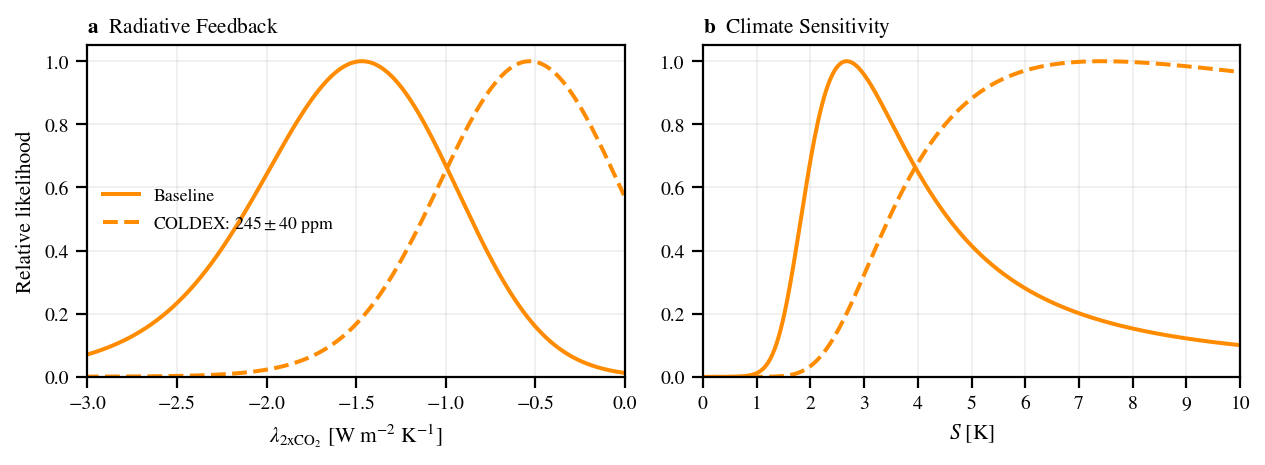

Peak locations
Baseline: lambda = -1.4675 W m^-2 K^-1; S = 2.676 K
COLDEX: $245\pm40$ ppm: lambda = -0.5284 W m^-2 K^-1; S = 7.431 K


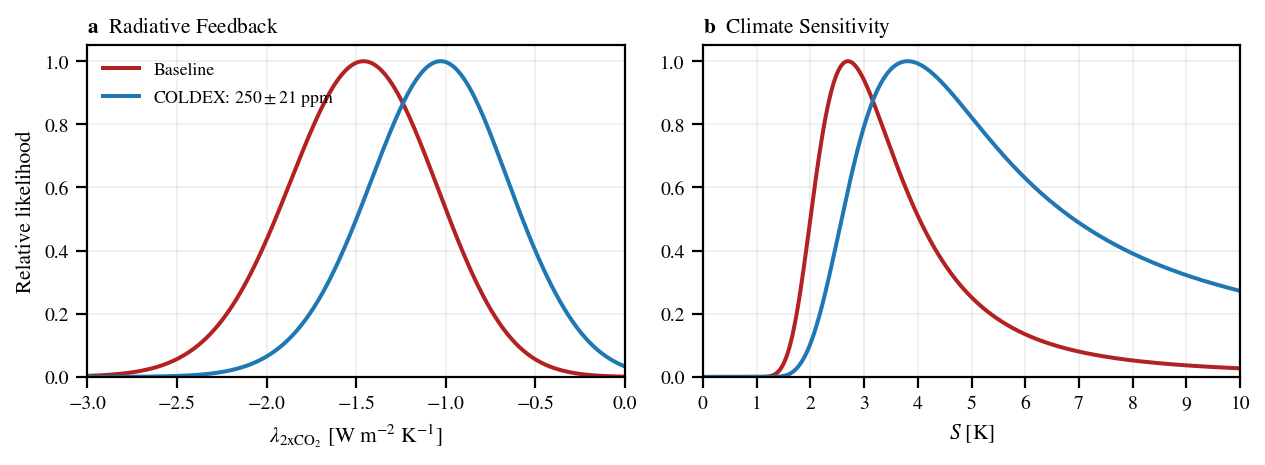

Peak locations
Baseline: lambda = -1.4598 W m^-2 K^-1; S = 2.696 K
COLDEX: $250\pm21$ ppm: lambda = -1.0288 W m^-2 K^-1; S = 3.808 K


In [63]:
save_figure = False

## Calculate the likelihood with the COLDEX CO2 estimate.
likelihood_results["coldex_plio_co2"] = calculate_likelihoods(
    "COLDEX Pliocene CO2",
    input_updates={
        "mu_CO2_plio": 250.0,
        "sig_CO2_plio": 21.,
    },
    process_correlation=bool(
        baseline_switches["use_lambda_F2x_correlation"]
    ),
    score_T=bool(baseline_switches["use_score_T"]),
)

## Compare the Pliocene likelihoods.
plot_likelihood_versions(
    {
        "Baseline": likelihood_results["baseline"],
        r"COLDEX: $245\pm40$ ppm": likelihood_results["coldex_plio_co2"],
    },
    evidence="Pliocene",
    styles={
        "Baseline": dict(color="darkorange", ls="-"),
        r"COLDEX: $245\pm40$ ppm": dict(color="darkorange", ls="--"),
    },
    title="",
    save=ecs_pdf_path("fig_plio_co2_sensitivity.pdf", save_figure),
)
plt.show()

plot_likelihood_versions(
    {
        "Baseline": likelihood_results["baseline"],
        r"COLDEX: $250\pm21$ ppm": likelihood_results["coldex_plio_co2"],
    },
    evidence="Joint Paleo",
    styles={
        "Baseline": dict(color="firebrick", ls="-"),
        r"COLDEX: $245\pm40$ ppm": dict(color="firebrick", ls="--"),
    },
    title="",
    save=ecs_pdf_path("fig_joint_paleo_co2_sensitivity.pdf", save_figure),
)
plt.show()

All lines of evidence
Peak locations
Process PDF: lambda = -0.9287 W m^-2 K^-1; S = 3.213 K
Instrumental: lambda = -1.0673 W m^-2 K^-1; S = 3.673 K
Trend: lambda = -0.7055 W m^-2 K^-1; S = 5.533 K
LGM: lambda = -1.4521 W m^-2 K^-1; S = 2.715 K
Pliocene: lambda = -1.4675 W m^-2 K^-1; S = 2.676 K
Pseudo-independent lines
Peak locations
Process PDF: lambda = -0.9287 W m^-2 K^-1; S = 3.213 K
Joint Historical: lambda = -0.9595 W m^-2 K^-1; S = 4.076 K
Joint Paleo: lambda = -1.4598 W m^-2 K^-1; S = 2.696 K


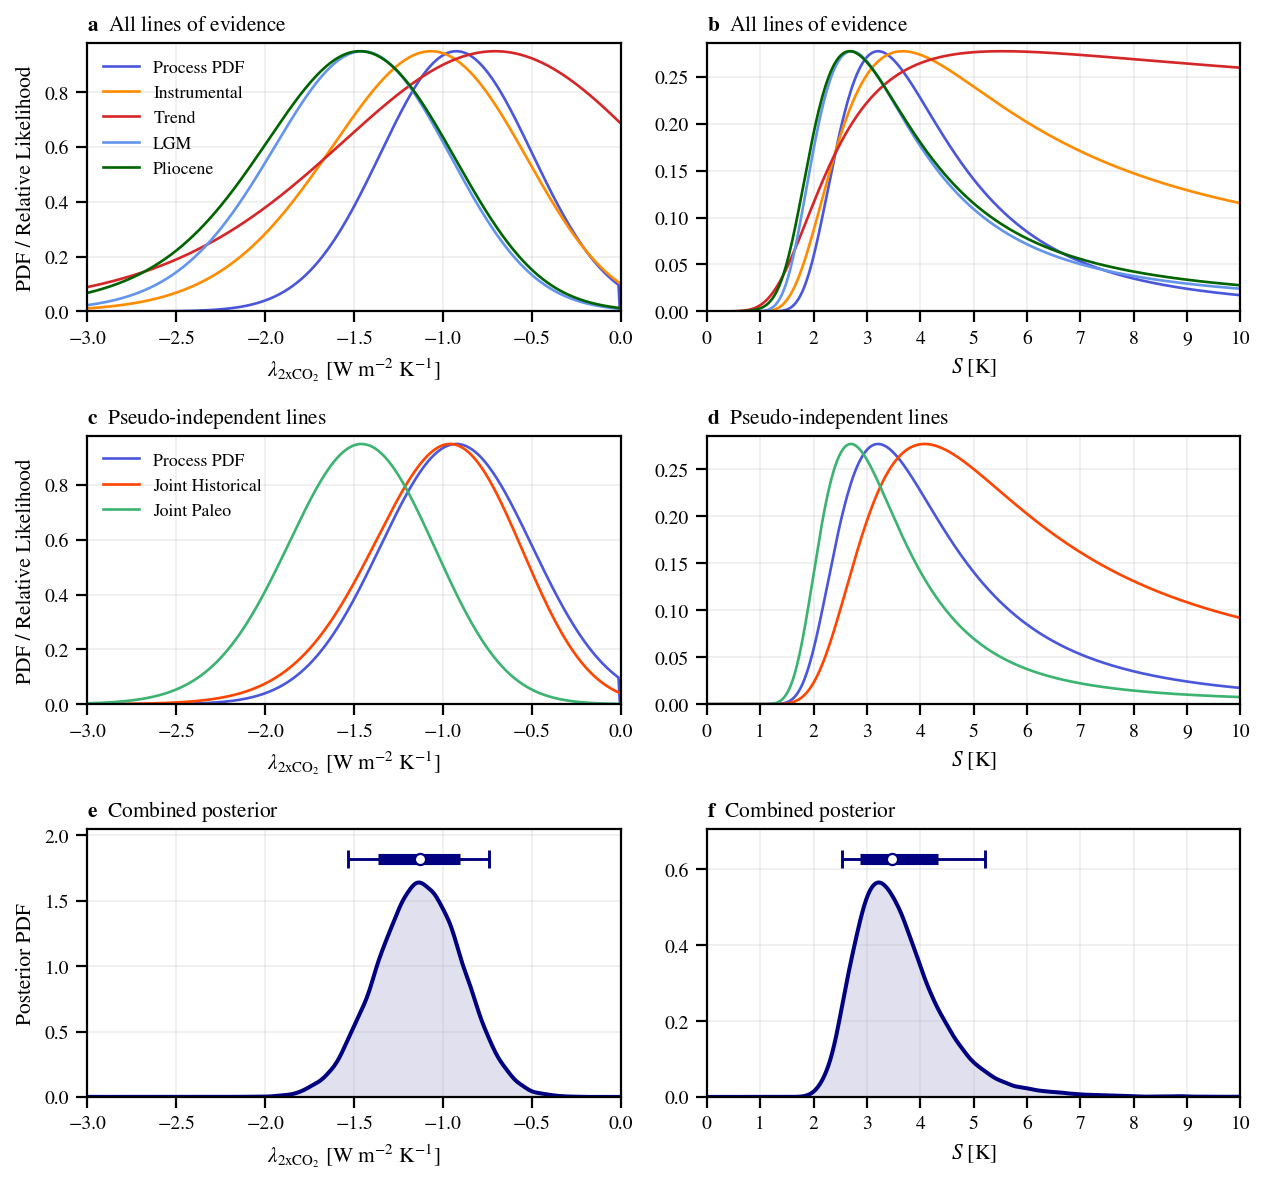

In [183]:
save_figure = False

## Combined display: Process is a posterior PDF under a uniform-lambda
## prior; each relative likelihood is scaled to the Process PDF maximum
## separately in lambda and S space. The other curves are not PDFs.
def plot_combined_evidence(result, process_pdf, posterior, *, report_peaks=True, save=None):
    parameters = ("lambda", "S")
    process_curves = {}
    process_peaks = {}
    for parameter in parameters:
        grid = np.asarray(result[f"{parameter}_grid"])
        pdf_grid = np.asarray(process_pdf[f"{parameter}_grid"])
        curve = np.asarray(process_pdf[f"{parameter}_pdf"])
        if grid.shape != pdf_grid.shape or not np.allclose(grid, pdf_grid):
            raise ValueError(f"Process PDF and likelihood {parameter} grids differ")
        if curve.shape != grid.shape:
            raise ValueError(f"Process {parameter} PDF has the wrong shape")
        peak = np.nanmax(curve)
        if not np.isfinite(peak) or peak <= 0:
            raise ValueError(f"Process {parameter} PDF has no positive peak")
        process_curves[parameter] = curve
        process_peaks[parameter] = peak

    evidence_rows = (
        ("All lines of evidence", individual_evidence),
        ("Pseudo-independent lines", quasi_independent_evidence),
    )
    panel_letters = (("a", "b"), ("c", "d"), ("e", "f"))
    fig, axs = plt.subplots(3, 2, figsize=(8., 7.5), dpi=figure_dpi(save is not None))

    for row, (row_title, evidence) in enumerate(evidence_rows):
        plotted_curves = []
        for name in evidence:
            label = "Process PDF" if name == "Process" else name
            curves = {
                parameter: (
                    process_curves[parameter] if name == "Process"
                    else result["curves"][name][parameter] * process_peaks[parameter]
                )
                for parameter in parameters
            }
            style = {"lw": 1.2, **likelihood_styles.get(name, {})}
            for column, parameter in enumerate(parameters):
                axs[row, column].plot(
                    result[f"{parameter}_grid"], curves[parameter],
                    label=label, **style,
                )
            plotted_curves.append((
                label, result["lambda_grid"], curves["lambda"],
                result["S_grid"], curves["S"],
            ))

        for column, parameter in enumerate(parameters):
            ax = axs[row, column]
            letter = panel_letters[row][column]
            ax.set_title(rf"$\mathbf{{{letter}}}$  {row_title}", loc="left")
            ax.set_ylim(0, 1.03 * process_peaks[parameter])
            ax.set_xlabel(
                r"$\lambda_\mathrm{2xCO_2}$ [W m$^{-2}$ K$^{-1}$]"
                if parameter == "lambda" else r"$S$ [K]"
            )
            ax.grid(alpha=0.2)
        set_feedback_ecs_axes(*axs[row])
        axs[row, 0].legend(frameon=False, fontsize="small")
        axs[row, 0].set_ylabel("PDF / Relative Likelihood")
        if report_peaks:
            print(row_title)
            _print_likelihood_peaks(plotted_curves)

    ## The final row is the baseline posterior from Stan, not a rescaled likelihood.
    for column, (parameter, draw_name) in enumerate((("lambda", "lamb"), ("S", "S"))):
        ax = axs[2, column]
        grid = np.asarray(result[f"{parameter}_grid"])
        draws = np.asarray(posterior[draw_name])
        density = gaussian_kde(draws)(grid)
        q05, q17, median, q83, q95 = np.quantile(draws, [0.05, 0.17, 0.50, 0.83, 0.95])
        ax.plot(grid, density, color="navy", lw=1.8)
        ax.fill_between(grid, density, color="navy", alpha=0.12)

        ## Thin whisker: 90%; thick box: 66%; white dot: median.
        peak = np.max(density)
        interval_y = 1.11 * peak
        ax.hlines(interval_y, q05, q95, color="navy", lw=1.3, zorder=4)
        ax.plot([q05, q95], [interval_y, interval_y], "|", color="navy",
                ms=8, mew=1.3, zorder=5)
        ax.hlines(interval_y, q17, q83, color="navy", lw=5, zorder=5)
        ax.plot(median, interval_y, "o", mfc="white", mec="navy",
                ms=5, zorder=6)
        ax.set_ylim(0, 1.25 * peak)
        ax.set_title(rf"$\mathbf{{{panel_letters[2][column]}}}$  Combined posterior", loc="left")
        ax.set_xlabel(
            r"$\lambda_\mathrm{2xCO_2}$ [W m$^{-2}$ K$^{-1}$]"
            if parameter == "lambda" else r"$S$ [K]"
        )
        ax.grid(alpha=0.2)
    axs[2, 0].set_ylabel("Posterior PDF")
    set_feedback_ecs_axes(*axs[2])

    maybe_despine(fig)
    fig.tight_layout(h_pad=1.0, w_pad=1.0)
    if save is not None:
        fig.savefig(save, bbox_inches="tight", dpi=save_dpi)
    plt.show()
    return fig, axs

fig_combined, axs_combined = plot_combined_evidence(
    likelihood_results["baseline"], process_only_posterior, results["baseline"],
    save=ecs_pdf_path("fig_combined_likelihoods.pdf", save_figure),
)

### SW20 instrumental likelihood comparison

This compares the current Instrumental evidence with the SW20 Historical baseline inputs from their Table 5. The default SW20 forcing calculation reconstructs the component Monte Carlo method used for their historical forcing: the unconstrained Bellouin et al. (2020) aerosol distribution, asymmetric uncertainty in the other components, and CO$_2$ forcing scaled by the shared $F_{2\times CO_2}$ draw. The simpler two-piece Z transform in `Cooper_SW20.stan` remains available with `forcing_method="z"`; it matches SW20's reported median and 5--95% limits but not the full PDF. Score T follows SW20's original likelihood convention, while Score N scores the energy-budget residual. The reconstructed curve need not exactly match the published figure because Table 5 rounds its inputs and the original curve used a separate Monte Carlo/histogram calculation.

In [74]:
## SW20 Table 5 baseline inputs. All reported spreads are converted to
## 1 sigma using the Gaussian 5--95% factor.
sw20_z90 = 1.645
sw20_instrumental_inputs = {
    "erf_2x": 4.0,
    "sig_F2xCO2": 0.3,
    "mu_T_instrumental": 1.03,
    "sig_T_instrumental": (1.03 - 0.89) / sw20_z90,
    "mu_N_instrumental": 0.60,
    "sig_N_instrumental": (0.60 - 0.30) / sw20_z90,
    "mu_F_instrumental": 1.83,  ## Median and join point for the Z approximation.
    "sig_F_instrumental_low": (1.83 - (-0.03)) / sw20_z90,
    "sig_F_instrumental_high": (2.71 - 1.83) / sw20_z90,
    "mu_F_CO2_instrumental": 1.7302332251548254,
    "mu_dlambda_instrumental": 0.50,
    "sig_dlambda_instrumental": (0.50 - 0.00) / sw20_z90,
}


## Bellouin et al. (2020), Eq. 8, with the input ranges used by SW20.
## Each pair is the assessed 16th and 84th percentile of a uniform input.
sw20_aerosol_ranges = {
    "dtau": (0.02, 0.04), "tau": (0.13, 0.17),
    "S_tau": (-20, -27), "RFari_cloudy": (-0.1, 0.1),
    "dR_dRatm": (-0.1, -0.3), "dRatm_dtau": (17, 35),
    "c_tau": (0.59, 0.71), "c_N": (0.19, 0.29),
    "c_L": (0.21, 0.29), "c_C": (0.59, 1.07),
    "beta_N_tau": (0.3, 0.8), "beta_L_N": (-0.36, -0.011),
    "beta_C_N": (0, 0.1), "S_N": (-26, -27),
    "S_L": (-54, -56), "S_C": (-91, -153),
}

## Historical changes and forcing-range inputs from the archived SW20 files
## Forster_forcings_2018_WCRP_Bellouinaerosol2.csv and
## WCRP_forcing_ranges_200311.csv (1861--1880 to 2006--2018).
## Each row is (period change, central 1750--2018, lower, upper).
sw20_other_forcing_components = {
    "Other WMGHG": (0.969024364, 1.01, 0.80, 1.20),
    "O3 (T)": (0.348192308, 0.40, 0.20, 0.60),
    "O3 (S)": (-0.050000000, -0.05, -0.15, 0.05),
    "ERF LUC": (-0.106384615, -0.15, -0.25, -0.05),
    "Vapour": (0.063692308, 0.04, 0.02, 0.09),
    "BC snow": (0.020000000, 0.07, 0.02, 0.12),
    "contrails": (0.047692308, 0.05, 0.02, 0.15),
    "Solar": (0.016923077, 0.05, 0.00, 0.10),
    "Volcanic": (-0.112961538, -1.00, -1.30, -0.70),
}

def _sw20_component_forcing(rng, n, F2x, data):
    ## Draw the unconstrained aerosol ERF from the assessed process ranges.
    aerosol_inputs = {}
    for name, (p16, p84) in sw20_aerosol_ranges.items():
        extension = (p84 - p16) * 16 / 68
        lower, upper = p16 - extension, p84 + extension
        aerosol_inputs[name] = lower + (upper - lower) * rng.random(n)
    a = aerosol_inputs
    dln_tau = a["dtau"] / a["tau"]
    erf_aerosol = (
        a["dtau"] * a["S_tau"] * (1 - a["c_tau"])
        + a["RFari_cloudy"]
        + a["dtau"] * a["dR_dRatm"] * a["dRatm_dtau"]
        + dln_tau * a["beta_N_tau"] * (
            a["S_N"] * a["c_N"]
            + a["beta_L_N"] * a["S_L"] * a["c_L"]
            + a["beta_C_N"] * a["S_C"] * a["c_C"]
        )
    )
    ## Scale the period's aerosol change as in the SW20 forcing code.
    forcing = -0.815175214 * erf_aerosol / -0.87
    for period_change, center, low, high in sw20_other_forcing_components.values():
        z = rng.standard_normal(n)
        lower_scale = (center - low) / (1.64 * center)
        upper_scale = (high - center) / (1.64 * center)
        forcing += period_change * (1 + np.where(
            z < 0, z * lower_scale, z * upper_scale
        ))
    ## The CO2 part shares the sampled F2x uncertainty.
    return forcing + data["mu_F_CO2_instrumental"] * F2x / data["erf_2x"]


def calculate_sw20_instrumental_likelihood(
    label="SW20", *, score_T=False, forcing_method="components", input_updates=None,
    settings_updates=None,
):
    """Calculate the SW20 Historical likelihood in lambda and S space."""
    data = dict(sw20_instrumental_inputs)
    input_updates = {} if input_updates is None else dict(input_updates)
    unknown_inputs = set(input_updates) - set(data)
    if unknown_inputs:
        raise KeyError(
            f"Unknown SW20 Instrumental inputs: {sorted(unknown_inputs)}"
        )
    data.update(input_updates)

    settings = dict(likelihood_defaults)
    settings_updates = {} if settings_updates is None else dict(settings_updates)
    unknown_settings = set(settings_updates) - set(settings)
    if unknown_settings:
        raise KeyError(f"Unknown likelihood settings: {sorted(unknown_settings)}")
    settings.update(settings_updates)

    lambda_grid = np.linspace(
        settings["lambda_min"], settings["lambda_max"],
        int(settings["grid_points"]),
    )
    S_grid = np.linspace(
        settings["S_min"], settings["S_max"],
        int(settings["grid_points"]),
    )
    n = int(settings["mc_draws"])
    rng = np.random.default_rng(settings["seed"])

    ## Reuse common nuisance draws across the lambda and S grids.
    F2x = rng.normal(data["erf_2x"], data["sig_F2xCO2"], n)
    if forcing_method == "components":
        F_instrumental = _sw20_component_forcing(rng, n, F2x, data)
    elif forcing_method == "z":
        ## The Cooper_SW20.stan approximation preserves SW20's reported
        ## median and 5--95% range, but not the full forcing-PDF shape.
        forcing_z = rng.standard_normal(n)
        F_instrumental = np.where(
            forcing_z < 0,
            data["mu_F_instrumental"]
            + forcing_z * data["sig_F_instrumental_low"],
            data["mu_F_instrumental"]
            + forcing_z * data["sig_F_instrumental_high"],
        )
    else:
        raise ValueError('forcing_method must be "components" or "z"')
    dlambda_instrumental = rng.normal(
        data["mu_dlambda_instrumental"],
        data["sig_dlambda_instrumental"], n,
    )

    def evaluate_at_lambda(lamb):
        beta = lamb - dlambda_instrumental
        budget_mean = (
            F_instrumental + data["mu_T_instrumental"] * beta
        )
        budget_variance = (
            data["sig_N_instrumental"]**2
            + beta**2 * data["sig_T_instrumental"]**2
        )
        density = _normal_density_from_variance(
            data["mu_N_instrumental"], budget_mean, budget_variance
        )
        if score_T:
            ## Change the scored response variable from N to T.
            density = np.abs(beta) * density
        return np.mean(np.where(np.isfinite(density), density, 0.0))

    raw_curves = {
        "Instrumental": {
            "lambda": np.asarray([
                evaluate_at_lambda(lamb) for lamb in lambda_grid
            ]),
            "S": np.asarray([
                evaluate_at_lambda(-F2x / S) for S in S_grid
            ]),
        }
    }
    curves = {
        "Instrumental": {
            axis: _relative_likelihood(values)
            for axis, values in raw_curves["Instrumental"].items()
        }
    }
    return {
        "label": label, "data": data, "settings": settings,
        "score_T": bool(score_T),
        "forcing_method": forcing_method,
        "forcing_quantiles": np.quantile(F_instrumental, [0.05, 0.50, 0.95]),
        "lambda_grid": lambda_grid, "S_grid": S_grid,
        "curves": curves, "raw_curves": raw_curves,
    }


## Switch to "z" to recover the earlier two-piece approximation.
sw20_instrumental_forcing_method = "components"
sw20_instrumental_mc_draws = 100_000  ## Smooth the long aerosol tail.
sw20_instrumental_likelihood_results = {
    "N": calculate_sw20_instrumental_likelihood(
        "SW20, Score N", score_T=False,
        forcing_method=sw20_instrumental_forcing_method,
        settings_updates={"mc_draws": sw20_instrumental_mc_draws},
    ),
    "T": calculate_sw20_instrumental_likelihood(
        "SW20, Score T", score_T=True,
        forcing_method=sw20_instrumental_forcing_method,
        settings_updates={"mc_draws": sw20_instrumental_mc_draws},
    ),
}


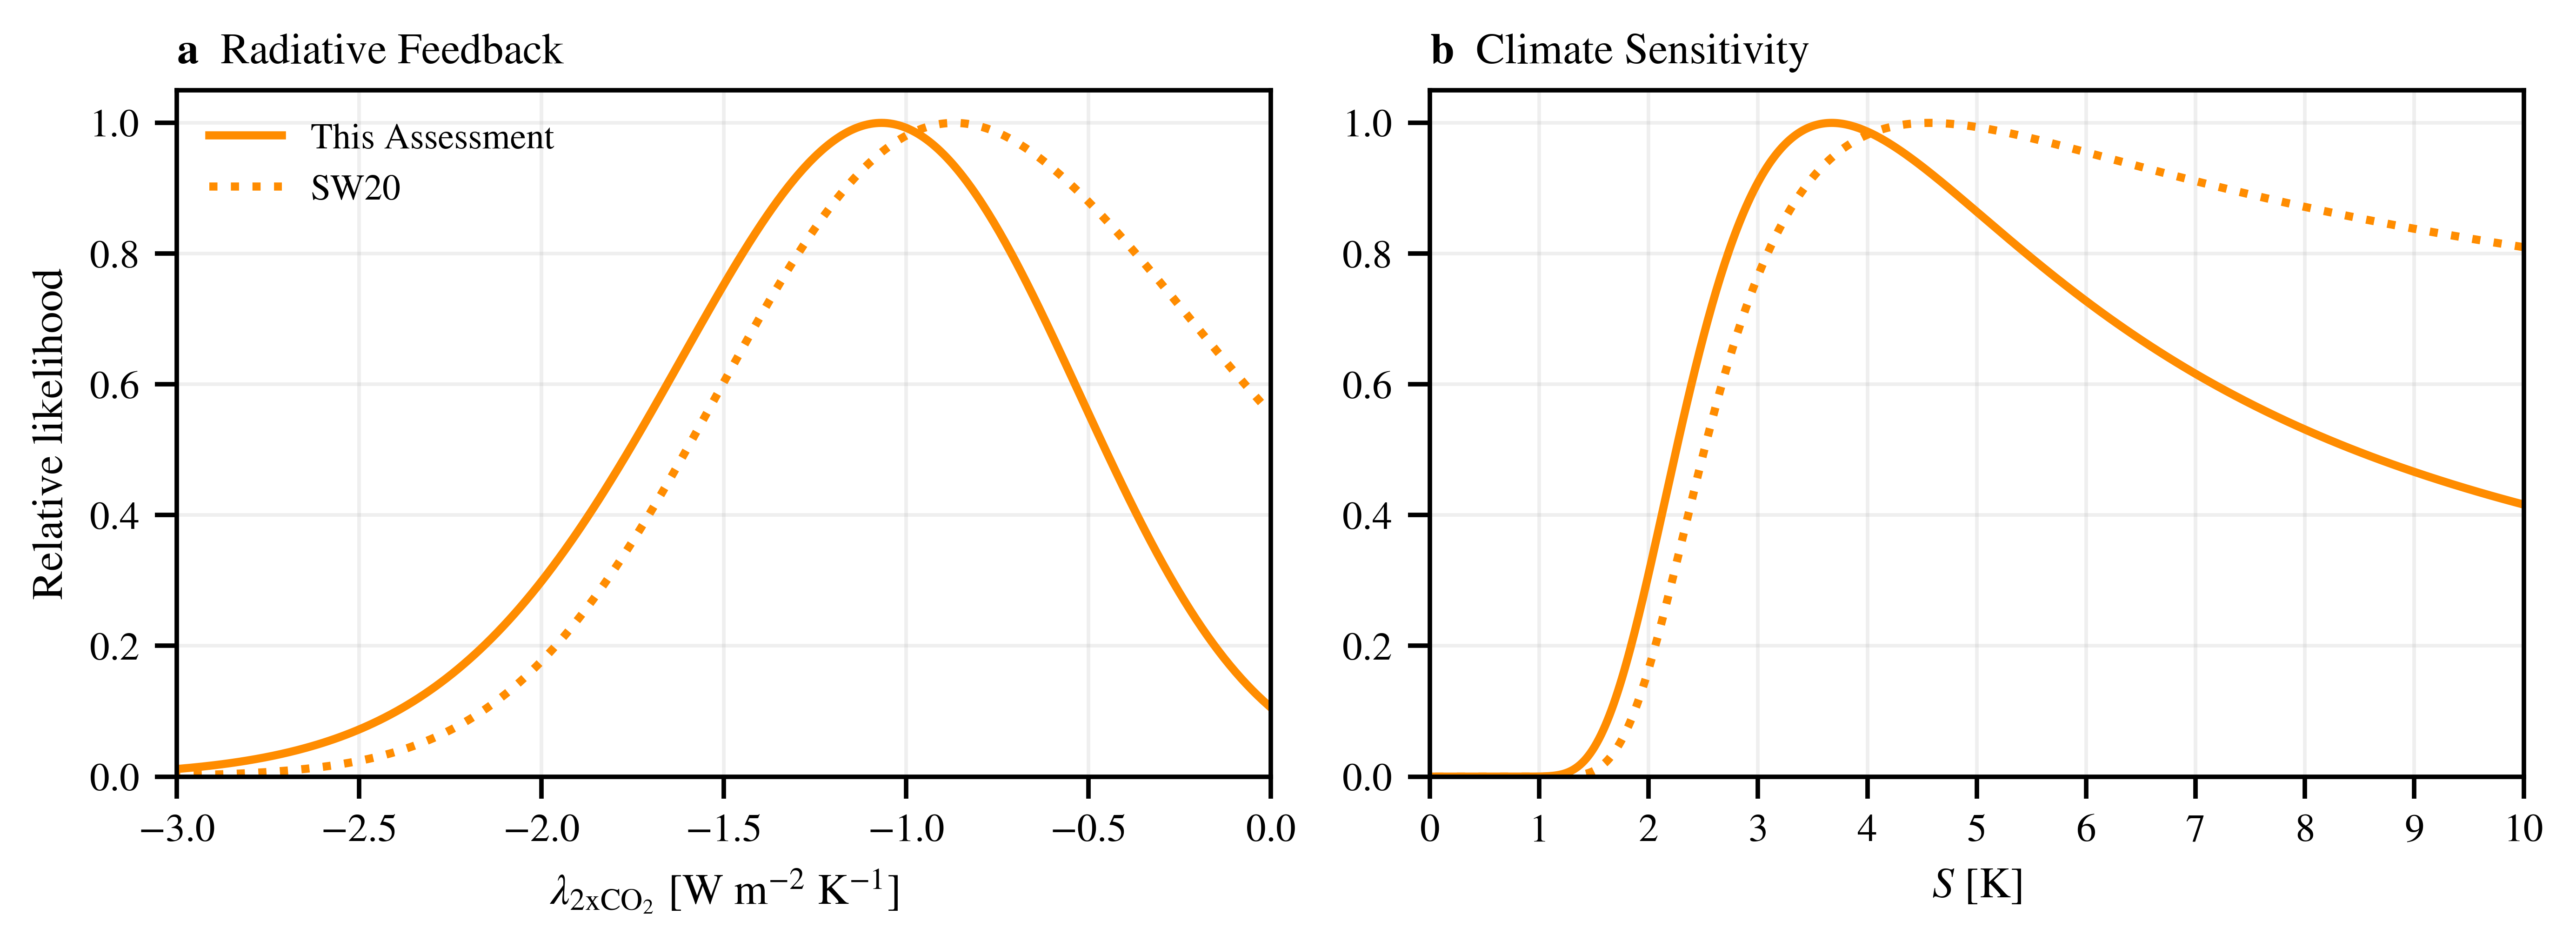

Peak locations
This Assessment: lambda = -1.0673 W m^-2 K^-1; S = 3.673 K
SW20: lambda = -0.8671 W m^-2 K^-1; S = 4.574 K


In [75]:
save_figure = True

## Choose "N" or "T" here to compare the two response-variable methods.
instrumental_score_method = "N"
instrumental_score_method = instrumental_score_method.upper()
if instrumental_score_method not in {"N", "T"}:
    raise ValueError('instrumental_score_method must be "N" or "T"')

this_assessment_instrumental_results = {
    "N": likelihood_result_scoreN,
    "T": likelihood_result_scoreT,
}
plot_likelihood_versions(
    {
        "This Assessment": (
            this_assessment_instrumental_results[instrumental_score_method]
        ),
        "SW20": (
            sw20_instrumental_likelihood_results[instrumental_score_method]
        ),
    },
    evidence="Instrumental",
    title="",
    save=ecs_score_pdf("fig_inst_likely", instrumental_score_method, save_figure),
)
plt.show()

### SW20 LGM likelihood comparison

The compact parameter block below reproduces the SW20 LGM constraint using the distributions in their Table 7 and energy-budget Equation 22. Here $F'_{\mathrm{LGM}}$ contains all LGM forcing except CO$_2$. Score N evaluates the equilibrium budget residual at $N=0$; because $N$ is linear in $F'_{\mathrm{LGM}}$ with unit coefficient, this is equivalent to the forcing-scored likelihood in the original SW20 calculation. Score T instead solves the quadratic energy-budget equation and scores the reconstructed temperature on the cold-climate branch.

In [76]:
## SW20 Table 7 inputs. All uncertainties are 1 sigma.
sw20_lgm_inputs = {
    "erf_2x": 4.0,
    "sig_F2xCO2": 0.3,
    "mu_zeta": 0.06,
    "sig_zeta": 0.20,
    "mu_T_LGM": -5.0,
    "sig_T_LGM": 1.0,
    "mu_F_other_LGM": -6.15,
    "sig_F_other_LGM": 2.0,
    "f_CO2_LGM": -0.57,
    "mu_alpha": 0.10,
    "sig_alpha": 0.10,
}


def calculate_sw20_lgm_likelihood(
    label="SW20", *, score_T=False, input_updates=None,
    settings_updates=None,
):
    """Calculate the SW20 LGM likelihood in lambda and S space."""
    data = dict(sw20_lgm_inputs)
    input_updates = {} if input_updates is None else dict(input_updates)
    unknown_inputs = set(input_updates) - set(data)
    if unknown_inputs:
        raise KeyError(f"Unknown SW20 LGM inputs: {sorted(unknown_inputs)}")
    data.update(input_updates)

    settings = dict(likelihood_defaults)
    settings_updates = {} if settings_updates is None else dict(settings_updates)
    unknown_settings = set(settings_updates) - set(settings)
    if unknown_settings:
        raise KeyError(f"Unknown likelihood settings: {sorted(unknown_settings)}")
    settings.update(settings_updates)

    lambda_grid = np.linspace(
        settings["lambda_min"], settings["lambda_max"],
        int(settings["grid_points"]),
    )
    S_grid = np.linspace(
        settings["S_min"], settings["S_max"],
        int(settings["grid_points"]),
    )
    n = int(settings["mc_draws"])
    rng = np.random.default_rng(settings["seed"])

    ## Reuse common nuisance draws across the grids and both methods.
    F2x = rng.normal(data["erf_2x"], data["sig_F2xCO2"], n)
    zeta = rng.normal(data["mu_zeta"], data["sig_zeta"], n)
    alpha = rng.normal(data["mu_alpha"], data["sig_alpha"], n)
    T_lgm = rng.normal(data["mu_T_LGM"], data["sig_T_LGM"], n)
    F_other_lgm = rng.normal(
        data["mu_F_other_LGM"], data["sig_F_other_LGM"], n
    )

    def evaluate_at_lambda(lamb):
        with np.errstate(divide="ignore", invalid="ignore"):
            feedback_lgm = lamb / (1 + zeta)

            if not score_T:
                ## N = F' + f_CO2*F2x
                ##     + T*(lambda/(1+zeta) + alpha*T/2).
                budget_mean = (
                    data["mu_F_other_LGM"]
                    + data["f_CO2_LGM"] * F2x
                    + T_lgm * (feedback_lgm + 0.5 * alpha * T_lgm)
                )
                density = norm.pdf(
                    0.0, loc=budget_mean, scale=data["sig_F_other_LGM"]
                )
                return np.mean(np.where(np.isfinite(density), density, 0.0))

            ## Solve alpha*T^2/2 + feedback_lgm*T
            ##       + F' + f_CO2*F2x = 0.
            constant = data["f_CO2_LGM"] * F2x + F_other_lgm
            discriminant = feedback_lgm**2 - 2 * alpha * constant
            valid = (
                np.isfinite(discriminant) & (discriminant >= 0)
                & np.isfinite(feedback_lgm)
            )
            sqrt_discriminant = np.sqrt(np.maximum(discriminant, 0.0))

            ## This root is continuous with the linear solution as alpha -> 0.
            root_sign = np.where(feedback_lgm >= 0, 1.0, -1.0)
            denominator = feedback_lgm + root_sign * sqrt_discriminant
            valid &= np.abs(denominator) > 1e-12
            T_pred = np.full(n, np.nan)
            T_pred[valid] = -2 * constant[valid] / denominator[valid]
            valid &= np.isfinite(T_pred) & (T_pred < 0)

            density = np.zeros(n)
            density[valid] = norm.pdf(
                data["mu_T_LGM"], loc=T_pred[valid],
                scale=data["sig_T_LGM"],
            )
            return np.mean(density)

    raw_curves = {
        "LGM": {
            "lambda": np.asarray([
                evaluate_at_lambda(lamb) for lamb in lambda_grid
            ]),
            "S": np.asarray([
                evaluate_at_lambda(-F2x / S) for S in S_grid
            ]),
        }
    }
    curves = {
        "LGM": {
            axis: _relative_likelihood(values)
            for axis, values in raw_curves["LGM"].items()
        }
    }
    return {
        "label": label, "data": data, "settings": settings,
        "score_T": bool(score_T),
        "lambda_grid": lambda_grid, "S_grid": S_grid,
        "curves": curves, "raw_curves": raw_curves,
    }


sw20_lgm_likelihood_results = {
    "N": calculate_sw20_lgm_likelihood("SW20, Score N", score_T=False),
    "T": calculate_sw20_lgm_likelihood("SW20, Score T", score_T=True),
}


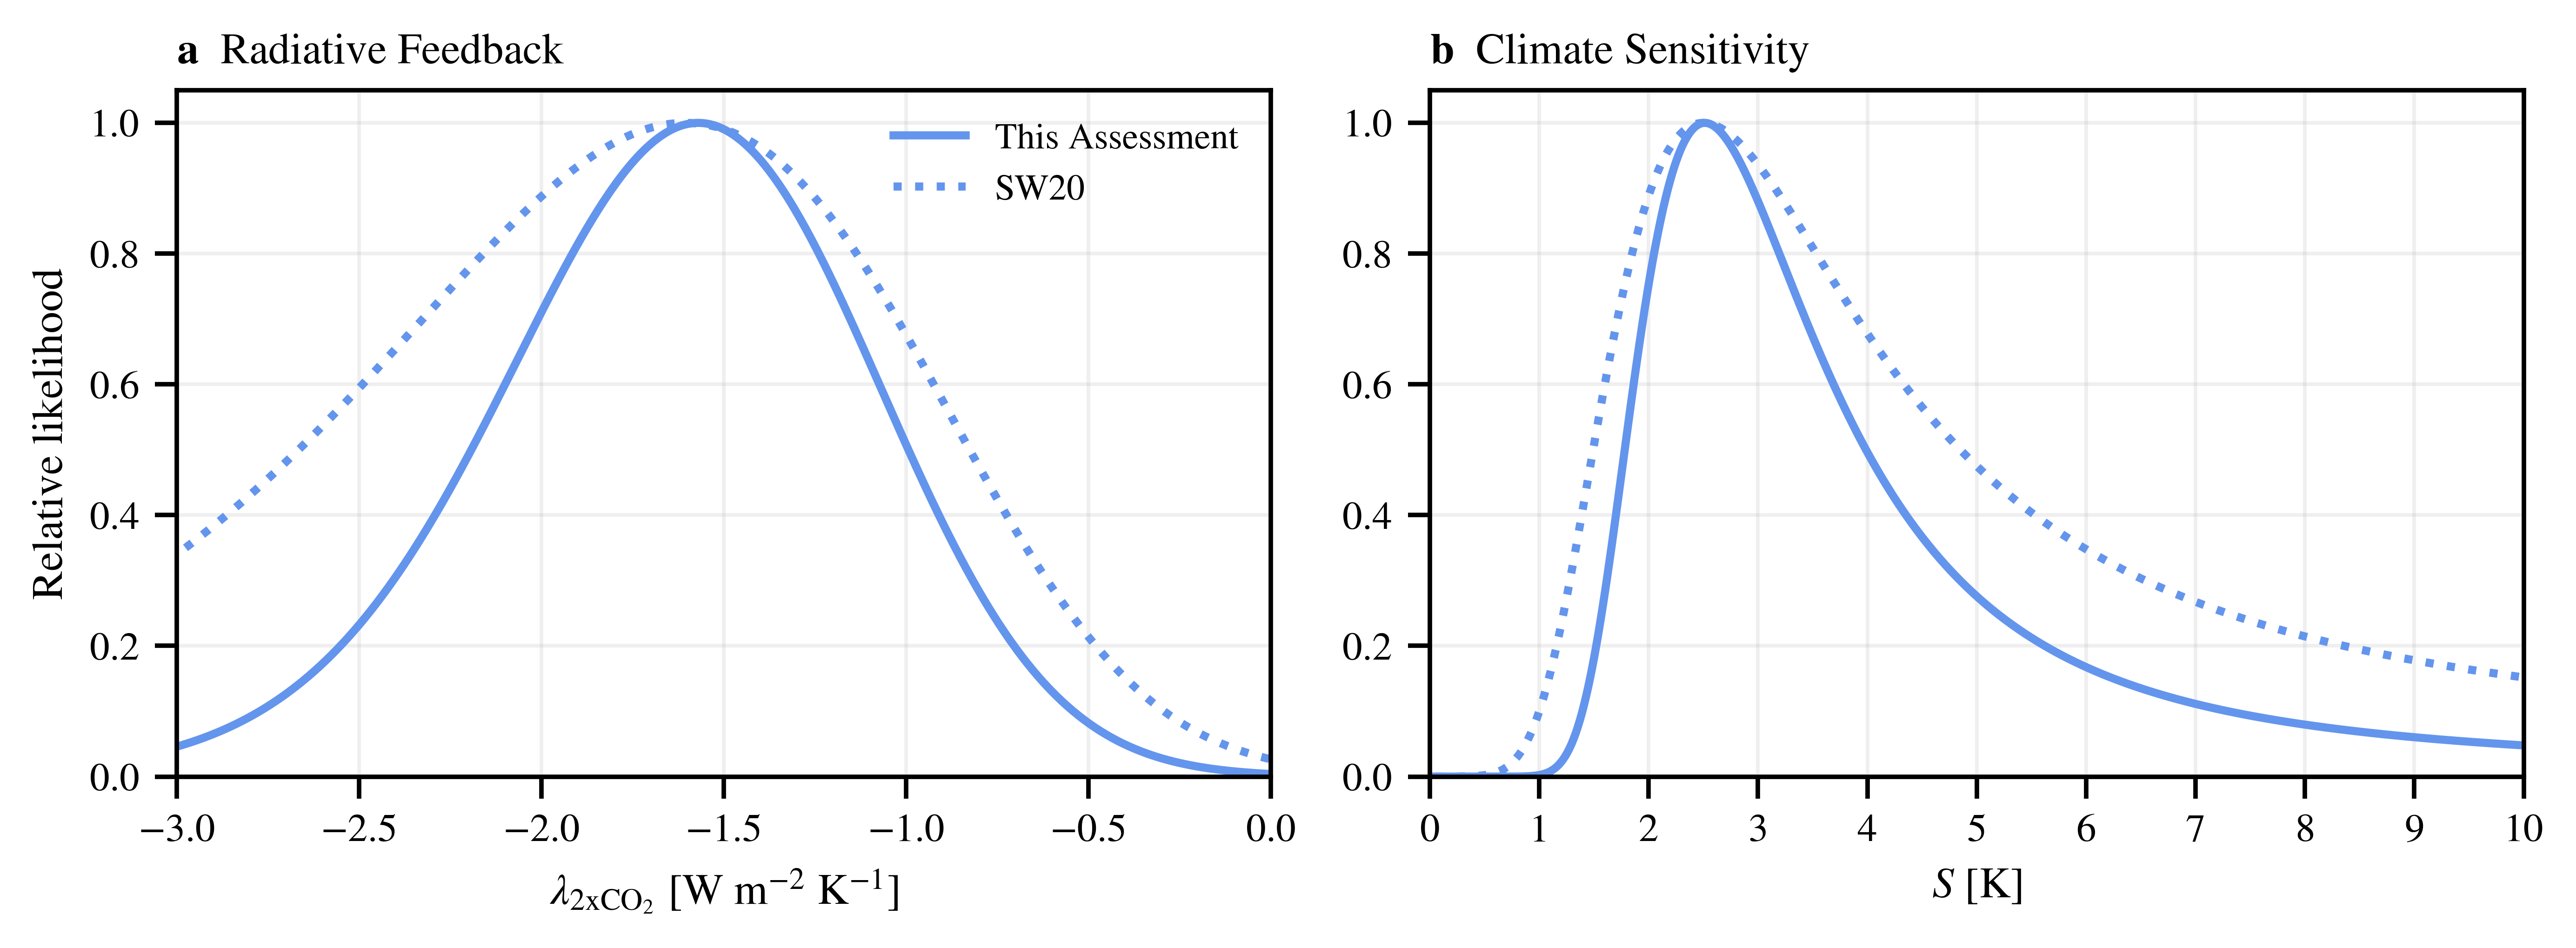

Peak locations
This Assessment: lambda = -1.5676 W m^-2 K^-1; S = 2.504 K
SW20: lambda = -1.6061 W m^-2 K^-1; S = 2.504 K


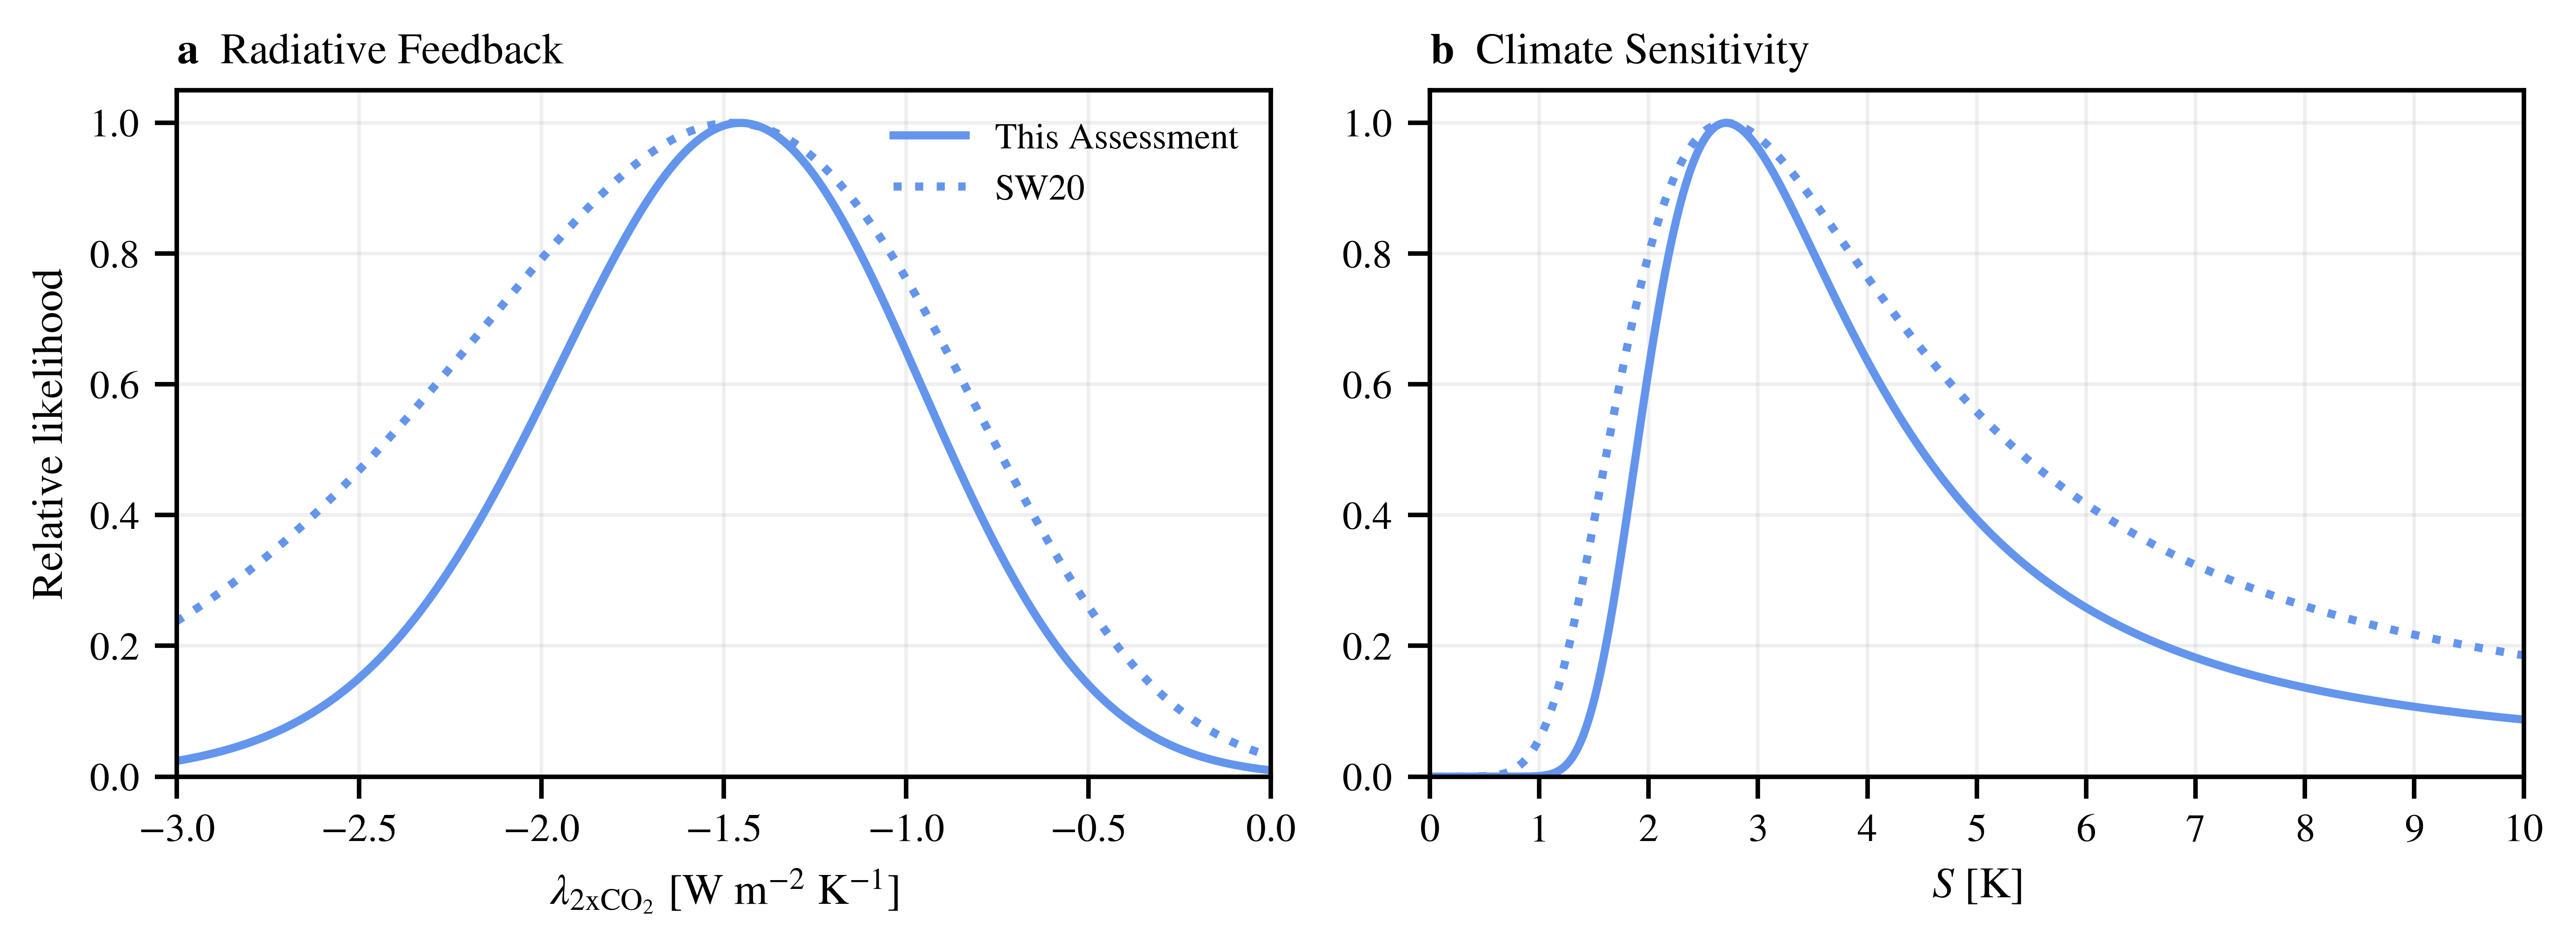

Peak locations
This Assessment: lambda = -1.4521 W m^-2 K^-1; S = 2.715 K
SW20: lambda = -1.4752 W m^-2 K^-1; S = 2.715 K


In [77]:
save_figure = True

## Choose "N" or "T" here to compare the two response-variable methods.
lgm_score_method = "T"
lgm_score_method = lgm_score_method.upper()
if lgm_score_method not in {"N", "T"}:
    raise ValueError('lgm_score_method must be "N" or "T"')

this_assessment_lgm_results = {
    "N": likelihood_result_scoreN,
    "T": likelihood_result_scoreT,
}
plot_likelihood_versions(
    {
        "This Assessment": this_assessment_lgm_results[lgm_score_method],
        "SW20": sw20_lgm_likelihood_results[lgm_score_method],
    },
    evidence="LGM",
    title="",
    save=ecs_score_pdf("fig_lgm_likely", lgm_score_method, save_figure),
)
plt.show()

## Choose "N" or "T" here to compare the two response-variable methods.
lgm_score_method = "N"
lgm_score_method = lgm_score_method.upper()
if lgm_score_method not in {"N", "T"}:
    raise ValueError('lgm_score_method must be "N" or "T"')

this_assessment_lgm_results = {
    "N": likelihood_result_scoreN,
    "T": likelihood_result_scoreT,
}
plot_likelihood_versions(
    {
        "This Assessment": this_assessment_lgm_results[lgm_score_method],
        "SW20": sw20_lgm_likelihood_results[lgm_score_method],
    },
    evidence="LGM",
    title="",
    save=ecs_score_pdf("fig_lgm_likely", lgm_score_method, save_figure),
)
plt.show()

### SW20 Pliocene likelihood comparison

This uses the distributions in SW20 Table 8 and their Pliocene energy-budget Equation 23. Score T is the original SW20 response-variable convention. Score N evaluates the equivalent equilibrium budget at $N=0$; with no separate Pliocene imbalance uncertainty in SW20, its conditional spread comes from the assessed uncertainty in $T_{\mathrm{plio}}$.

In [78]:
## SW20 Table 8 inputs. All uncertainties are 1 sigma.
sw20_pliocene_inputs = {
    "erf_2x": 4.0,
    "sig_F2xCO2": 0.3,
    "mu_zeta": 0.06,
    "sig_zeta": 0.20,
    "mu_T_plio": 3.0,
    "sig_T_plio": 1.0,
    "mu_CO2_plio": 375.0,
    "sig_CO2_plio": 25.0,
    "co2_pi": 284.0,
    "mu_fCH4": 0.40,
    "sig_fCH4": 0.10,
    "mu_fESS": 0.50,
    "sig_fESS": 0.25,
}


def calculate_sw20_pliocene_likelihood(
    label="SW20", *, score_T=False, input_updates=None,
    settings_updates=None,
):
    """Calculate the SW20 Pliocene likelihood in lambda and S space."""
    data = dict(sw20_pliocene_inputs)
    input_updates = {} if input_updates is None else dict(input_updates)
    unknown_inputs = set(input_updates) - set(data)
    if unknown_inputs:
        raise KeyError(
            f"Unknown SW20 Pliocene inputs: {sorted(unknown_inputs)}"
        )
    data.update(input_updates)

    settings = dict(likelihood_defaults)
    settings_updates = {} if settings_updates is None else dict(settings_updates)
    unknown_settings = set(settings_updates) - set(settings)
    if unknown_settings:
        raise KeyError(f"Unknown likelihood settings: {sorted(unknown_settings)}")
    settings.update(settings_updates)

    lambda_grid = np.linspace(
        settings["lambda_min"], settings["lambda_max"],
        int(settings["grid_points"]),
    )
    S_grid = np.linspace(
        settings["S_min"], settings["S_max"],
        int(settings["grid_points"]),
    )
    n = int(settings["mc_draws"])
    rng = np.random.default_rng(settings["seed"])

    ## Common draws preserve the shared F2x dependence in S space.
    F2x = rng.normal(data["erf_2x"], data["sig_F2xCO2"], n)
    zeta = rng.normal(data["mu_zeta"], data["sig_zeta"], n)
    CO2_plio = rng.normal(data["mu_CO2_plio"], data["sig_CO2_plio"], n)
    fCH4 = rng.normal(data["mu_fCH4"], data["sig_fCH4"], n)
    fESS = rng.normal(data["mu_fESS"], data["sig_fESS"], n)

    def evaluate_at_lambda(lamb):
        with np.errstate(divide="ignore", invalid="ignore"):
            feedback_plio = lamb / (1 + zeta)
            F_plio_co2 = (
                np.log(CO2_plio / data["co2_pi"]) / np.log(2) * F2x
            )
            F_plio = F_plio_co2 * (1 + fCH4) * (1 + fESS)
            budget_mean = (
                F_plio + feedback_plio * data["mu_T_plio"]
            )
            budget_variance = (
                feedback_plio**2 * data["sig_T_plio"]**2
            )
            density = _normal_density_from_variance(
                0.0, budget_mean, budget_variance
            )
            if score_T:
                ## Equivalent to scoring T_plio against -F_plio/feedback_plio.
                density = np.abs(feedback_plio) * density

            valid = (
                (CO2_plio > 0) & np.isfinite(feedback_plio)
                & np.isfinite(density)
            )
            return np.mean(np.where(valid, density, 0.0))

    raw_curves = {
        "Pliocene": {
            "lambda": np.asarray([
                evaluate_at_lambda(lamb) for lamb in lambda_grid
            ]),
            "S": np.asarray([
                evaluate_at_lambda(-F2x / S) for S in S_grid
            ]),
        }
    }
    curves = {
        "Pliocene": {
            axis: _relative_likelihood(values)
            for axis, values in raw_curves["Pliocene"].items()
        }
    }
    return {
        "label": label, "data": data, "settings": settings,
        "score_T": bool(score_T),
        "lambda_grid": lambda_grid, "S_grid": S_grid,
        "curves": curves, "raw_curves": raw_curves,
    }


sw20_pliocene_likelihood_results = {
    "N": calculate_sw20_pliocene_likelihood(
        "SW20, Score N", score_T=False
    ),
    "T": calculate_sw20_pliocene_likelihood(
        "SW20, Score T", score_T=True
    ),
}


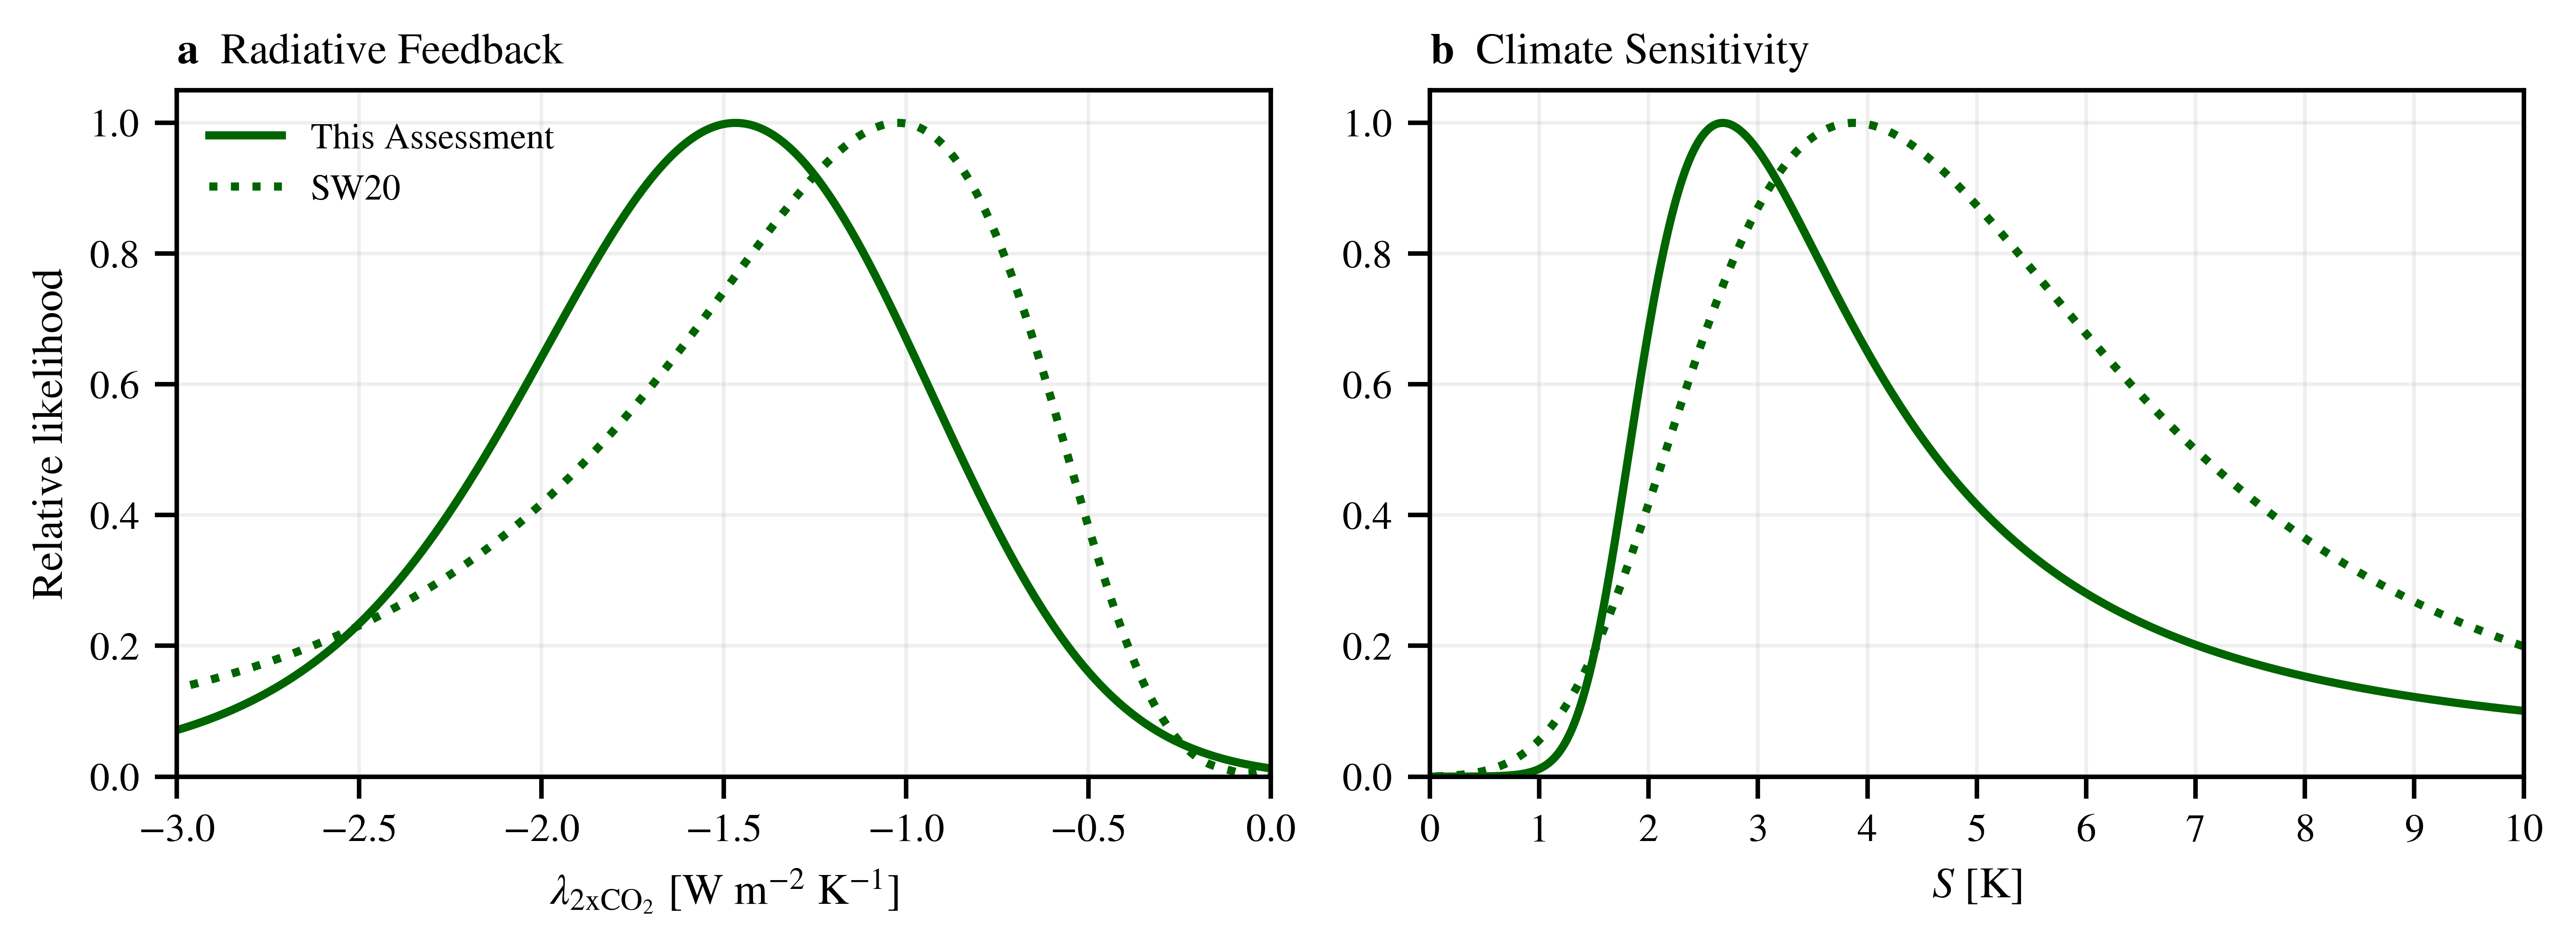

Peak locations
This Assessment: lambda = -1.4675 W m^-2 K^-1; S = 2.676 K
SW20: lambda = -1.0211 W m^-2 K^-1; S = 3.884 K


In [79]:
save_figure = True

## Choose "N" or "T" here to compare the two response-variable methods.
pliocene_score_method = "N"
pliocene_score_method = pliocene_score_method.upper()
if pliocene_score_method not in {"N", "T"}:
    raise ValueError('pliocene_score_method must be "N" or "T"')

this_assessment_pliocene_results = {
    "N": likelihood_result_scoreN,
    "T": likelihood_result_scoreT,
}
plot_likelihood_versions(
    {
        "This Assessment": (
            this_assessment_pliocene_results[pliocene_score_method]
        ),
        "SW20": sw20_pliocene_likelihood_results[pliocene_score_method],
    },
    evidence="Pliocene",
    title="",
    save=ecs_score_pdf("fig_plio_likely", pliocene_score_method, save_figure),
)
plt.show()

### Sensitivity versions

Add named calculations to `likelihood_results`, changing only the parameters of interest. Because every version uses the same default seed, unchanged nuisance draws use common random numbers and differences between curves remain visually clean.

In [33]:
## SCRATCH WORK
# how does the optional lambda/F2x Process correlation change
# the process likelihood in S space. Its lambda marginal is unchanged.
# likelihood_results["Process rho=-0.5"] = calculate_likelihoods(
#     "Process rho=-0.5", process_correlation=True
# )
# plot_likelihood_versions(
#     {
#         "independent": likelihood_results["baseline"],
#         r"$\rho=-0.5$": likelihood_results["Process rho=-0.5"],
#     },
#     evidence="Process",
# )

# Example: alternative LGM state-dependence multiplier uncertainty.
# likelihood_results["LGM multiplier sigma=0.08"] = calculate_likelihoods(
#     "LGM multiplier sigma=0.08",
#     input_updates={"sig_f_CO2_LGM": 0.08},
# )
# plot_likelihood_versions(
#     {
#         "baseline": likelihood_results["baseline"],
#         r"$\sigma(f_{CO2,LGM})=0.08$": likelihood_results["LGM multiplier sigma=0.08"],
#     },
#     evidence="LGM",
# )

# Example: compare the global score-N and score-T likelihood conventions.
# likelihood_results["score T"] = calculate_likelihoods(
#     "score T", score_T=True
# )
# plot_likelihood_versions(
#     {"score N": likelihood_results["baseline"],
#      "score T": likelihood_results["score T"]},
#     evidence="Instrumental",
# )

# For a higher-resolution final figure:
# final_settings = {"grid_points": 600, "mc_draws": 150_000}
# likelihood_results["final"] = calculate_likelihoods(
#     "final", settings_updates=final_settings
# )

# Prior scratch

In [140]:
import numpy as np
from scipy.stats import norm, lognorm

def get_lognorm_params(p5, p95):
    """Calculates s (sigma) and scale (median) for scipy.stats.lognorm."""
    z95 = norm.ppf(0.95)  # ~1.64485
    s = (np.log(p95) - np.log(p5)) / (2 * z95)
    scale = np.sqrt(p5 * p95)  # Equivalent to exp((ln(p5) + ln(p95)) / 2)
    return s, scale

# Example usage with your script:
p5, p95 = .262, 15.7
print(erf_2x/p5, erf_2x/p95)
lognormal_r_log_sigma, lognormal_r_median = get_lognorm_params(p5, p95)

# Verify parameters with scipy
dist = lognorm(s=lognormal_r_log_sigma, scale=lognormal_r_median)
print(f"5th percentile:  {dist.ppf(0.05):.2f}")  # 1.00
print(f"95th percentile: {dist.ppf(0.95):.2f}")  # 10.00

print('lognormal_r_median', lognormal_r_median)
print('lognormal_r_log_sigma', lognormal_r_log_sigma)

15.0 0.2503184713375796
5th percentile:  0.26
95th percentile: 15.70
lognormal_r_median 2.028151868080889
lognormal_r_log_sigma 1.2442053871873364


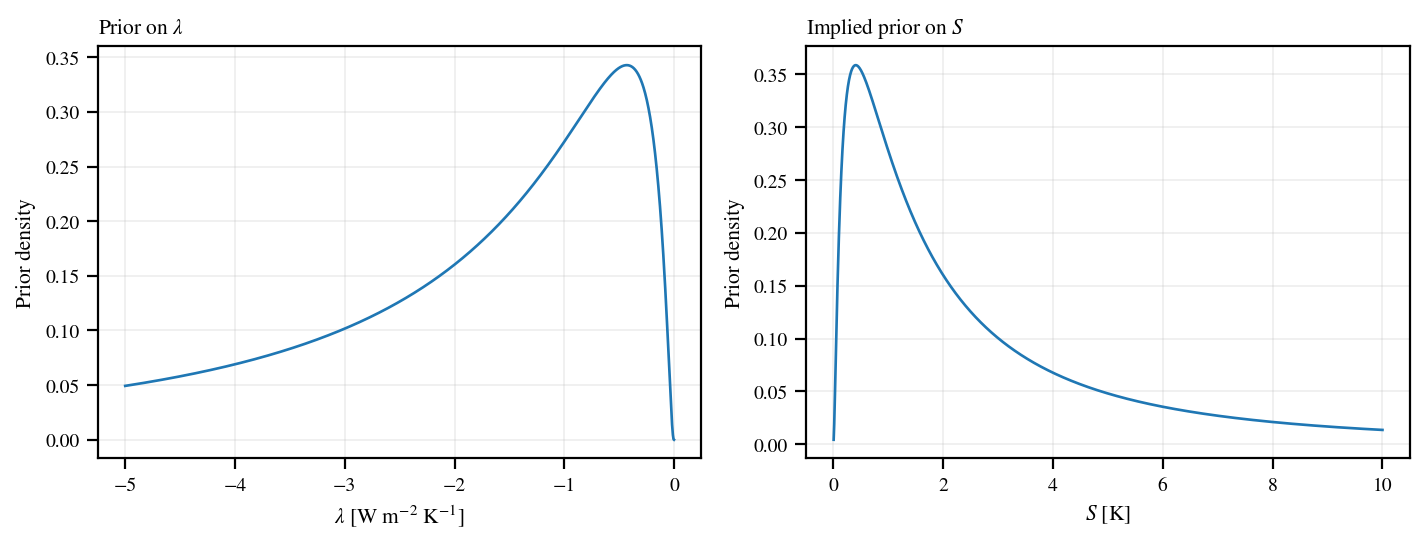

In [141]:
save_figure = False

# lognormal_r_median = np.exp(1.0)       # 22.65
# lognormal_r_log_sigma = np.sqrt(1)

# lognormal_r_median = np.exp(3.0)       
# lognormal_r_log_sigma = np.sqrt(3.)

# lognormal_r_median = np.exp(0)      
# lognormal_r_log_sigma = np.sqrt(2.500)
erf_2x = 3.93  # fixed here for the S transformation

lamb = np.linspace(-5, -0.001, 2000)
S = np.linspace(.01, 10, 2000)

# Prior on r = -lambda
pdf_lamb = lognorm.pdf(
    -lamb,
    s=lognormal_r_log_sigma,
    scale=lognormal_r_median,
)

# S = erf_2x / r
pdf_S = lognorm.pdf(
    S,
    s=lognormal_r_log_sigma,
    scale=erf_2x / lognormal_r_median,
)

fig, axs = plt.subplots(1, 2, figsize=(9, 3.5), dpi=figure_dpi(save_figure))

axs[0].plot(lamb, pdf_lamb)
axs[0].set(xlabel=r"$\lambda$ [W m$^{-2}$ K$^{-1}$]",
           ylabel="Prior density")
axs[0].set_title(r"Prior on $\lambda$", loc="left")

axs[1].plot(S, pdf_S)
axs[1].set(xlabel=r"$S$ [K]",
           ylabel="Prior density")
axs[1].set_title(r"Implied prior on $S$", loc="left")

for ax in axs:
    ax.grid(alpha=0.2)

maybe_despine(fig)
plt.tight_layout()
save_path = ecs_pdf_path("fig_lognormal_prior_scratch.pdf", save_figure)
if save_path is not None:
    fig.savefig(save_path, bbox_inches="tight", dpi=save_dpi)
    print(f"saved {save_path}")
plt.show()

### Prior choices and Process-only posteriors

This demonstration fixes $F_{2\times\mathrm{CO_2}}$ at its assessed mean and uses the fixed $-100\leq\lambda\leq-0.01$ support in the Stan model. The first row shows normalized prior PDFs for uniform $\lambda$, uniform $S$, and the reflected-lognormal $|\lambda|$ prior. The second row multiplies each prior by the total Process-feedback likelihood and renormalizes it. The $S$ densities include the $F_{2\times\mathrm{CO_2}}/S^2$ transformation Jacobian. The axes are zoomed for legibility, but all curves are normalized over the full Stan support. Parameters are read from `base_inputs`, which retains the values sent to Stan even if the scratch examples above change their names.

saved /glade/u/home/vcooper/work/hist_sst/bayecs/figures/ecs/fig_prior_process_comparison.pdf


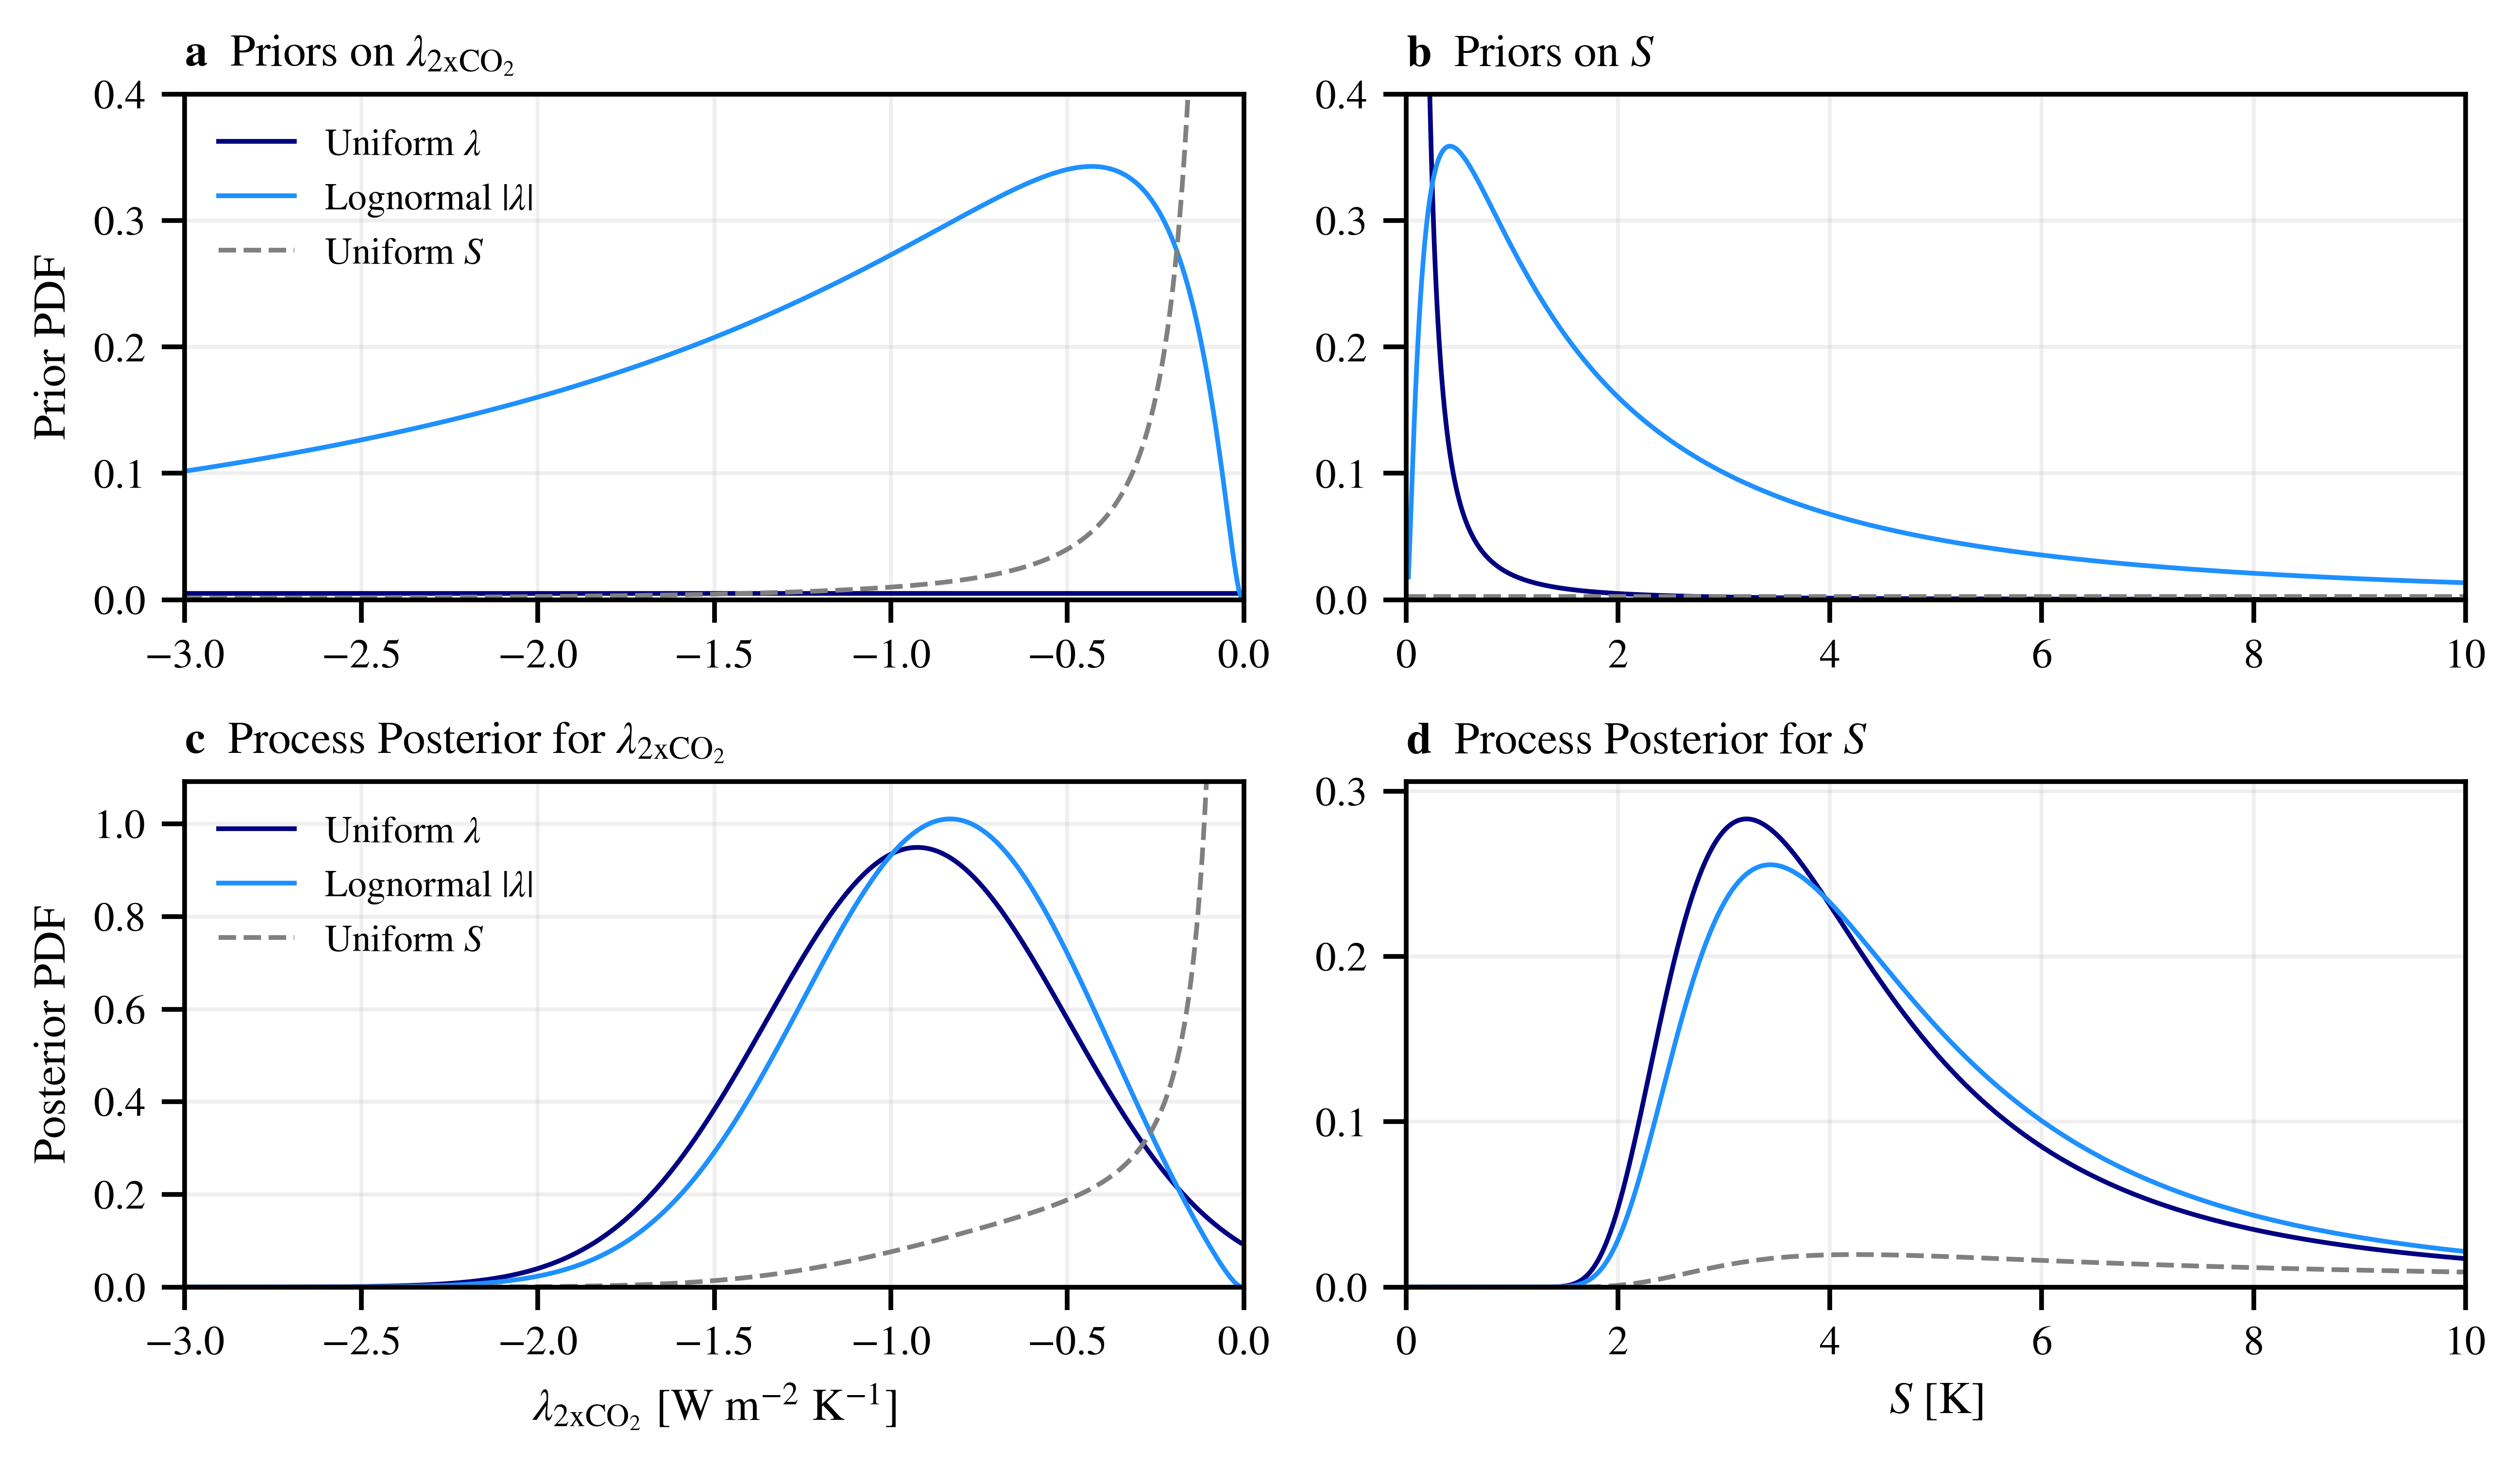

In [157]:
save_figure = False

from scipy.stats import norm, lognorm

## Use the inputs captured for Stan, not the scratch variables reassigned above.
prior_demo_data = base_inputs
prior_demo_F2x = prior_demo_data["erf_2x"]  # fixed for this demonstration
prior_demo_lambda_min, prior_demo_lambda_max = -200.0, -0.01
prior_demo_S_min = -prior_demo_F2x / prior_demo_lambda_min
prior_demo_S_max = -prior_demo_F2x / prior_demo_lambda_max

## Normalize every prior over the full fixed-lambda support.
prior_demo_lambda_width = prior_demo_lambda_max - prior_demo_lambda_min
prior_demo_S_width = prior_demo_S_max - prior_demo_S_min
prior_demo_lognormal = lognorm(
    s=prior_demo_data["lognormal_r_log_sigma"],
    scale=prior_demo_data["lognormal_r_median"],
)
prior_demo_lognormal_mass = (
    prior_demo_lognormal.cdf(-prior_demo_lambda_min)
    - prior_demo_lognormal.cdf(-prior_demo_lambda_max)
)
prior_demo_names = (
    r"Uniform $\lambda$", r"Lognormal $\left| \lambda \right|$", r"Uniform $S$",
)
prior_demo_colors = {
    prior_demo_names[0]: "navy",
    prior_demo_names[1]: "dodgerblue",
    prior_demo_names[2]: "gray",
}
prior_demo_ls = {
    prior_demo_names[0]: "-",
    prior_demo_names[1]: "-",
    prior_demo_names[2]: "--",
}

def prior_demo_pdf_lambda(lamb_values):
    return {
        prior_demo_names[0]: np.full_like(
            lamb_values, 1 / prior_demo_lambda_width, dtype=float
        ),
        prior_demo_names[1]: (
            prior_demo_lognormal.pdf(-lamb_values)
            / prior_demo_lognormal_mass
        ),
        prior_demo_names[2]: (
            prior_demo_F2x / (prior_demo_S_width * lamb_values**2)
        ),
    }

prior_demo_lambda_grid = -np.geomspace(
    -prior_demo_lambda_min, -prior_demo_lambda_max, 30_000
)
prior_demo_S_grid = np.geomspace(
    prior_demo_S_min, prior_demo_S_max, 30_000
)
prior_demo_lambda_at_S = -prior_demo_F2x / prior_demo_S_grid
prior_demo_lambda_prior = prior_demo_pdf_lambda(prior_demo_lambda_grid)
prior_demo_S_prior = {
    name: pdf * prior_demo_F2x / prior_demo_S_grid**2
    for name, pdf in prior_demo_pdf_lambda(prior_demo_lambda_at_S).items()
}

## Combine each prior with the same Gaussian total Process likelihood.
prior_demo_process_lambda = norm.pdf(
    prior_demo_lambda_grid,
    prior_demo_data["mu_lambda"], prior_demo_data["sig_lambda"],
)
prior_demo_process_at_S = norm.pdf(
    prior_demo_lambda_at_S,
    prior_demo_data["mu_lambda"], prior_demo_data["sig_lambda"],
)
prior_demo_evidence = {
    name: np.trapz(pdf * prior_demo_process_lambda, prior_demo_lambda_grid)
    for name, pdf in prior_demo_lambda_prior.items()
}
prior_demo_lambda_posterior = {
    name: pdf * prior_demo_process_lambda / prior_demo_evidence[name]
    for name, pdf in prior_demo_lambda_prior.items()
}
prior_demo_S_posterior = {
    name: pdf * prior_demo_process_at_S / prior_demo_evidence[name]
    for name, pdf in prior_demo_S_prior.items()
}

## Both columns zoom to the same S-equivalent range for legibility.
prior_demo_S_xlim = (0.01, 10.0)
prior_demo_lambda_xlim = (
    -prior_demo_F2x / prior_demo_S_xlim[0],
    -prior_demo_F2x / prior_demo_S_xlim[1],
)
prior_demo_rows = (
    (prior_demo_lambda_prior, prior_demo_S_prior, "Prior PDF"),
    (prior_demo_lambda_posterior, prior_demo_S_posterior,
     "Posterior PDF"),
)
prior_demo_titles = (
    (r"$\mathbf{a}$  Priors on $\lambda_\mathrm{2xCO_2}$",
     r"$\mathbf{b}$  Priors on $S$"),
    (r"$\mathbf{c}$  Process Posterior for $\lambda_\mathrm{2xCO_2}$",
     r"$\mathbf{d}$  Process Posterior for $S$"),
)
fig_prior_demo, axs_prior_demo = plt.subplots(
    2, 2, figsize=(7.5, 4.4), dpi=figure_dpi(save_figure)
)
for row, (lambda_curves, S_curves, ylabel) in enumerate(prior_demo_rows):
    for column, (grid, curves, xlim, xlabel) in enumerate((
        (prior_demo_lambda_grid, lambda_curves, prior_demo_lambda_xlim,
         r"$\lambda_\mathrm{2xCO_2}$ [W m$^{-2}$ K$^{-1}$]"),
        (prior_demo_S_grid, S_curves, prior_demo_S_xlim, r"$S$ [K]"),
    )):
        ax = axs_prior_demo[row, column]
        visible = (grid >= xlim[0]) & (grid <= xlim[1])
        for name in prior_demo_names:
            ax.plot(grid, curves[name], color=prior_demo_colors[name],
                    ls=prior_demo_ls[name],
                    lw=1.0, label=name)
        ax.set(
            xlabel=xlabel,
            ylabel=ylabel, xlim=xlim,
            ylim=(0, 1.08 * max(np.max(curves[name][visible])
                                for name in prior_demo_names)),
        )
        ax.set_title(prior_demo_titles[row][column], loc="left")
        ax.grid(alpha=0.2)
    axs_prior_demo[row, 0].legend(frameon=False, fontsize="small")

axs_prior_demo[0,0].set_xlabel("")
axs_prior_demo[0,1].set_xlabel("")
axs_prior_demo[0,1].set_ylabel("")
axs_prior_demo[1,1].set_ylabel("")


axs_prior_demo[0,0].set_xlim(-3,0)
axs_prior_demo[1,0].set_xlim(-3,0)
axs_prior_demo[0,1].set_xlim(0,10)
axs_prior_demo[1,1].set_xlim(0,10)

axs_prior_demo[0,0].set_ylim(0,0.4)
axs_prior_demo[0,1].set_ylim(0,0.4)
maybe_despine(fig_prior_demo)
fig_prior_demo.tight_layout(h_pad=1.0, w_pad=1.0)
save_path = ecs_pdf_path("fig_prior_process_comparison.pdf", save_figure)
if save_path is not None:
    fig_prior_demo.savefig(save_path, bbox_inches="tight", dpi=save_dpi)
    print(f"saved {save_path}")
plt.show()

## Process-feedback component assessment

The blue points are constructed directly from the process-feedback inputs at the top of the notebook, so changing those inputs and rerunning this cell updates the figure. The Planck feedback is plotted after adding 2 W m$^{-2}$ K$^{-1}$, as indicated on its axis label. Thick and thin intervals show central 66% and 90% Gaussian ranges.


saved /glade/u/home/vcooper/work/hist_sst/bayecs/figures/ecs/fig_process_components.pdf


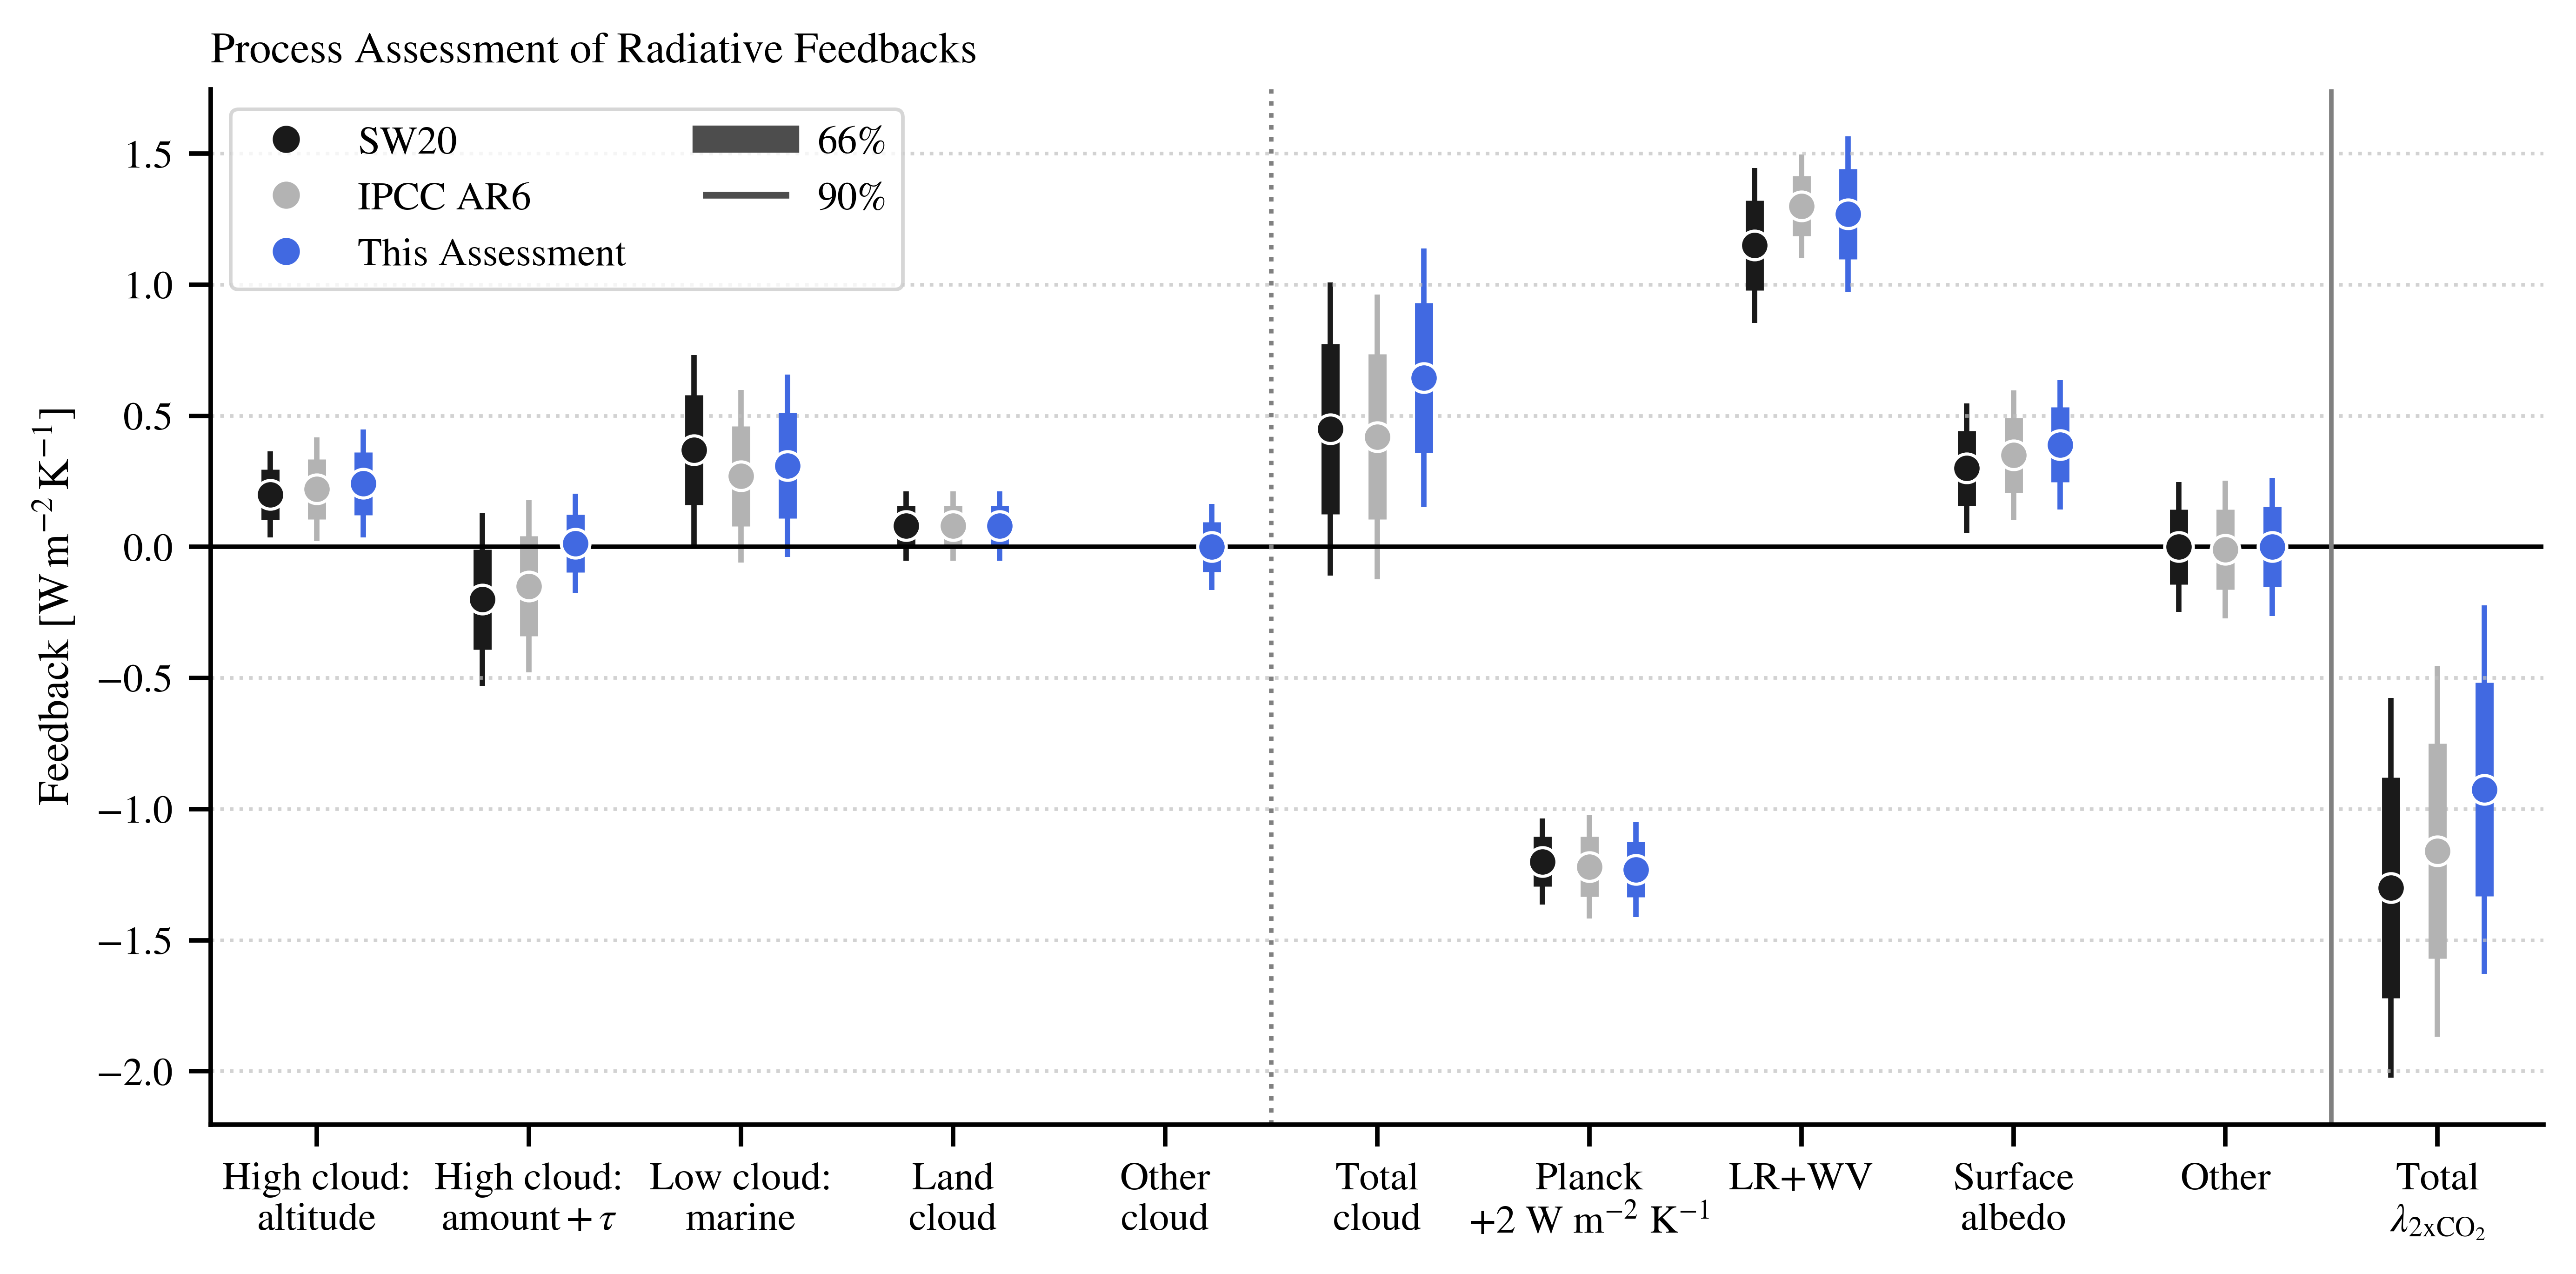

In [37]:
save_figure = True

from matplotlib import ticker
from matplotlib.lines import Line2D

## Feedback order follows the current assessment table.
process_feedbacks = [
    "High cloud:\naltitude",
    "High cloud:\n" + r"$\mathrm{amount} + \tau$",
    "Low cloud:\nmarine",
    "Land\ncloud",
    "Other\ncloud",
    "Total\ncloud",
    "Planck\n" + r"$+2$ W m$^{-2}$ K$^{-1}$",
    "LR+WV",
    "Surface\nalbedo",
    "Other",
    "Total\n" + r"$\lambda_\mathrm{2xCO_2}$",
]

process_assessments = {
    "SW20": {
        "mean": [0.20, -0.20, 0.37, 0.08, np.nan, 0.45,
                 2 - 3.20, 1.15, 0.30, 0.00, -1.30],
        "sigma": [0.10, 0.20, 0.22, 0.08, np.nan, 0.34,
                  0.10, 0.18, 0.15, 0.15, 0.44],
        "color": "0.1",
    },
    "IPCC AR6": {
        "mean": [0.22, -0.15, 0.27, 0.08, np.nan, 0.42,
                 2 - 3.22, 1.30, 0.35, -0.01, -1.16],
        "sigma": [0.12, 0.20, 0.20, 0.08, np.nan, 0.33,
                  0.12, 0.12, 0.15, 0.16, 0.43],
        "color": "0.7",
    },
    "This Assessment": {
        ## These values all refer back to the assessed inputs above.
        "mean": [
            highcloud_alt_mu,
            highcloud_amt_optdepth_mu,
            marine_lowcloud_mu,
            landcloud_mu,
            unassessed_cloud_mu,
            cloud_total_mu,
            2 + planck_mu,
            LRWV_mu,
            surfalbedo_mu,
            unassessed_mu,
            process_lamb_mu,
        ],
        "sigma": [
            highcloud_alt_sig,
            highcloud_amt_optdepth_sig,
            marine_lowcloud_sig,
            landcloud_sig,
            unassessed_cloud_sig,
            cloud_total_sig,
            planck_sig,
            LRWV_sig,
            surfalbedo_sig,
            unassessed_sig,
            process_lamb_sig,
        ],
        "color": "royalblue",
    },
}

z66 = 0.954
z90 = 1.645
x = np.arange(len(process_feedbacks))
offsets = [-0.22, 0.0, 0.22]

fig, ax = plt.subplots(figsize=(8., 4), dpi=figure_dpi(save_figure))

for offset, (name, values) in zip(offsets, process_assessments.items()):
    mean = np.asarray(values["mean"], dtype=float)
    sigma = np.asarray(values["sigma"], dtype=float)
    xpos = x + offset
    mask = np.isfinite(mean) & np.isfinite(sigma)

    ax.vlines(
        xpos[mask], mean[mask] - z90 * sigma[mask],
        mean[mask] + z90 * sigma[mask],
        color=values["color"], linewidth=1.2, zorder=1,
    )
    ax.vlines(
        xpos[mask], mean[mask] - z66 * sigma[mask],
        mean[mask] + z66 * sigma[mask],
        color=values["color"], linewidth=4, zorder=2,
    )
    ax.scatter(
        xpos[mask], mean[mask], color=values["color"], edgecolor="white",
        linewidth=0.7, s=40, zorder=3,
    )

ax.axhline(0, color="black", linewidth=1)
ax.axvline(4.5, color="0.5", linestyle=":", linewidth=1)
ax.axvline(9.5, color="0.5", linewidth=1)
ax.set_xlim(-0.5, len(process_feedbacks) - 0.5)
ax.yaxis.set_major_locator(ticker.MultipleLocator(0.5))
ax.grid(axis="y", linestyle=":", color="0.75", alpha=0.7)
ax.set_xticks(x)
ax.set_xticklabels(process_feedbacks)
ax.set_ylabel(r"Feedback $[\mathrm{W\,m^{-2}\,K^{-1}}]$")
ax.set_title("Process Assessment of Radiative Feedbacks", loc="left")

legend_items = [
    Line2D(
        [0], [0], marker="o", linestyle="none", color=values["color"],
        markersize=5, label=name,
    )
    for name, values in process_assessments.items()
] + [
    Line2D([0], [0], color="0.3", linewidth=6, label="66%"),
    Line2D([0], [0], color="0.3", linewidth=1.5, label="90%"),
]
ax.legend(handles=legend_items, ncol=2, frameon=True, loc="upper left")
for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)
fig.tight_layout()
save_path = ecs_pdf_path("fig_process_components.pdf", save_figure)
if save_path is not None:
    fig.savefig(save_path, bbox_inches="tight", dpi=save_dpi)
    print(f"saved {save_path}")
plt.show()


# LGM inputs and derived forcing

The component breakdown below follows the LGM ERF calculation in prep_calculations and is checked against the single non-CO$_2$ forcing input sampled by Stan. Derived CO$_2$ and total forcing values retain the shared $F_{2\times CO_2}$ uncertainty. Input distributions use $\mathcal{N}(\mu,\sigma)$, where $\sigma$ is one standard deviation; derived summaries use mean $\pm$ one standard deviation.

In [143]:
from IPython.display import display

## Component assessment; Stan samples their aggregate, not these separately.
lgm_components = {
    "CH4": (-0.38 * (0.86 + 0.45), 0.05),
    "N2O": (-0.28 * 1.07, 0.10),
    "ice": (-2.65, np.sqrt(0.85**2 * 1.5)),
    "vegetation": (-0.50, 0.50),
    "aerosol": (-0.50, 1.46),
}

def component_sum(names):
    pairs = [lgm_components[name] for name in names]
    return sum(p[0] for p in pairs), np.sqrt(sum(p[1]**2 for p in pairs))

other_ghg_lgm = component_sum(("CH4", "N2O"))
non_ghg_lgm = component_sum(("ice", "vegetation", "aerosol"))
non_co2_check = component_sum(tuple(lgm_components))
if (abs(non_co2_check[0] - base_inputs["mu_F_other_LGM"]) > 0.02
        or abs(non_co2_check[1] - base_inputs["sig_F_other_LGM"]) > 0.02):
    raise ValueError("LGM component assessment does not match F_other_LGM")

## Exact moments for the product of independent normal f_CO2 and F_2xCO2.
f_mu, f_sd = base_inputs["mu_f_CO2_LGM"], base_inputs["sig_f_CO2_LGM"]
F2x_mu, F2x_sd = base_inputs["erf_2x"], base_inputs["sig_F2xCO2"]
co2_mu = f_mu * F2x_mu
co2_var = f_mu**2 * F2x_sd**2 + F2x_mu**2 * f_sd**2 + f_sd**2 * F2x_sd**2
co2_lgm = (co2_mu, np.sqrt(co2_var))
total_lgm = (co2_mu + base_inputs["mu_F_other_LGM"],
             np.sqrt(co2_var + base_inputs["sig_F_other_LGM"]**2))
sw = sw20_lgm_inputs
sw_co2 = (sw["f_CO2_LGM"] * sw["erf_2x"],
          abs(sw["f_CO2_LGM"]) * sw["sig_F2xCO2"])
sw_total = (sw_co2[0] + sw["mu_F_other_LGM"],
            np.hypot(sw_co2[1], sw["sig_F_other_LGM"]))

## Columns: group, plain label, LaTeX label, unit, current, SW20.
## A tuple means (mean, 1 sigma); a scalar is a mean without assessed sigma.
lgm_rows = [
    ("Model inputs", "Temperature", r"$T_{\mathrm{LGM}}$", "K",
     (base_inputs["mu_T_LGM"], base_inputs["sig_T_LGM"]),
     (sw["mu_T_LGM"], sw["sig_T_LGM"])),
    ("Model inputs", "Energy imbalance", r"$N_{\mathrm{LGM}}$", r"\Wm",
     (base_inputs["mu_N_LGM"], base_inputs["sig_N_LGM"]), "0 (assumed)"),
    ("Model inputs", "ERF of doubled CO2", r"\Ftwox", r"\Wm",
     (F2x_mu, F2x_sd), (sw["erf_2x"], sw["sig_F2xCO2"])),
    ("Model inputs", "LGM CO2 multiplier", r"$f_{\mathrm{CO_2,LGM}}$", "1",
     (f_mu, f_sd), "-0.57 (fixed)"),
    ("Model inputs", "Non-CO2 forcing", r"$F_{\mathrm{nonCO_2,LGM}}$", r"\Wm",
     (base_inputs["mu_F_other_LGM"], base_inputs["sig_F_other_LGM"]),
     (sw["mu_F_other_LGM"], sw["sig_F_other_LGM"])),
    ("Model inputs", "Pattern effect", r"$\Delta\lambda_{\mathrm{LGM}}$", r"\WmK",
     (base_inputs["mu_dlambda_LGM"], base_inputs["sig_dlambda_LGM"]), None),
    ("SW20-only inputs", "Temperature dependence", r"$\alpha$",
     r"$\mathrm{W\,m^{-2}\,K^{-2}}$", None, (sw["mu_alpha"], sw["sig_alpha"])),
    ("SW20-only inputs", "Equilibration factor", r"$\zeta$", "1",
     None, (sw["mu_zeta"], sw["sig_zeta"])),
    ("Component assessment", "Methane-associated", r"$F_{\mathrm{CH_4}}$", r"\Wm",
     lgm_components["CH4"], -0.57),
    ("Component assessment", "Nitrous oxide", r"$F_{\mathrm{N_2O}}$", r"\Wm",
     lgm_components["N2O"], -0.28),
    ("Component assessment", "Ice sheets and sea level", r"$F_{\mathrm{ice}}$", r"\Wm",
     lgm_components["ice"], (-3.20, 0.70)),
    ("Component assessment", "Vegetation", r"$F_{\mathrm{veg}}$", r"\Wm",
     lgm_components["vegetation"], (-1.10, 0.60)),
    ("Component assessment", "Aerosol", r"$F_{\mathrm{aer}}$", r"\Wm",
     lgm_components["aerosol"], (-1.00, 1.00)),
    ("Derived summaries", "Other-GHG forcing", r"$F_{\mathrm{other\,GHG}}$", r"\Wm",
     other_ghg_lgm, -0.85),
    ("Derived summaries", "Non-GHG forcing", r"$F_{\mathrm{nonGHG,LGM}}$", r"\Wm",
     non_ghg_lgm, -5.30),
    ("Derived summaries", "CO2 forcing", r"$F_{\mathrm{CO_2,LGM}}$", r"\Wm",
     co2_lgm, sw_co2),
    ("Derived summaries", "Total LGM forcing", r"$F_{\mathrm{LGM}}$", r"\Wm",
     total_lgm, sw_total),
]

def lgm_fmt(value, latex=False, distribution=False):
    if value is None:
        return r"\textemdash" if latex else "—"
    if isinstance(value, str):
        if latex:
            number, suffix = value.split(" ", 1)
            return "$" + number + "$ " + suffix
        return value
    if isinstance(value, tuple):
        mu, sigma = value
        if distribution:
            body = (rf"\mathcal{{N}}({mu:.2f}, {sigma:.2f})" if latex
                    else f"𝒩({mu:.2f}, {sigma:.2f})")
        else:
            body = f"{mu:.2f} \\pm {sigma:.2f}" if latex else f"{mu:.2f} ± {sigma:.2f}"
    else:
        body = f"{value:.2f}"
    return "$" + body + "$" if latex else body

lgm_input_table = pd.DataFrame(
    [{"Section": group, "Quantity": label, "Units": unit,
      "This assessment": lgm_fmt(ours, distribution=group != "Derived summaries"),
      "SW20": lgm_fmt(old, distribution=group in ("Model inputs", "SW20-only inputs"))}
     for group, label, _, unit, ours, old in lgm_rows]
).set_index(["Section", "Quantity"])
display(lgm_input_table)

## Paste the printed table into ECSassess.tex.
lgm_tex = [
    r"\begin{table}",
    r"\caption{\textbf{Last Glacial Maximum likelihood inputs and forcing summaries.} "
    r"Input distributions are $\mathcal{N}(\mu,\sigma)$, with $\sigma$ one "
    r"standard deviation; derived summaries are means $\pm$ one standard deviation. "
    r"LGM forcing components are relative to preindustrial; "
    r"$F_{\mathrm{2xCO_2}}$ is for CO$_2$ doubling.}",
    r"\label{tab:lgm_inputs}",
    r"\centering",
    r"\scriptsize",
    r"\setlength{\tabcolsep}{4pt}",
    r"\begin{tabular}{lccc}",
    r"\hline",
    r"Quantity & Units & This assessment & SW20 \\",
    r"\hline",
]
previous_group = None
for group, _, label, unit, ours, old in lgm_rows:
    if group != previous_group:
        if previous_group is not None:
            lgm_tex.append(r"\hline")
        lgm_tex.append(r"\multicolumn{4}{l}{\emph{" + group + r"}} \\")
        previous_group = group
    lgm_tex.append(label + " & " + unit + " & "
                   + lgm_fmt(ours, True, distribution=group != "Derived summaries")
                   + " & " + lgm_fmt(old, True, distribution=group in ("Model inputs", "SW20-only inputs"))
                   + r" \\")
lgm_tex += [
    r"\hline",
    r"\end{tabular}",
    r"\tablenotetext{a}{Stan samples $F_{\mathrm{nonCO_2,LGM}}$ as one normal "
    r"term; component rows document its assessment and are not separate "
    r"model parameters. Non-GHG excludes CO$_2$, CH$_4$, and N$_2$O. "
    r"The current component distributions are assumptions used to assess "
    r"the aggregate; SW20 component spreads are descriptive where reported. "
    r"Its sampled "
    r"non-CO$_2$ forcing has $1\sigma=2.00$ \Wm. Derived CO$_2$ and total "
    r"forcing rows summarize their means and standard deviations, not "
    r"additional Gaussian inputs. LGM CO$_2$ forcing shares the "
    r"$F_{\mathrm{2xCO_2}}$ draw across lines of evidence.}",
    r"\end{table}",
]
lgm_latex_table = "\n".join(lgm_tex)
print(lgm_latex_table)

Units  \
Section              Quantity                                                 
Model inputs         Temperature                                          K   
                     Energy imbalance                                   \Wm   
                     ERF of doubled CO2                                 \Wm   
                     LGM CO2 multiplier                                   1   
                     Non-CO2 forcing                                    \Wm   
                     Pattern effect                                    \WmK   
SW20-only inputs     Temperature dependence    $\mathrm{W\,m^{-2}\,K^{-2}}$   
                     Equilibration factor                                 1   
Component assessment Methane-associated                                 \Wm   
                     Nitrous oxide                                      \Wm   
                     Ice sheets and sea level                           \Wm   
                     Vegetation                                         \Wm   
                     Aerosol                                            \Wm   
Derived summaries    Other-GHG forcing                                  \Wm   
                     Non-GHG forcing                                    \Wm   
                     CO2 forcing                                        \Wm   
                     Total LGM forcing                                  \Wm   

                                              This assessment            SW20  
Section              Quantity                                                  
Model inputs         Temperature               𝒩(-6.00, 0.90)  𝒩(-5.00, 1.00)  
                     Energy imbalance          𝒩(-0.03, 0.03)     0 (assumed)  
                     ERF of doubled CO2         𝒩(3.93, 0.29)   𝒩(4.00, 0.30)  
                     LGM CO2 multiplier        𝒩(-0.55, 0.04)   -0.57 (fixed)  
                     Non-CO2 forcing           𝒩(-4.45, 1.86)  𝒩(-6.15, 2.00)  
                     Pattern effect            𝒩(-0.35, 0.35)               —  
SW20-only inputs     Temperature dependence                 —   𝒩(0.10, 0.10)  
                     Equilibration factor                   —   𝒩(0.06, 0.20)  
Component assessment Methane-associated        𝒩(-0.50, 0.05)           -0.57  
                     Nitrous oxide             𝒩(-0.30, 0.10)           -0.28  
                     Ice sheets and sea level  𝒩(-2.65, 1.04)    -3.20 ± 0.70  
                     Vegetation                𝒩(-0.50, 0.50)    -1.10 ± 0.60  
                     Aerosol                   𝒩(-0.50, 1.46)    -1.00 ± 1.00  
Derived summaries    Other-GHG forcing           -0.80 ± 0.11           -0.85  
                     Non-GHG forcing             -3.65 ± 1.86           -5.30  
                     CO2 forcing                 -2.16 ± 0.22    -2.28 ± 0.17  
                     Total LGM forcing           -6.61 ± 1.87    -8.43 ± 2.01

\begin{table}
\caption{\textbf{Last Glacial Maximum likelihood inputs and forcing summaries.} Input distributions are $\mathcal{N}(\mu,\sigma)$, with $\sigma$ one standard deviation; derived summaries are means $\pm$ one standard deviation. LGM forcing components are relative to preindustrial; $F_{\mathrm{2xCO_2}}$ is for CO$_2$ doubling.}
\label{tab:lgm_inputs}
\centering
\scriptsize
\setlength{\tabcolsep}{4pt}
\begin{tabular}{lccc}
\hline
Quantity & Units & This assessment & SW20 \\
\hline
\multicolumn{4}{l}{\emph{Model inputs}} \\
$T_{\mathrm{LGM}}$ & K & $\mathcal{N}(-6.00, 0.90)$ & $\mathcal{N}(-5.00, 1.00)$ \\
$N_{\mathrm{LGM}}$ & \Wm & $\mathcal{N}(-0.03, 0.03)$ & $0$ (assumed) \\
\Ftwox & \Wm & $\mathcal{N}(3.93, 0.29)$ & $\mathcal{N}(4.00, 0.30)$ \\
$f_{\mathrm{CO_2,LGM}}$ & 1 & $\mathcal{N}(-0.55, 0.04)$ & $-0.57$ (fixed) \\
$F_{\mathrm{nonCO_2,LGM}}$ & \Wm & $\mathcal{N}(-4.45, 1.86)$ & $\mathcal{N}(-6.15, 2.00)$ \\
$\Delta\lambda_{\mathrm{LGM}}$ & \WmK & $\mathcal{N}(-0.35,